In [1]:
# Make repo root importable for this session (zero packaging)
import sys, pathlib
repo_root = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == "notebooks") else pathlib.Path.cwd()
sys.path.insert(0, str(repo_root))
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import math
import time
from datetime import datetime
import os
import shutil # for copying checkpoint to "last"
from pathlib import Path
import gc

import torch
import torch.nn as nn
import torchvision.transforms as transform

from torch.utils.tensorboard import SummaryWriter
import matplotlib.pylab as plt
%matplotlib inline
from IPython.display import Audio

from rnencodec.utils.utils import param_breakdown
from rnencodec.utils.io import save_run_config

from rnencodec.audioDataLoader.audio_dataset import LatentDatasetConfig, EnCodecLatentDataset_constant, EnCodecLatentDataset_dynamic, EnCodecLatentDataset_dynamic_v2, latents_to_audio_simple, efficient_codes_to_latents
from torch.utils.data import DataLoader

import rnencodec.model.gru_audio_model
from rnencodec.model.gru_audio_model import GRUModelConfig

from transformers import EncodecModel

import torch.nn.functional as F

<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>
<b>Data sets</b>

The syn7wav24_tokens_HFdataset_5 has the following parameters:   
&nbsp;&nbsp;&nbsp;&nbsp;        ['Full File Name', 'class_name', 'param1', 'param2', 'param3', 'param0', 'audio']  
and the following unique 'class_name' values:  
&nbsp;&nbsp;&nbsp;&nbsp;        Class list: ['ChirpPattern', 'DSApplause', 'DSBugs', 'DSPeepers', 'DSPistons', 'DSWind', 'TokWotalDuet']  
which you can use to filter the full dataset if you only want to train on a subset of sound classes, for example:  
&nbsp;&nbsp;&nbsp;&nbsp;        config.filters = {'class_name': {'DSPistons', 'DSApplause'}}  
<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>

### Data Params  
<a id="dataparams"></a>

These parameters are saved to file, and serve several purposes:
* The allow other programs to properly evaluate and visualize the trained (and also saved) models,
* Provide a record of the parameters that allow reproducing results. 

In [3]:
resume_checkpoint= None #str(Path("./output/20251119_163720_babble_gender_mf/"))  # None # 

dataset="syntex" # "ddsp_violin"

if dataset=="syntex": # syntex #about 8 hours of audio for each class!
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5' )  # where the data files live
    savename="multiclass_test_SOFTcascade" #"DSPistons_noTF"  #just a tag on the output folder 
    #props={"param1": (0,1)}
    props={"c1": (0, 1), "c2": (0, 1),"c3": (0, 1),"c4": (0, 1),"c5": (0, 1),"c6": (0, 1),"c7": (0, 1),"param1": (0,1)}
    filters= {}# {'class_name': {'TokWotalDuet'}} 
    train_split='train_sm'
    val_split='val'
    EnCodecLatentDataset=EnCodecLatentDataset_constant  #latents in .arrow file, column headers are param names, column values are param values - one value per audio file

elif dataset=="nsynth" : # nsynth
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/data/MuMeRNN/data/nsynth.64.76.ecdc24HF' )  # where the data files live
    savename="nsynth_soft_cascade"  #just a tag on the output folder 
    props={"class": (.0,1),"norm_pitch": (-.05,1.05), "norm_amp": (0,1),} #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'
    EnCodecLatentDataset=EnCodecLatentDataset_constant   #latents in .arrow file, column headers are param names, column values are param values - one value per audio file

elif dataset=="water":  #15 minutes of sound
    sourcedatadir = os.path.join(repo_root, 'artifacts/data/waterfill_quickstart_hf_dataset' )  # where the data files live
    savename="water_0"  #just a tag on the output folder 
    props={"pos": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic   #latents in "sidecar" npy and json files and have as many frames as the audio file


elif dataset=="ddsp_violin":
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/DDSP_ViolinSet2/ddsp_violinset_hf' )  # where the data files live
    savename="ddsp_violin_seql_75_corrected"  #just a tag on the output folder 
    props={"pitch": None, "amp": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file

elif dataset=="babble_gender":
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/estaban_babble_gender/dataset_hf' )  # where the data files live
    savename="babble_gender_mf"  #just a tag on the output folder 
    props={"sex": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file

elif dataset=="nsynth7": # 1.5 minutes per instrument, 11 minutes of sound
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/NSynth/nsynth_7_glide_HF' )  # where the data files live
    savename="nsynth7_trial2"  #just a tag on the output folder 
    props={"pitch": None, "velocity": None, "003clarinet": None, "006frenchhorn": None,"094bass": None,"162flute": None,"272voice-ee": None,"295voice-oo": None,"887organ": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file




print(f'props are {props}')
rawqweights=torch.tensor([1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3], dtype=torch.float)

params = dict(
    # Read/write directory of data & parameter files
    #*************************************
    sample_rate=24000,
    runTimeStamp='{:%Y-%m-%d_%H-%M-%S}'.format(datetime.now()),
    
    datadir = sourcedatadir,
    filters=filters,
    
    savemodel = True,
    savemodel_interval = 25, #10, # in units of epochs
    savemodeldir = os.path.join(os.getcwd(), 'output'), # default saving directory for models and the parameterization

    # Training parameters ----------------------------------------------
    num_epochs = 225, # #20, # of batches_per_epoch of batch_size sequeunce
    batches_per_epoch = 100, #100, 
    batch_size = 100, #100, 
    
    noise=.05,
    seqLen = 125, #75, #14379, # 125, # 125,

    lr = 0.005,
    # parameter names for the Data Loader to search for in the filenames, and the range that maps to [0,1] for training and inference
    # The order specified in this structure will be the order used for inference
    props=props,
    
    # Model parameters -----------------
    input_size = 128,
    hiddenSize = 128, # 128, #100,
    nLayers = 3,
    inp_proportion = 5,
    cond_proportion = 3,
    codebook_size = 1024, # encodec codebook size
    dropout = 0.1,
    n_q = 8,                                # Number of codebooks to use
    quantizer_weights = rawqweights * (len(rawqweights) / rawqweights.sum()), #normed to sum to the length of the array
    clamp_val = 15,


    # training-time knobs you already have (not used yet)
    gumbel_tau_start = 1.0,
    gumbel_tau_end = 0.5,
    straight_through = True,

    # cascade selection
    cascade = "soft",  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = "sample",
    top_n_hard = 3,   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = 1.0,
    
    # SOFT cascade knobs (RNG-free unless you later add gumbel-soft)
    tau_soft = 0.6,
    top_n_soft = None,  # optional sparse softmax (still deterministic)

    # ----------------------------
    simulate_parallel = False,  #Simultate parallel will turn TF on and send 0's in to simulate no cascading information

    # Training parameters
    files_per_sequence=2, #important - how many different data files to draw from to create each sequence. For short seq_lens, and dynamic params, this should probably be 1
    TF_schedule = [25,25], # cycle: [TF batches, noTF batches] (make sure simulate_parallel is False if you want TF

)

# for managing the switching between TF and no TF
TF_cycle=params['TF_schedule'][0]+params['TF_schedule'][1]
use_tf = lambda epoch: (epoch % TF_cycle) < params['TF_schedule'][0]  # ['TF_schedule'][0]  on, ['TF_schedule'][1] off

props are {'c1': (0, 1), 'c2': (0, 1), 'c3': (0, 1), 'c4': (0, 1), 'c5': (0, 1), 'c6': (0, 1), 'c7': (0, 1), 'param1': (0, 1)}


In [4]:
params

{'sample_rate': 24000,
 'runTimeStamp': '2025-11-28_16-45-19',
 'datadir': '/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5',
 'filters': {},
 'savemodel': True,
 'savemodel_interval': 25,
 'savemodeldir': '/home/lonce/working/RNeNcodec/notebooks/output',
 'num_epochs': 225,
 'batches_per_epoch': 100,
 'batch_size': 100,
 'noise': 0.05,
 'seqLen': 125,
 'lr': 0.005,
 'props': {'c1': (0, 1),
  'c2': (0, 1),
  'c3': (0, 1),
  'c4': (0, 1),
  'c5': (0, 1),
  'c6': (0, 1),
  'c7': (0, 1),
  'param1': (0, 1)},
 'input_size': 128,
 'hiddenSize': 128,
 'nLayers': 3,
 'inp_proportion': 5,
 'cond_proportion': 3,
 'codebook_size': 1024,
 'dropout': 0.1,
 'n_q': 8,
 'quantizer_weights': tensor([1.5385, 1.3846, 1.2308, 1.0769, 0.9231, 0.7692, 0.6154, 0.4615]),
 'clamp_val': 15,
 'gumbel_tau_start': 1.0,
 'gumbel_tau_end': 0.5,
 'straight_through': True,
 'cascade': 'soft',
 'hard_sample_mode': 'sample',
 'top_n_hard': 3,
 'temperature_hard': 1.0,
 'tau_soft': 0.6,
 'to

### Run Params 

In [5]:
sr = params['sample_rate']

log_interval = 1 # units of epochs
visualize_interval = log_interval # units of epochs

#Generation parameters
#*************************************
max_length = params['seqLen']*3  #length of the sequence used to inspect progress in audio plots during training

# Cuda
#*************************************
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#device='cpu'
device

device(type='cuda', index=0)

In [6]:
# Some utility functions
#*************************************
def time_taken(elapsed):
    """To format time taken in hh:mm:ss. Use with time.monotic()"""
    m, s = divmod(elapsed, 60)
    h, m = divmod(m, 60)
    return "%d:%02d:%02d" % (h, m, s)

def mydate() :
    return (datetime.now().strftime("%Y-%m-%d %H:%M:%S"))



In [7]:

#--- model settings ----#
model_config = GRUModelConfig (
    input_size = params['input_size'],
    cond_size = len(params['props']),
    hidden_size = params['hiddenSize'],
    num_layers = params['nLayers'],
    codebook_size = params['codebook_size'],  #mu-law quantization levels
    dropout = params['dropout'],
    n_q=params['n_q'],

    inp_proportion = params['inp_proportion'],
    cond_proportion = params['cond_proportion'],

    # training-time knobs you already have (not used yet)
    gumbel_tau_start = params['gumbel_tau_start'],
    gumbel_tau_end = params['gumbel_tau_end'],
    straight_through = params['straight_through'],

    # cascade selection
    cascade = params['cascade'],  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = params['hard_sample_mode'],
    top_n_hard = params['top_n_hard'],   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = params['temperature_hard'],

    tau_soft = params['tau_soft'],
    top_n_soft = params['top_n_soft'],  # optional sparse softmax (still deterministic)

)

    

# ---- Training Settings ----
data_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False if params['noise'] == 0 else True,   # Whether to add white noise
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# ---- Generation Settings ----
testdata_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False,                        # no noise for testing and priming
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# === Dataset and Loader ===
# Load your EnCodec model (update path as needed)
# this model we put on the GPU (or current device) and pass it to the inference engine (the datasets will have their own copy on the CPU
enc_model = EncodecModel.from_pretrained("facebook/encodec_24khz") # leave on the cpu till we are ready to train+inferece for now
enc_model.eval()

print("✅ Configuration and model loaded")


adataset = EnCodecLatentDataset(data_config, "facebook/encodec_24khz", split=train_split)

train_loader = DataLoader(adataset,
                             batch_size=params['batch_size'],
                             shuffle=True,
                             num_workers=4,
                             drop_last=True)

testdataset = EnCodecLatentDataset(testdata_config, "facebook/encodec_24khz", split=val_split)
test_loader = DataLoader(testdataset,
                            batch_size=1,
                            shuffle=True,
                            num_workers=4,
                            drop_last=True)
   
# The data "size" is the number of possible sequences the data loader can provide.
# Since the sequences are chosen randomly from the file, the number of possible sequence is the total number of audio samples in the set (minus the ones that start less than sequence length from the end of the files)
print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

✅ Configuration and model loaded
[EnCodecLatentDataset] No filters provided; using all 4410 rows.
Loaded 1375920 sequences from 4410 files in 'train_sm' split
[EnCodecLatentDataset] No filters provided; using all 147 rows.
Loaded 45864 sequences from 147 files in 'val' split
size of dataset is 1375920
no. of batches per epoch is 100
batchsize id  is 100


size of dataset is 1375920
no. of batches per epoch is 100
batchsize id  is 100
PVECT - shape is torch.Size([125, 8])
pvect[0]: tensor([0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.5500])
pvect[25]: tensor([0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.5500])
pvect[last]: tensor([1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1500])
inp.shape is torch.Size([125, 128])


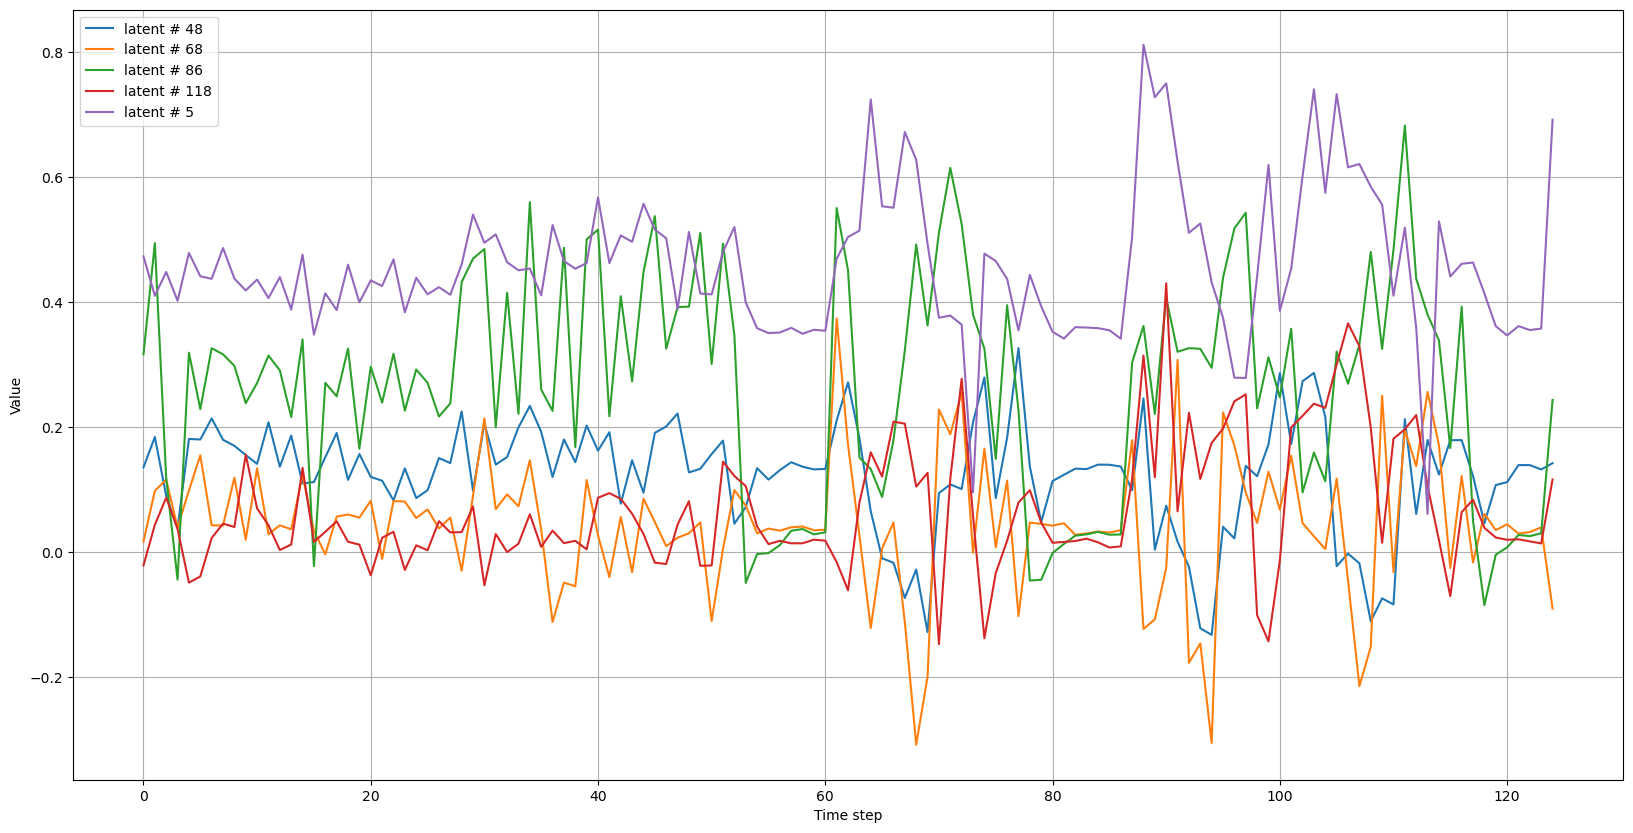

SHAPE: torch.Size([1, 128, 125])


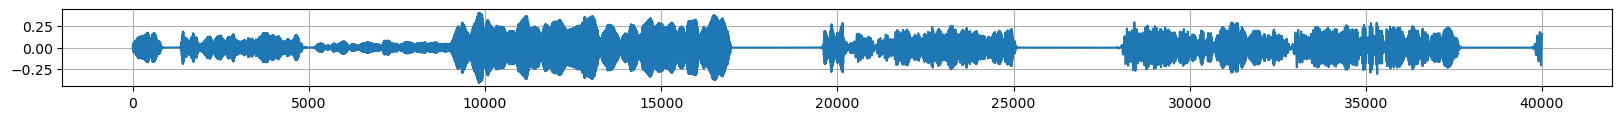

conditioning.shap = torch.Size([125, 8])


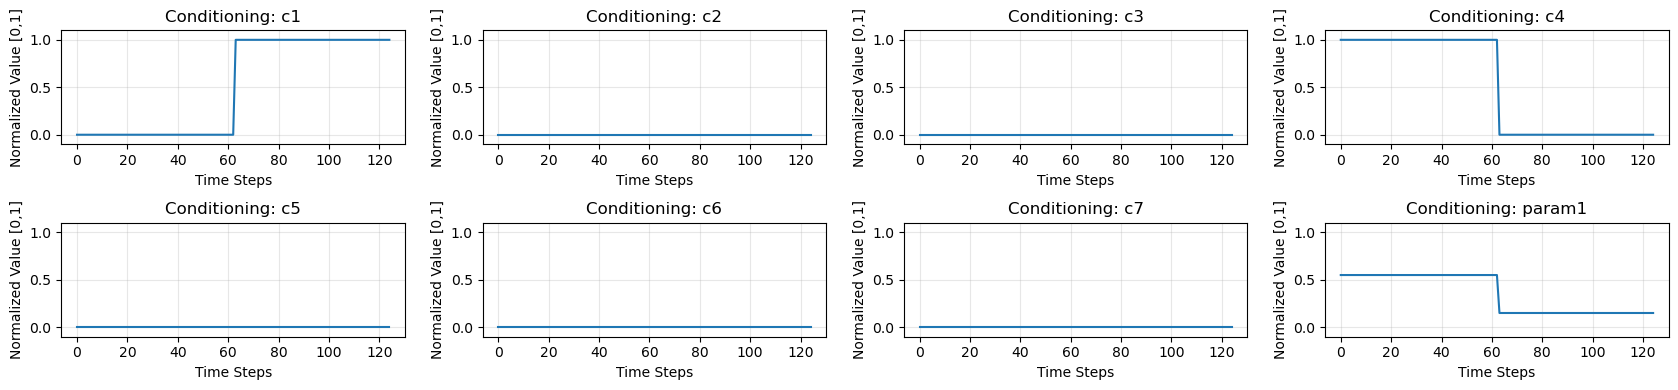

In [11]:
# just show some stuff 
def pmap(x) :
    return 55+x*(88-55)

print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

samp, target = adataset.rand_sample()  #samp.shape=(T, inputsize+cond_size)
pvect=samp[:, -model_config.cond_size:]
print(f'PVECT - shape is {pvect.shape}')
pvect0=samp[0, -model_config.cond_size:]
print(f"pvect[0]: {pvect0}")
pvect25=samp[25, -model_config.cond_size:]
print(f"pvect[25]: {pvect25}")
pvectl=samp[params['seqLen']-1, -model_config.cond_size:]
print(f"pvect[last]: {pvectl}")

inp=samp[:,:-model_config.cond_size]
print(f'inp.shape is {inp.shape}')

# Now grab n=10 random latent components and look at them over time
_, p = inp.shape
# Generate n=10 random indices from 0 to p-1
indices = torch.randperm(p)[:5]
sub_inp = inp[:, indices]
sub_inp.shape


#first print latent sequence
plt.figure(figsize=(20,10)) 
# plt.plot(np.arange(len(sub_inp)), sub_inp) #just print some example from the batch
# plt.grid()
# plt.show()

ts = np.arange(len(sub_inp))  # time steps
for i in range(sub_inp.shape[1]):   # loop over trajectories
    plt.plot(ts, sub_inp[:, i], label=f"latent # {indices[i]}")
plt.legend()
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid()
plt.show()



tokens=samp[:, :params['input_size']].T.unsqueeze(0)
print(f"SHAPE: {tokens[:,:params['input_size']].shape}")
audiosamps, sr=latents_to_audio_simple(enc_model, tokens*params['clamp_val'])
audiosamps=audiosamps[0, 0]

plt.figure(figsize=(20,1)) 
plt.plot(audiosamps) #just print one example from the batch
plt.grid()
plt.show()


#conditioning = samp[:,-model_config.cond_size:]
cvect = pvect#=samp[:, -model_config.cond_size:] # samp[:, -model_config.cond_size:].squeeze(0)  #imp_seq[0, :, -len(params['props']):]
n_params = cvect.shape[1]
print(f'conditioning.shap = {cvect.shape}')
# # Additional Analysis: Conditioning parameters over time
if n_params > 0:
    plt.figure(figsize=(17, 4))
    
    param_names = list(data_config.parameter_specs.keys())
    
    for i in range(n_params):
        plt.subplot(2, (n_params + 1) // 2, i + 1)
        plt.plot(cvect[:,i].numpy())
        param_name = param_names[i] if i < len(param_names) else f'param_{i}'
        plt.title(f'Conditioning: {param_name}')
        plt.xlabel('Time Steps')
        plt.ylabel('Normalized Value [0,1]')
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.1, 1.1)
    
    plt.tight_layout()
    plt.show()

    # #print out numbers
    # cvect_mapped = torch.stack([pmap(cvect[:, 0]), cvect[:, 1]], dim=1)
    # print(f"conditioning params: {cvect_mapped}")

#Another check just to see that the ecdc and params are coming from the same file and using the same starting sample number (no using the random sample as above)
# entry = adataset.sequence_map[0]         # (dataset_idx, start_frame, token_file_path)
# ds_idx, start, token_path = entry
# cpath = adataset._cond_path_for(token_path)
# print("codes:", token_path.name, "cond:", cpath.name, "start:", start)


#This is the "rand_samp" plotted above"
Audio(audiosamps, rate=params['sample_rate'])

In [9]:

def prepare_target_codebook_latents(rnn_model, target_codes, scales_bq=None):
    """
    target_codes: (B, n_q) LongTensor for a single timestep
    returns: List[n_q] of (B, D=128) latents, one per codebook (level 0..n_q-1)
    """
    dev = rnn_model._E_eff.device
    codes_bq = target_codes.to(dev, dtype=torch.long, non_blocking=True)
    if scales_bq is not None:
        scales_bq = scales_bq.to(dev, non_blocking=True)

    out = []
    for q in range(rnn_model.n_q):
        E_q = rnn_model._E_eff[q]                    # (K, D)
        e_q = F.embedding(codes_bq[:, q], E_q)       # (B, D)
        if scales_bq is not None:
            e_q = e_q * scales_bq[:, q].unsqueeze(-1)
        out.append(e_q)
    return out

In [10]:
# Define the training cycle (100% teacher forcing for now)
#*************************************

def train(model,encodec_model, epoch):

 model.train() #put in training mode
 ave_loss_over_steps = 0
 debug_seqs=0

 for batch_num, (inp, target) in enumerate(train_loader):
    debug_seqs += len(inp)
    inp, target = inp.to(device), target.to(device)
    
    hidden = model.init_hidden(params['batch_size'])
    optimizer.zero_grad()
    loss = 0
    
    # Initialize per-quantizer loss tracking
    quantizer_losses = [0.0] * params['n_q']
    
    # Define quantizer weights
    quantizer_weights = params['quantizer_weights'][:params['n_q']]
     
    for i in range(params['seqLen']):  # causal: one time step at a time
        if params['simulate_parallel']:
            use_teacher_forcing = True
            # just placeholders for shape when sim-parallel; zeros are fine
            tflatents = [torch.zeros(params['batch_size'], params['input_size'], device=device)
                         for _ in range(params['n_q'])]
        else:
            use_teacher_forcing = use_tf(epoch)
            if use_teacher_forcing:
                # prepare ground-truth per-level latents (List[n_q * (B,128)])
                tflatents = prepare_target_codebook_latents(model, target[:, i, :]) # uses model's decoder
            else:
                tflatents = None
    
        # --- ONE call; ONE set of sampled tokens used everywhere ---
        logits_list, hidden, sampled_indices, step_latent = model(
            inp[:, i, :],
            hidden,
            target_codebook_latents=tflatents,
            use_teacher_forcing=use_teacher_forcing,
            return_step_latent=False, # this is for "self conditioning"

        )
    
        # --- CE loss exactly as before (per-quantizer) ---
        for j in range(params['n_q']):
            quantizer_loss = criterion(logits_list[j], target[:, i, j])
            quantizer_losses[j] += quantizer_loss.item()
            loss = loss + quantizer_weights[j] * quantizer_loss
    
        # # --- Self-conditioning for next step: feed SAME latent forward ---
        # if i + 1 < params['seqLen']:
        #     # step_latent is:
        #     #  - the sum of teacher-forced per-level latents if TF,
        #     #  - the sum of decoded sampled tokens if AR.
        #     # Use .detach() for stable training (no across-time grads for now).
        #     inp[:, i + 1, :params['input_size']] = step_latent.detach()
    
    loss = loss / params['seqLen']
    quantizer_losses = [ql / params['seqLen'] for ql in quantizer_losses]
    
    loss.backward()
    optimizer.step()
    
    ave_loss_per_sample = loss.item()/params['seqLen']   #over each minibatch
    #ave_loss_over_steps += ave_loss_per_sample
    
    # Accumulate quantizer losses over the epoch
    if batch_num == 0:  # Initialize on first batch
        epoch_quantizer_losses = [0.0] * params['n_q']
    
    for j in range(params['n_q']):
        epoch_quantizer_losses[j] += quantizer_losses[j]
    
    if batch_num>=(params['batches_per_epoch']-1):
        break


    per_q_time_mean = [s / params['seqLen'] for s in quantizer_losses]  # each is batch-mean, time-mean
    overall_time_mean = float(torch.dot(quantizer_weights, torch.tensor(per_q_time_mean, device=quantizer_weights.device)).item())

    
 print(f"Finished epoch number {epoch} with a total of {debug_seqs} debug_seqs")
 if (epoch+1) % log_interval == 0:
    print(f" time: {datetime.now()}, epoch {epoch+1},  Loss: {ave_loss_per_sample:.4f}")
    list_of_losses.append(ave_loss_per_sample)
    writer.add_scalar("Loss/train", ave_loss_per_sample, epoch+1)
    writer.add_scalar("overall_time_mean", overall_time_mean, epoch+1)
    
    # Log individual quantizer losses (averaged over the epoch)
    num_batches = min(batch_num + 1, params['batches_per_epoch'])
    for j in range(params['n_q']):
        avg_quantizer_loss = epoch_quantizer_losses[j] / num_batches
        writer.add_scalar(f"Loss/quantizer_{j}", avg_quantizer_loss, epoch+1)
        print(f"  Quantizer {j} Loss: {avg_quantizer_loss:.4f}")

 if (epoch+1) % visualize_interval == 0:

     # these two lines address a resource management issues with temporary directories ...  I think....
     torch.cuda.empty_cache()  # if using GPU
     gc.collect()

     result = newgen(model,max_length)
     print(f'plot the audio which has shape {result.shape}')
     plt.figure(figsize=(20,1))
     plt.plot(np.arange(len(result)), result) #just print one example from the batch
     plt.show()
     model.train() #put model back to training mode


 # overwrite the last, and save a numbered checkpoint
 if (epoch + 1) % params['savemodel_interval'] == 0:
    checkpoint_data = {
        'epoch': epoch+1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    
    # Save numbered checkpoint
    numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
    torch.save(checkpoint_data, numbered_path)
    
    # Copy to "last" (much faster than saving twice)
    last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    shutil.copy2(numbered_path, last_path)
    
    print(f"Saved checkpoint at epoch {epoch+1}")

In [11]:
# ---- Create Output Folders ----
if resume_checkpoint != None:
    out_dir = resume_checkpoint
else:
    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = os.path.join(params['savemodeldir'], run_timestamp + "_"+savename)
    os.makedirs(out_dir, exist_ok=True)

    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(f"{out_dir}/checkpoints", exist_ok=True)
    os.makedirs(f"{out_dir}/tensorboard", exist_ok=True)


# # ---- Save Config ----
# #machine readable
# torch.save({
#     "model_config": model_config,
#     "data_config": data_config
# }, f"{out_dir}/config_v1.pt")


# #human readable
# with open(f"{out_dir}/config_v1.txt", "w") as f: 
#     f.write("params = " + repr(params) + "\\n")
#     f.write("model_config = " + repr(model_config) + "\\n")
#     f.write("data_config = " + repr(data_config) + "\\n")

#This can replace the above 2 torch.save calls 
save_run_config(f"{out_dir}/config_v2.pt", params=None, model_config=model_config, data_config=data_config)
print(f"wrote {out_dir}/config_v2.pt")

saved to /home/lonce/working/RNeNcodec/notebooks/output/20251128_140835_multiclass_test_SOFTcascade/config_v2.pt
wrote json param file
wrote /home/lonce/working/RNeNcodec/notebooks/output/20251128_140835_multiclass_test_SOFTcascade/config_v2.pt


In [12]:
import copy
from rnencodec.generator import RNNGenerator

inference_model_config=copy.deepcopy(model_config)
inference_model_config.cascade='hard' # 
inference_model_config.hard_sample_mode="sample"
inference_model_config.top_n_hard=12
inference_model_config.temperature_hard=1.0


def newgen(model,max_length):
    #This hack allows us to "configure" the model for generation differently - in particular how it is sampled (which may be different from how it is trained)
    inference_model = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to('cpu')
    inference_model.load_state_dict(model.state_dict())

    #override these values of state
    inference_model.cascade='hard' # 
    inference_model.hard_sample_mode="sample"
    inference_model.top_n_hard=12
    inference_model.temperature_hard=1.0



    rnninference=RNNGenerator(inference_model, inference_model_config, testdata_config, enc_model, max_length, max_length)
    
    # grab a random conditioning vector from the data set
    p_inp, _ = next(iter(test_loader)) # don't need targets
    c = p_inp[:, 0, -inference_model_config.cond_size:].squeeze(0).to(device) #grab a random input sequence
    print(f'DEVICE going in: model tensors {next(model.parameters()).device}, enc_model {enc_model.device}, c {c.device}')
    print(f'About toInitialize generator with c.shape = {c.shape}') 
    rnninference.warmup(c,10)
    gen = rnninference.getNextAudioHop(c, hop=max_length)
    
    return gen

In [13]:
inference_model_config

GRUModelConfig(input_size=128, cond_size=8, hidden_size=128, num_layers=3, n_q=8, codebook_size=1024, dropout=0.1, inp_proportion=5, cond_proportion=3, gumbel_tau_start=1.0, gumbel_tau_end=0.5, straight_through=True, cascade='hard', hard_sample_mode='sample', top_n_hard=12, temperature_hard=1.0, tau_soft=0.6, top_n_soft=None)

### Load the model 

In [14]:

rnn = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to(device)
    
optimizer = torch.optim.Adam(rnn.parameters(), lr=params['lr'])
criterion = nn.CrossEntropyLoss(reduction='mean')

start_epoch=0

if resume_checkpoint:
    checkpoint_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    assert os.path.exists(checkpoint_path), f"File {checkpoint_path} does not exist"
    checkpoint = torch.load(checkpoint_path)
    rnn.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resumed from checkpoint at epoch {start_epoch}")

writer = SummaryWriter(log_dir=f"{out_dir}/tensorboard")

Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128


/home/lonce/micromamba/envs/testing2/lib/python3.11/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5090 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_89 sm_90 compute_90.
If you want to use the NVIDIA GeForce RTX 5090 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [15]:
num_trainable_params = sum(p.numel() for p in rnn.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_trainable_params}")

bd = param_breakdown(rnn, trainable_only=True) #prints out a breakdown of the parameter counts per layter
# pretty print
print(f"latent_proj: {bd['latent_proj']:,}")
print(f"cond_proj:   {bd['cond_proj']:,}")
print(f"GRU total:   {bd['gru_total']:,}")
for k, v in bd['gru_layers'].items():
    print(f"  {k}: {v:,}")
print("Decoders (per head):")
for i, n in enumerate(bd['decoders']):
    print(f"  decoder[{i}]: {n:,}")
print(f"Decoders total: {bd['decoders_total']:,}")
print(f"Model total:    {bd['model_total']:,}")


n_q, K, D = rnn._E_eff.shape
print(f"✅ E_eff is built: n_q={n_q}, K={K}, D={D}, device={rnn._E_eff.device}")
# per-level shapes (each should be (K, D))
print("Per-level shapes:", [tuple(rnn._E_eff[q].shape) for q in range(n_q)])


# 1) Make sure both models are on the same device
device = next(rnn.parameters()).device
enc_model = enc_model.to(device)

B, T = 4, 7
codes = torch.randint(0, rnn.codebook_size, (B, T, rnn.n_q), device=device, dtype=torch.long)

# 3) Manual path via cached effective tables (matches Encodec exactly)
z_manual = rnn._codes_to_latent_sum(codes)                           # (B, T, D)

# 4) Encodec path (expects (n_q, B, T))
z_decode = enc_model.quantizer.decode(codes.permute(2, 0, 1))        # (B, D, T)
z_decode = z_decode.permute(0, 2, 1).contiguous()                    # (B, T, D)

# 5) Compare
diff = (z_manual - z_decode).abs()
print("DIFFERENCE — max|Δ|=", diff.max().item(), "mean|Δ|=", diff.mean().item())

Total trainable parameters: 2413312
latent_proj: 10,320
cond_proj:   432
GRU total:   297,216
  l0/fwd: 99,072
  l1/fwd: 99,072
  l2/fwd: 99,072
Decoders (per head):
  decoder[0]: 263,168
  decoder[1]: 263,168
  decoder[2]: 263,168
  decoder[3]: 263,168
  decoder[4]: 263,168
  decoder[5]: 263,168
  decoder[6]: 263,168
  decoder[7]: 263,168
Decoders total: 2,105,344
Model total:    2,413,312
✅ E_eff is built: n_q=8, K=1024, D=128, device=cuda:0
Per-level shapes: [(1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128)]
DIFFERENCE — max|Δ|= 0.0 mean|Δ|= 0.0


2025-11-28 14:08:35 Starting training...
Finished epoch number 0 with a total of 10000 debug_seqs
 time: 2025-11-28 14:09:23.581966, epoch 1,  Loss: 0.2693
  Quantizer 0 Loss: 4.1687
  Quantizer 1 Loss: 4.4101
  Quantizer 2 Loss: 4.7616
  Quantizer 3 Loss: 5.0693
  Quantizer 4 Loss: 5.2382
  Quantizer 5 Loss: 5.3509
  Quantizer 6 Loss: 5.5291
  Quantizer 7 Loss: 5.5928
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


/home/lonce/working/RNeNcodec/rnencodec/generator/generator.py:159: UserWarning: Warning: ....... chunk size 375 is <= hop size 375. RETURNING full hop and continuing
  warnings.warn(f"Warning: ....... chunk size {T} is <= hop size {h}. RETURNING full hop and continuing")


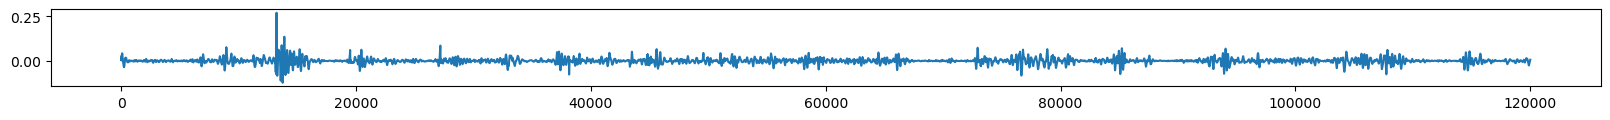

Finished epoch number 1 with a total of 10000 debug_seqs
 time: 2025-11-28 14:10:13.613196, epoch 2,  Loss: 0.2616
  Quantizer 0 Loss: 3.1291
  Quantizer 1 Loss: 3.5321
  Quantizer 2 Loss: 4.0482
  Quantizer 3 Loss: 4.4262
  Quantizer 4 Loss: 4.6700
  Quantizer 5 Loss: 4.8236
  Quantizer 6 Loss: 5.0309
  Quantizer 7 Loss: 5.1198
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


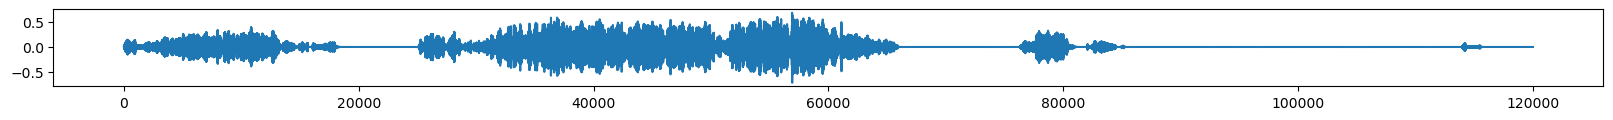

Finished epoch number 2 with a total of 10000 debug_seqs
 time: 2025-11-28 14:11:03.435678, epoch 3,  Loss: 0.2467
  Quantizer 0 Loss: 2.8657
  Quantizer 1 Loss: 3.3437
  Quantizer 2 Loss: 3.8978
  Quantizer 3 Loss: 4.3046
  Quantizer 4 Loss: 4.5641
  Quantizer 5 Loss: 4.7287
  Quantizer 6 Loss: 4.9444
  Quantizer 7 Loss: 5.0372
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


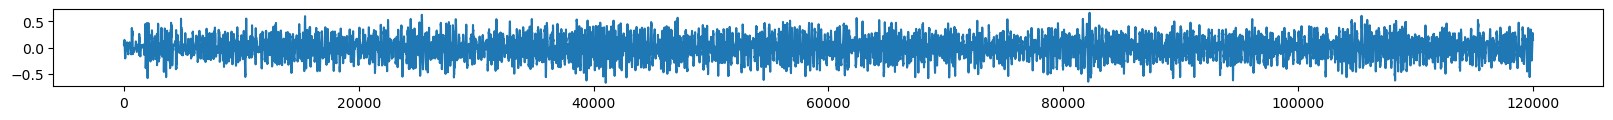

Finished epoch number 3 with a total of 10000 debug_seqs
 time: 2025-11-28 14:11:53.452631, epoch 4,  Loss: 0.2506
  Quantizer 0 Loss: 2.6881
  Quantizer 1 Loss: 3.2040
  Quantizer 2 Loss: 3.7989
  Quantizer 3 Loss: 4.2130
  Quantizer 4 Loss: 4.4820
  Quantizer 5 Loss: 4.6522
  Quantizer 6 Loss: 4.8707
  Quantizer 7 Loss: 4.9703
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


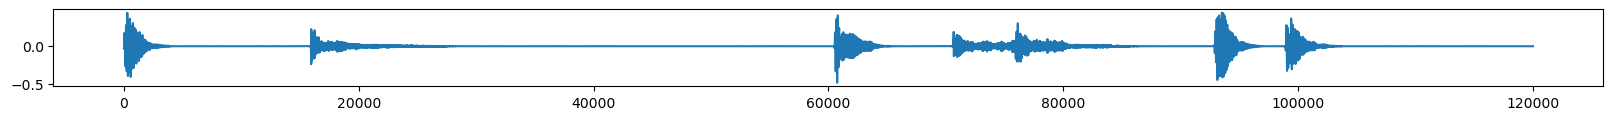

Finished epoch number 4 with a total of 10000 debug_seqs
 time: 2025-11-28 14:12:43.223867, epoch 5,  Loss: 0.2422
  Quantizer 0 Loss: 2.5882
  Quantizer 1 Loss: 3.1079
  Quantizer 2 Loss: 3.7253
  Quantizer 3 Loss: 4.1478
  Quantizer 4 Loss: 4.4277
  Quantizer 5 Loss: 4.5973
  Quantizer 6 Loss: 4.8189
  Quantizer 7 Loss: 4.9251
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


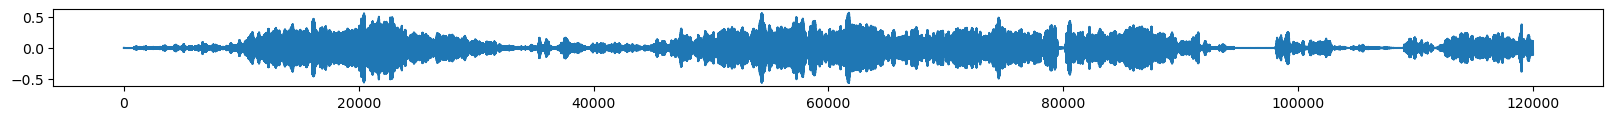

Finished epoch number 5 with a total of 10000 debug_seqs
 time: 2025-11-28 14:13:32.812524, epoch 6,  Loss: 0.2424
  Quantizer 0 Loss: 2.5238
  Quantizer 1 Loss: 3.0475
  Quantizer 2 Loss: 3.6803
  Quantizer 3 Loss: 4.1125
  Quantizer 4 Loss: 4.3987
  Quantizer 5 Loss: 4.5659
  Quantizer 6 Loss: 4.7944
  Quantizer 7 Loss: 4.9022
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


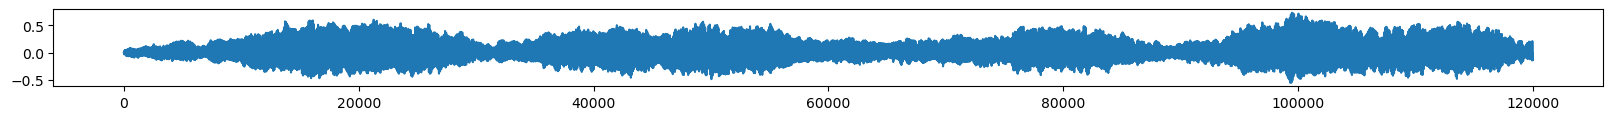

Finished epoch number 6 with a total of 10000 debug_seqs
 time: 2025-11-28 14:14:23.596987, epoch 7,  Loss: 0.2310
  Quantizer 0 Loss: 2.4771
  Quantizer 1 Loss: 3.0029
  Quantizer 2 Loss: 3.6502
  Quantizer 3 Loss: 4.0814
  Quantizer 4 Loss: 4.3710
  Quantizer 5 Loss: 4.5456
  Quantizer 6 Loss: 4.7779
  Quantizer 7 Loss: 4.8843
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


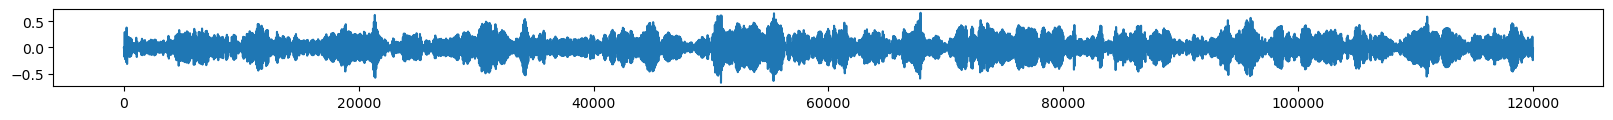

Finished epoch number 7 with a total of 10000 debug_seqs
 time: 2025-11-28 14:15:13.799979, epoch 8,  Loss: 0.2369
  Quantizer 0 Loss: 2.4385
  Quantizer 1 Loss: 2.9632
  Quantizer 2 Loss: 3.6052
  Quantizer 3 Loss: 4.0463
  Quantizer 4 Loss: 4.3336
  Quantizer 5 Loss: 4.5152
  Quantizer 6 Loss: 4.7399
  Quantizer 7 Loss: 4.8527
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


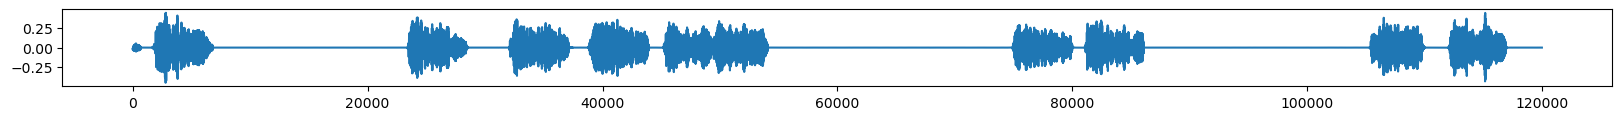

Finished epoch number 8 with a total of 10000 debug_seqs
 time: 2025-11-28 14:16:02.986503, epoch 9,  Loss: 0.2331
  Quantizer 0 Loss: 2.4105
  Quantizer 1 Loss: 2.9291
  Quantizer 2 Loss: 3.5864
  Quantizer 3 Loss: 4.0222
  Quantizer 4 Loss: 4.3178
  Quantizer 5 Loss: 4.4998
  Quantizer 6 Loss: 4.7261
  Quantizer 7 Loss: 4.8413
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


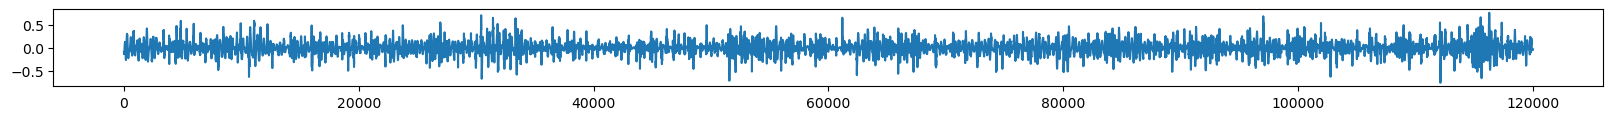

Finished epoch number 9 with a total of 10000 debug_seqs
 time: 2025-11-28 14:16:52.143397, epoch 10,  Loss: 0.2295
  Quantizer 0 Loss: 2.3973
  Quantizer 1 Loss: 2.9174
  Quantizer 2 Loss: 3.5768
  Quantizer 3 Loss: 4.0219
  Quantizer 4 Loss: 4.3115
  Quantizer 5 Loss: 4.4976
  Quantizer 6 Loss: 4.7294
  Quantizer 7 Loss: 4.8405
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


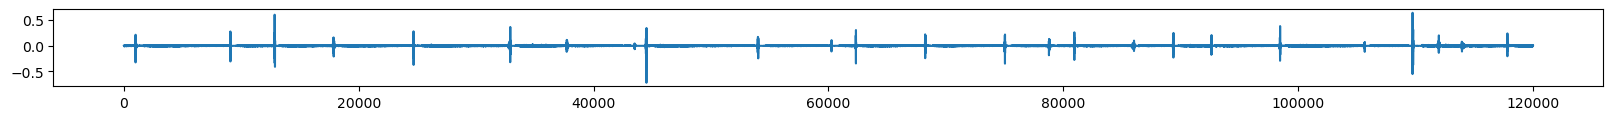

Finished epoch number 10 with a total of 10000 debug_seqs
 time: 2025-11-28 14:17:40.434254, epoch 11,  Loss: 0.2233
  Quantizer 0 Loss: 2.3680
  Quantizer 1 Loss: 2.8888
  Quantizer 2 Loss: 3.5486
  Quantizer 3 Loss: 3.9903
  Quantizer 4 Loss: 4.2839
  Quantizer 5 Loss: 4.4720
  Quantizer 6 Loss: 4.7084
  Quantizer 7 Loss: 4.8253
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


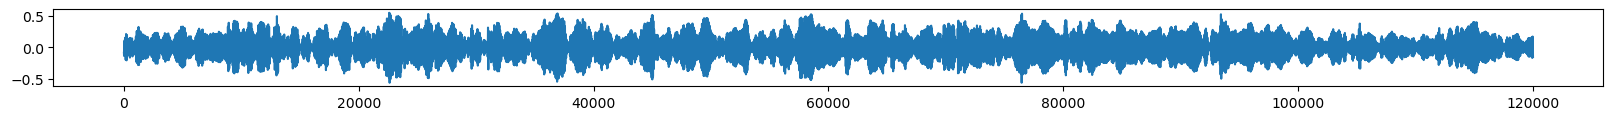

Finished epoch number 11 with a total of 10000 debug_seqs
 time: 2025-11-28 14:18:28.809376, epoch 12,  Loss: 0.2263
  Quantizer 0 Loss: 2.3549
  Quantizer 1 Loss: 2.8764
  Quantizer 2 Loss: 3.5334
  Quantizer 3 Loss: 3.9734
  Quantizer 4 Loss: 4.2712
  Quantizer 5 Loss: 4.4537
  Quantizer 6 Loss: 4.6905
  Quantizer 7 Loss: 4.8028
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


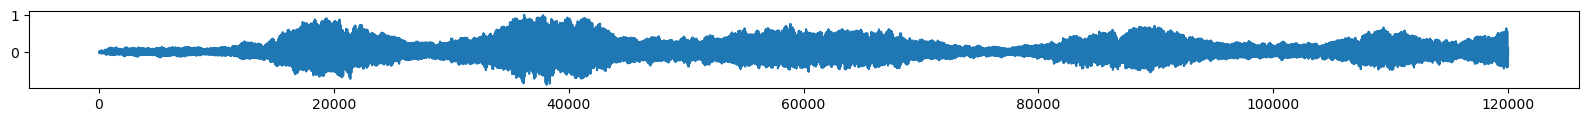

Finished epoch number 12 with a total of 10000 debug_seqs
 time: 2025-11-28 14:19:19.929577, epoch 13,  Loss: 0.2380
  Quantizer 0 Loss: 2.3550
  Quantizer 1 Loss: 2.8715
  Quantizer 2 Loss: 3.5273
  Quantizer 3 Loss: 3.9725
  Quantizer 4 Loss: 4.2703
  Quantizer 5 Loss: 4.4618
  Quantizer 6 Loss: 4.6950
  Quantizer 7 Loss: 4.8128
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


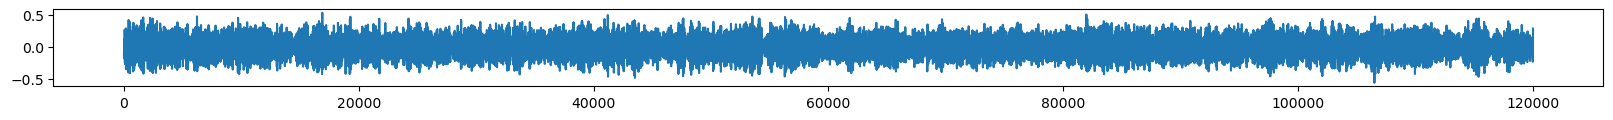

Finished epoch number 13 with a total of 10000 debug_seqs
 time: 2025-11-28 14:20:08.695737, epoch 14,  Loss: 0.2267
  Quantizer 0 Loss: 2.3274
  Quantizer 1 Loss: 2.8374
  Quantizer 2 Loss: 3.4925
  Quantizer 3 Loss: 3.9389
  Quantizer 4 Loss: 4.2366
  Quantizer 5 Loss: 4.4200
  Quantizer 6 Loss: 4.6590
  Quantizer 7 Loss: 4.7780
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


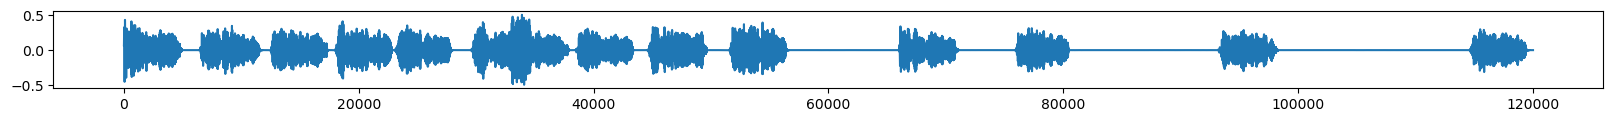

Finished epoch number 14 with a total of 10000 debug_seqs
 time: 2025-11-28 14:20:58.863041, epoch 15,  Loss: 0.2267
  Quantizer 0 Loss: 2.3286
  Quantizer 1 Loss: 2.8475
  Quantizer 2 Loss: 3.4991
  Quantizer 3 Loss: 3.9500
  Quantizer 4 Loss: 4.2482
  Quantizer 5 Loss: 4.4406
  Quantizer 6 Loss: 4.6760
  Quantizer 7 Loss: 4.7977
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


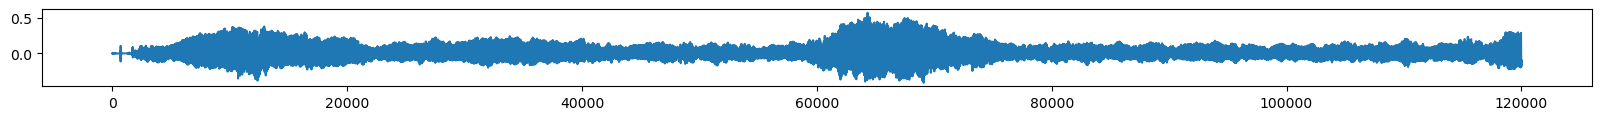

Finished epoch number 15 with a total of 10000 debug_seqs
 time: 2025-11-28 14:21:51.275929, epoch 16,  Loss: 0.2220
  Quantizer 0 Loss: 2.3237
  Quantizer 1 Loss: 2.8380
  Quantizer 2 Loss: 3.4970
  Quantizer 3 Loss: 3.9402
  Quantizer 4 Loss: 4.2383
  Quantizer 5 Loss: 4.4267
  Quantizer 6 Loss: 4.6629
  Quantizer 7 Loss: 4.7782
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


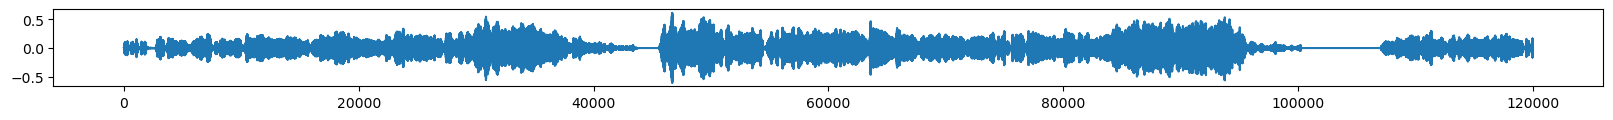

Finished epoch number 16 with a total of 10000 debug_seqs
 time: 2025-11-28 14:22:41.234957, epoch 17,  Loss: 0.2236
  Quantizer 0 Loss: 2.2970
  Quantizer 1 Loss: 2.8169
  Quantizer 2 Loss: 3.4614
  Quantizer 3 Loss: 3.9105
  Quantizer 4 Loss: 4.2079
  Quantizer 5 Loss: 4.4038
  Quantizer 6 Loss: 4.6361
  Quantizer 7 Loss: 4.7619
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


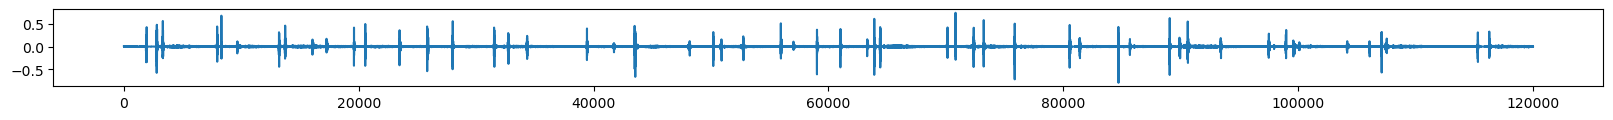

Finished epoch number 17 with a total of 10000 debug_seqs
 time: 2025-11-28 14:23:31.309881, epoch 18,  Loss: 0.2260
  Quantizer 0 Loss: 2.2944
  Quantizer 1 Loss: 2.8066
  Quantizer 2 Loss: 3.4604
  Quantizer 3 Loss: 3.9046
  Quantizer 4 Loss: 4.2000
  Quantizer 5 Loss: 4.3943
  Quantizer 6 Loss: 4.6310
  Quantizer 7 Loss: 4.7507
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


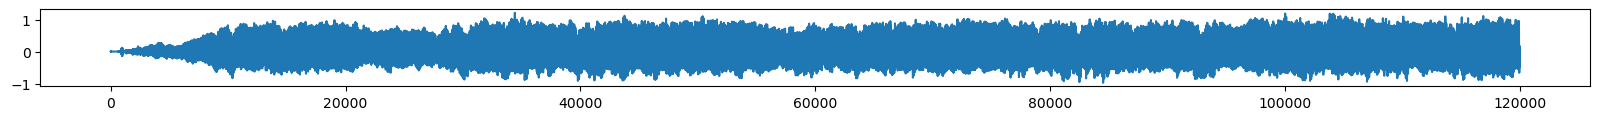

Finished epoch number 18 with a total of 10000 debug_seqs
 time: 2025-11-28 14:24:21.651066, epoch 19,  Loss: 0.2272
  Quantizer 0 Loss: 2.3074
  Quantizer 1 Loss: 2.8128
  Quantizer 2 Loss: 3.4688
  Quantizer 3 Loss: 3.9155
  Quantizer 4 Loss: 4.2182
  Quantizer 5 Loss: 4.4094
  Quantizer 6 Loss: 4.6491
  Quantizer 7 Loss: 4.7687
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


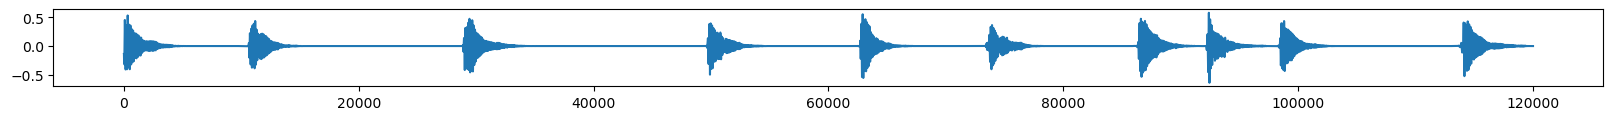

Finished epoch number 19 with a total of 10000 debug_seqs
 time: 2025-11-28 14:25:12.416032, epoch 20,  Loss: 0.2153
  Quantizer 0 Loss: 2.2862
  Quantizer 1 Loss: 2.7946
  Quantizer 2 Loss: 3.4515
  Quantizer 3 Loss: 3.8986
  Quantizer 4 Loss: 4.2001
  Quantizer 5 Loss: 4.3918
  Quantizer 6 Loss: 4.6298
  Quantizer 7 Loss: 4.7525
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


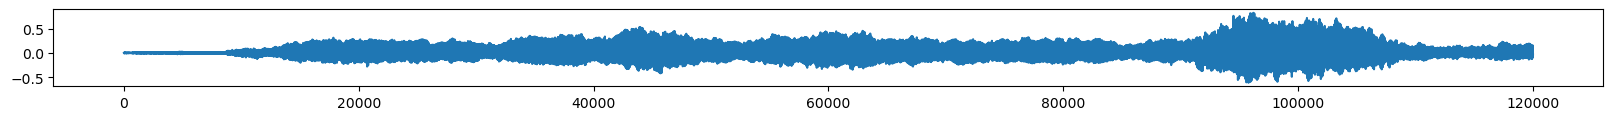

Finished epoch number 20 with a total of 10000 debug_seqs
 time: 2025-11-28 14:26:02.575012, epoch 21,  Loss: 0.2200
  Quantizer 0 Loss: 2.2730
  Quantizer 1 Loss: 2.7818
  Quantizer 2 Loss: 3.4374
  Quantizer 3 Loss: 3.8892
  Quantizer 4 Loss: 4.1912
  Quantizer 5 Loss: 4.3842
  Quantizer 6 Loss: 4.6182
  Quantizer 7 Loss: 4.7433
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


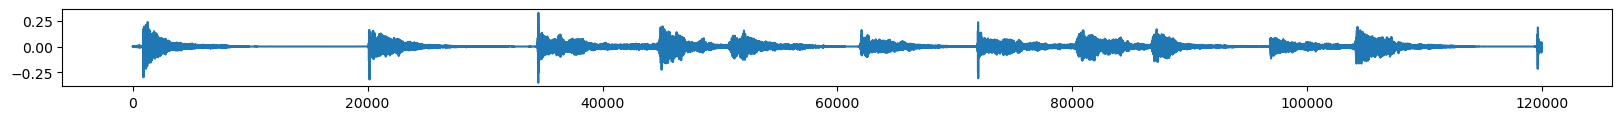

Finished epoch number 21 with a total of 10000 debug_seqs
 time: 2025-11-28 14:26:52.659771, epoch 22,  Loss: 0.2256
  Quantizer 0 Loss: 2.2784
  Quantizer 1 Loss: 2.7931
  Quantizer 2 Loss: 3.4433
  Quantizer 3 Loss: 3.8892
  Quantizer 4 Loss: 4.1964
  Quantizer 5 Loss: 4.3892
  Quantizer 6 Loss: 4.6319
  Quantizer 7 Loss: 4.7549
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


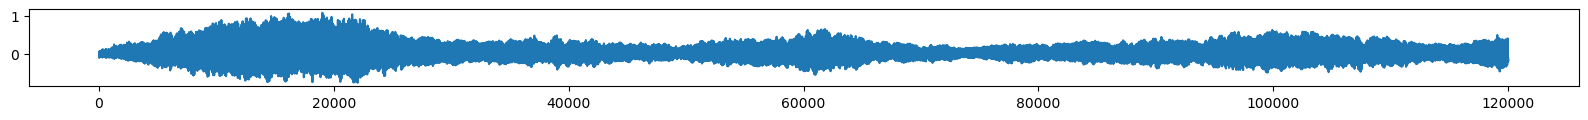

Finished epoch number 22 with a total of 10000 debug_seqs
 time: 2025-11-28 14:27:42.928035, epoch 23,  Loss: 0.2246
  Quantizer 0 Loss: 2.2699
  Quantizer 1 Loss: 2.7799
  Quantizer 2 Loss: 3.4339
  Quantizer 3 Loss: 3.8855
  Quantizer 4 Loss: 4.1927
  Quantizer 5 Loss: 4.3893
  Quantizer 6 Loss: 4.6257
  Quantizer 7 Loss: 4.7532
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


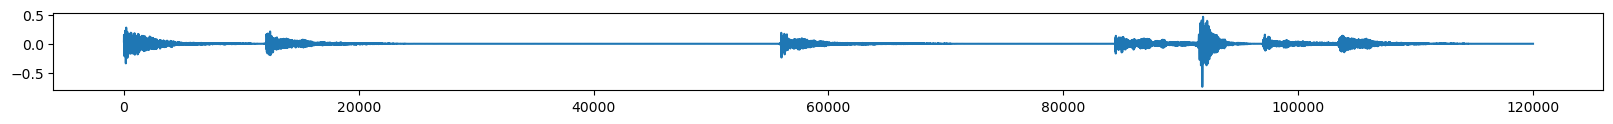

Finished epoch number 23 with a total of 10000 debug_seqs
 time: 2025-11-28 14:28:33.503093, epoch 24,  Loss: 0.2209
  Quantizer 0 Loss: 2.2731
  Quantizer 1 Loss: 2.7879
  Quantizer 2 Loss: 3.4417
  Quantizer 3 Loss: 3.8872
  Quantizer 4 Loss: 4.1960
  Quantizer 5 Loss: 4.3904
  Quantizer 6 Loss: 4.6254
  Quantizer 7 Loss: 4.7546
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


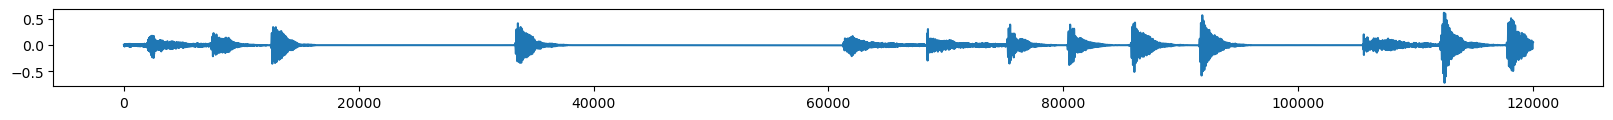

Finished epoch number 24 with a total of 10000 debug_seqs
 time: 2025-11-28 14:29:23.226989, epoch 25,  Loss: 0.2192
  Quantizer 0 Loss: 2.2671
  Quantizer 1 Loss: 2.7682
  Quantizer 2 Loss: 3.4182
  Quantizer 3 Loss: 3.8666
  Quantizer 4 Loss: 4.1721
  Quantizer 5 Loss: 4.3663
  Quantizer 6 Loss: 4.6065
  Quantizer 7 Loss: 4.7333
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


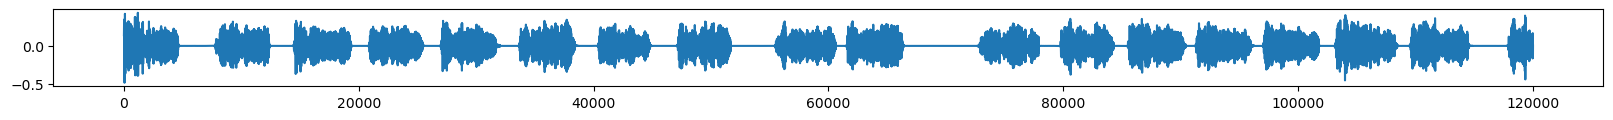

Saved checkpoint at epoch 25
Finished epoch number 25 with a total of 10000 debug_seqs
 time: 2025-11-28 14:30:13.991811, epoch 26,  Loss: 0.2533
  Quantizer 0 Loss: 2.3429
  Quantizer 1 Loss: 3.3693
  Quantizer 2 Loss: 4.0634
  Quantizer 3 Loss: 4.5053
  Quantizer 4 Loss: 4.7790
  Quantizer 5 Loss: 4.9555
  Quantizer 6 Loss: 5.1785
  Quantizer 7 Loss: 5.2685
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


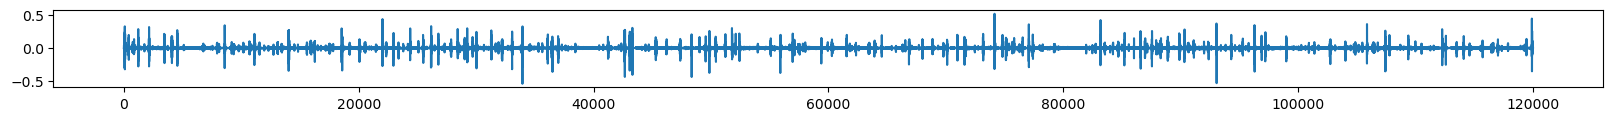

Finished epoch number 26 with a total of 10000 debug_seqs
 time: 2025-11-28 14:31:05.187584, epoch 27,  Loss: 0.2591
  Quantizer 0 Loss: 2.2903
  Quantizer 1 Loss: 3.2662
  Quantizer 2 Loss: 3.9875
  Quantizer 3 Loss: 4.4347
  Quantizer 4 Loss: 4.7275
  Quantizer 5 Loss: 4.9010
  Quantizer 6 Loss: 5.1276
  Quantizer 7 Loss: 5.2232
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


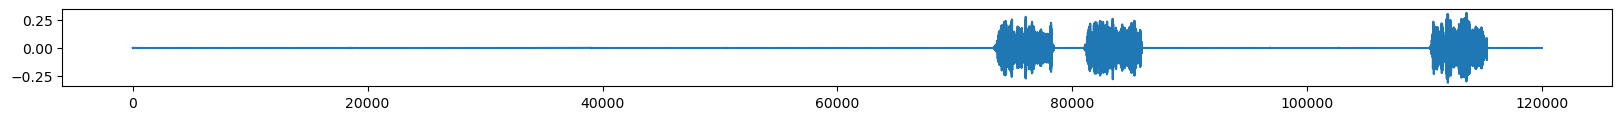

Finished epoch number 27 with a total of 10000 debug_seqs
 time: 2025-11-28 14:31:55.837727, epoch 28,  Loss: 0.2587
  Quantizer 0 Loss: 2.2739
  Quantizer 1 Loss: 3.2228
  Quantizer 2 Loss: 3.9600
  Quantizer 3 Loss: 4.4157
  Quantizer 4 Loss: 4.7129
  Quantizer 5 Loss: 4.8960
  Quantizer 6 Loss: 5.1194
  Quantizer 7 Loss: 5.2147
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


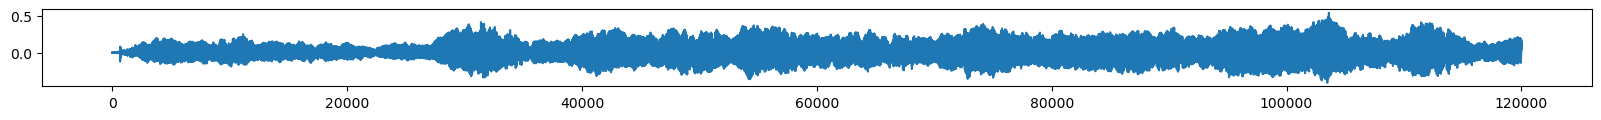

Finished epoch number 28 with a total of 10000 debug_seqs
 time: 2025-11-28 14:32:46.807805, epoch 29,  Loss: 0.2464
  Quantizer 0 Loss: 2.2763
  Quantizer 1 Loss: 3.2063
  Quantizer 2 Loss: 3.9450
  Quantizer 3 Loss: 4.4038
  Quantizer 4 Loss: 4.6979
  Quantizer 5 Loss: 4.8819
  Quantizer 6 Loss: 5.1079
  Quantizer 7 Loss: 5.2042
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


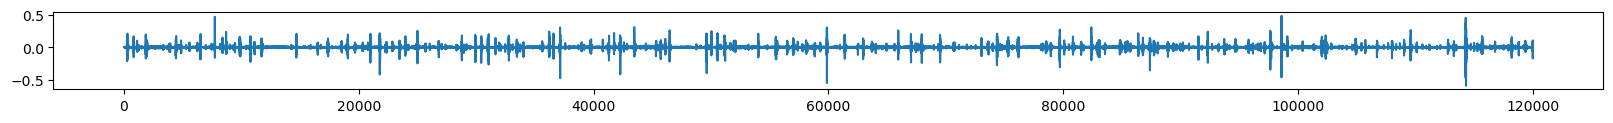

Finished epoch number 29 with a total of 10000 debug_seqs
 time: 2025-11-28 14:33:38.564625, epoch 30,  Loss: 0.2482
  Quantizer 0 Loss: 2.2704
  Quantizer 1 Loss: 3.2032
  Quantizer 2 Loss: 3.9483
  Quantizer 3 Loss: 4.4124
  Quantizer 4 Loss: 4.7090
  Quantizer 5 Loss: 4.8918
  Quantizer 6 Loss: 5.1189
  Quantizer 7 Loss: 5.2176
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


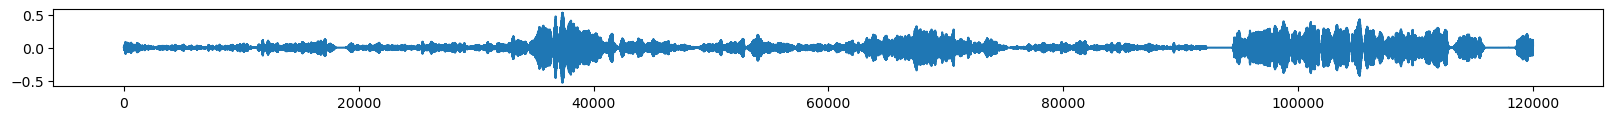

Finished epoch number 30 with a total of 10000 debug_seqs
 time: 2025-11-28 14:34:31.304513, epoch 31,  Loss: 0.2522
  Quantizer 0 Loss: 2.2686
  Quantizer 1 Loss: 3.1981
  Quantizer 2 Loss: 3.9380
  Quantizer 3 Loss: 4.3964
  Quantizer 4 Loss: 4.7000
  Quantizer 5 Loss: 4.8783
  Quantizer 6 Loss: 5.1084
  Quantizer 7 Loss: 5.2081
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


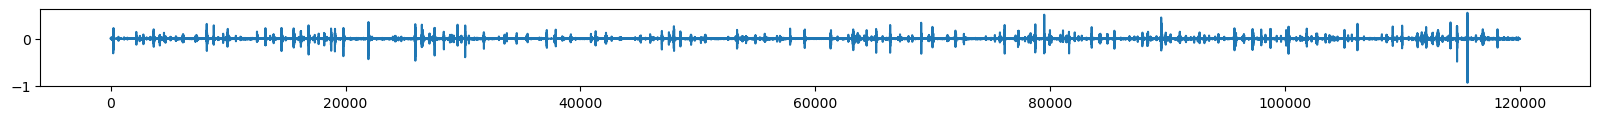

Finished epoch number 31 with a total of 10000 debug_seqs
 time: 2025-11-28 14:35:22.697205, epoch 32,  Loss: 0.2418
  Quantizer 0 Loss: 2.2691
  Quantizer 1 Loss: 3.1920
  Quantizer 2 Loss: 3.9377
  Quantizer 3 Loss: 4.3946
  Quantizer 4 Loss: 4.6975
  Quantizer 5 Loss: 4.8800
  Quantizer 6 Loss: 5.1027
  Quantizer 7 Loss: 5.2038
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


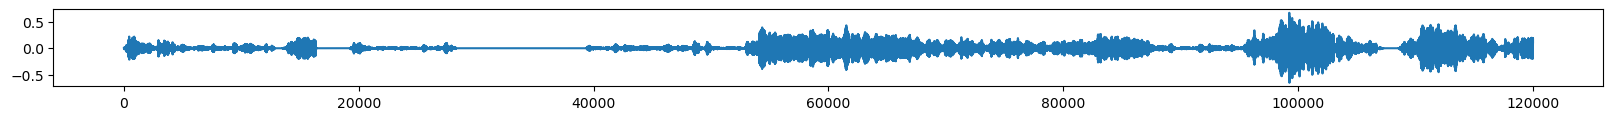

Finished epoch number 32 with a total of 10000 debug_seqs
 time: 2025-11-28 14:36:15.923494, epoch 33,  Loss: 0.2505
  Quantizer 0 Loss: 2.2434
  Quantizer 1 Loss: 3.1718
  Quantizer 2 Loss: 3.9161
  Quantizer 3 Loss: 4.3780
  Quantizer 4 Loss: 4.6799
  Quantizer 5 Loss: 4.8641
  Quantizer 6 Loss: 5.0933
  Quantizer 7 Loss: 5.1924
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


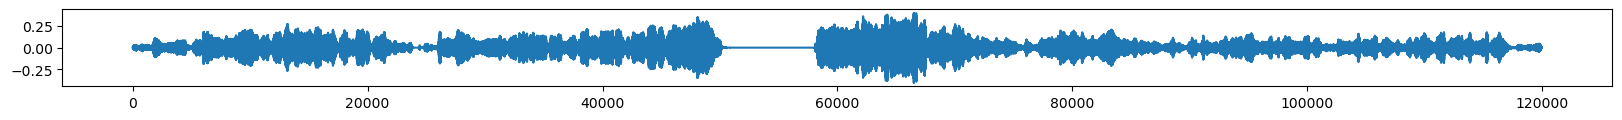

Finished epoch number 33 with a total of 10000 debug_seqs
 time: 2025-11-28 14:37:07.050949, epoch 34,  Loss: 0.2518
  Quantizer 0 Loss: 2.2517
  Quantizer 1 Loss: 3.1724
  Quantizer 2 Loss: 3.9244
  Quantizer 3 Loss: 4.3856
  Quantizer 4 Loss: 4.6909
  Quantizer 5 Loss: 4.8734
  Quantizer 6 Loss: 5.1065
  Quantizer 7 Loss: 5.2069
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


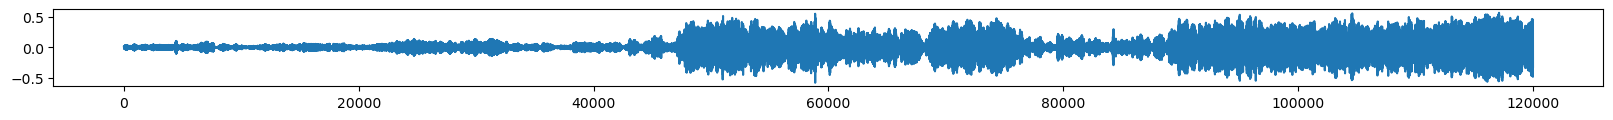

Finished epoch number 34 with a total of 10000 debug_seqs
 time: 2025-11-28 14:37:57.797694, epoch 35,  Loss: 0.2484
  Quantizer 0 Loss: 2.2509
  Quantizer 1 Loss: 3.1698
  Quantizer 2 Loss: 3.9129
  Quantizer 3 Loss: 4.3809
  Quantizer 4 Loss: 4.6779
  Quantizer 5 Loss: 4.8603
  Quantizer 6 Loss: 5.0898
  Quantizer 7 Loss: 5.1922
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


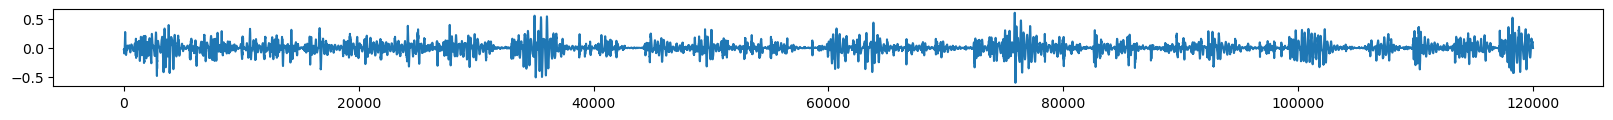

Finished epoch number 35 with a total of 10000 debug_seqs
 time: 2025-11-28 14:38:51.079533, epoch 36,  Loss: 0.2475
  Quantizer 0 Loss: 2.2523
  Quantizer 1 Loss: 3.1710
  Quantizer 2 Loss: 3.9204
  Quantizer 3 Loss: 4.3885
  Quantizer 4 Loss: 4.6879
  Quantizer 5 Loss: 4.8766
  Quantizer 6 Loss: 5.1039
  Quantizer 7 Loss: 5.2026
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


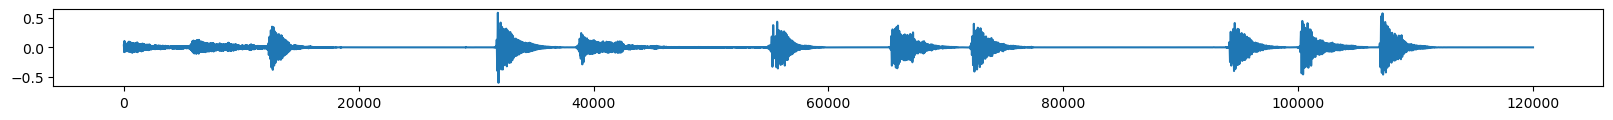

Finished epoch number 36 with a total of 10000 debug_seqs
 time: 2025-11-28 14:39:42.535147, epoch 37,  Loss: 0.2401
  Quantizer 0 Loss: 2.2475
  Quantizer 1 Loss: 3.1601
  Quantizer 2 Loss: 3.9075
  Quantizer 3 Loss: 4.3684
  Quantizer 4 Loss: 4.6695
  Quantizer 5 Loss: 4.8545
  Quantizer 6 Loss: 5.0821
  Quantizer 7 Loss: 5.1823
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


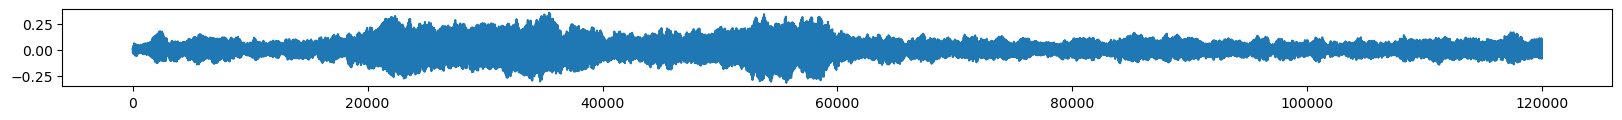

Finished epoch number 37 with a total of 10000 debug_seqs
 time: 2025-11-28 14:40:33.708602, epoch 38,  Loss: 0.2547
  Quantizer 0 Loss: 2.2372
  Quantizer 1 Loss: 3.1529
  Quantizer 2 Loss: 3.8993
  Quantizer 3 Loss: 4.3670
  Quantizer 4 Loss: 4.6720
  Quantizer 5 Loss: 4.8583
  Quantizer 6 Loss: 5.0865
  Quantizer 7 Loss: 5.1856
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


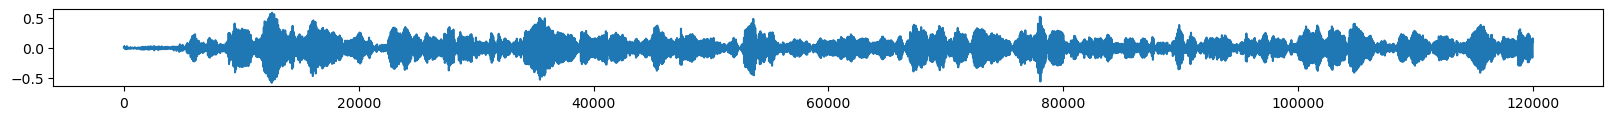

Finished epoch number 38 with a total of 10000 debug_seqs
 time: 2025-11-28 14:41:25.900732, epoch 39,  Loss: 0.2467
  Quantizer 0 Loss: 2.2276
  Quantizer 1 Loss: 3.1488
  Quantizer 2 Loss: 3.9051
  Quantizer 3 Loss: 4.3664
  Quantizer 4 Loss: 4.6745
  Quantizer 5 Loss: 4.8612
  Quantizer 6 Loss: 5.0926
  Quantizer 7 Loss: 5.1910
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


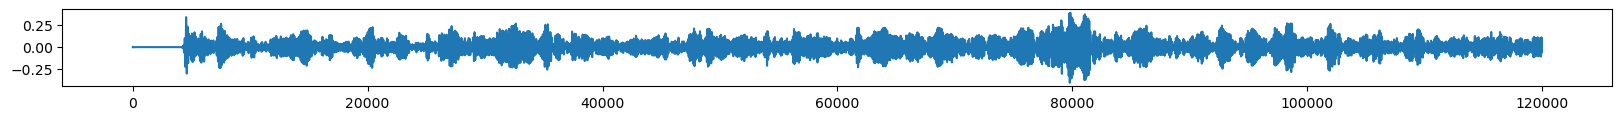

Finished epoch number 39 with a total of 10000 debug_seqs
 time: 2025-11-28 14:42:19.106997, epoch 40,  Loss: 0.2437
  Quantizer 0 Loss: 2.2300
  Quantizer 1 Loss: 3.1563
  Quantizer 2 Loss: 3.8963
  Quantizer 3 Loss: 4.3675
  Quantizer 4 Loss: 4.6722
  Quantizer 5 Loss: 4.8601
  Quantizer 6 Loss: 5.0888
  Quantizer 7 Loss: 5.1863
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


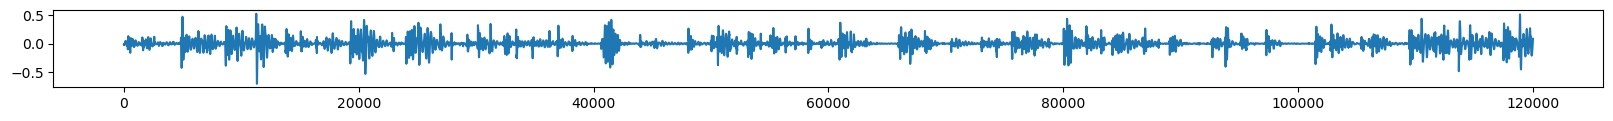

Finished epoch number 40 with a total of 10000 debug_seqs
 time: 2025-11-28 14:43:10.161875, epoch 41,  Loss: 0.2474
  Quantizer 0 Loss: 2.2357
  Quantizer 1 Loss: 3.1477
  Quantizer 2 Loss: 3.9002
  Quantizer 3 Loss: 4.3642
  Quantizer 4 Loss: 4.6703
  Quantizer 5 Loss: 4.8583
  Quantizer 6 Loss: 5.0887
  Quantizer 7 Loss: 5.1901
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


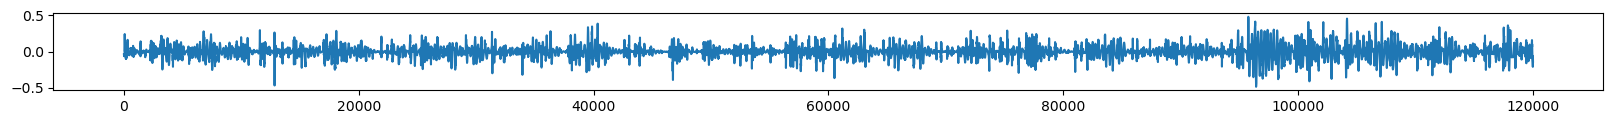

Finished epoch number 41 with a total of 10000 debug_seqs
 time: 2025-11-28 14:44:02.068898, epoch 42,  Loss: 0.2571
  Quantizer 0 Loss: 2.2341
  Quantizer 1 Loss: 3.1582
  Quantizer 2 Loss: 3.8989
  Quantizer 3 Loss: 4.3635
  Quantizer 4 Loss: 4.6664
  Quantizer 5 Loss: 4.8591
  Quantizer 6 Loss: 5.0823
  Quantizer 7 Loss: 5.1826
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


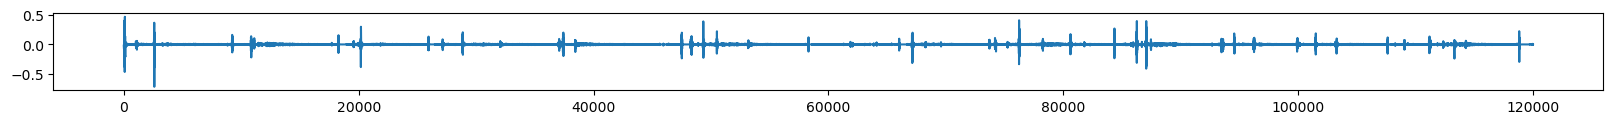

Finished epoch number 42 with a total of 10000 debug_seqs
 time: 2025-11-28 14:44:55.116280, epoch 43,  Loss: 0.2482
  Quantizer 0 Loss: 2.2210
  Quantizer 1 Loss: 3.1405
  Quantizer 2 Loss: 3.8836
  Quantizer 3 Loss: 4.3514
  Quantizer 4 Loss: 4.6547
  Quantizer 5 Loss: 4.8461
  Quantizer 6 Loss: 5.0736
  Quantizer 7 Loss: 5.1756
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


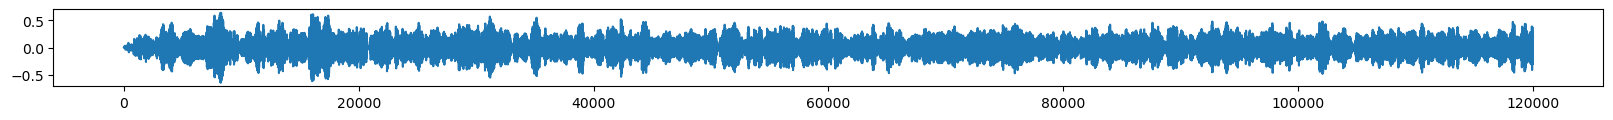

Finished epoch number 43 with a total of 10000 debug_seqs
 time: 2025-11-28 14:45:50.125577, epoch 44,  Loss: 0.2445
  Quantizer 0 Loss: 2.2351
  Quantizer 1 Loss: 3.1462
  Quantizer 2 Loss: 3.8997
  Quantizer 3 Loss: 4.3676
  Quantizer 4 Loss: 4.6712
  Quantizer 5 Loss: 4.8608
  Quantizer 6 Loss: 5.0902
  Quantizer 7 Loss: 5.1899
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


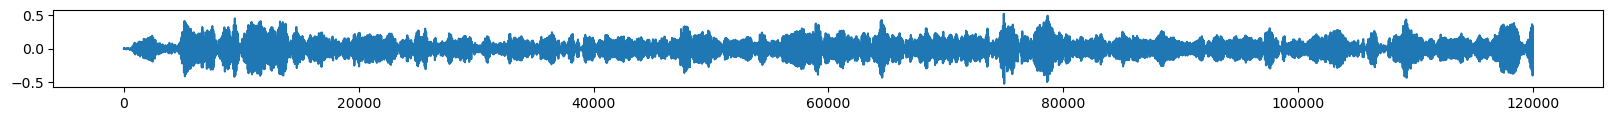

Finished epoch number 44 with a total of 10000 debug_seqs
 time: 2025-11-28 14:46:45.278859, epoch 45,  Loss: 0.2556
  Quantizer 0 Loss: 2.2255
  Quantizer 1 Loss: 3.1319
  Quantizer 2 Loss: 3.8835
  Quantizer 3 Loss: 4.3480
  Quantizer 4 Loss: 4.6598
  Quantizer 5 Loss: 4.8465
  Quantizer 6 Loss: 5.0732
  Quantizer 7 Loss: 5.1765
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


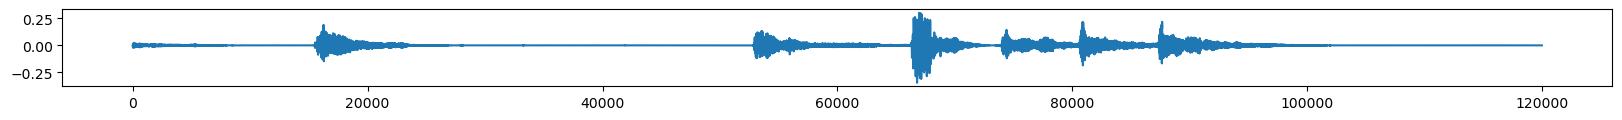

Finished epoch number 45 with a total of 10000 debug_seqs
 time: 2025-11-28 14:47:37.558164, epoch 46,  Loss: 0.2504
  Quantizer 0 Loss: 2.2279
  Quantizer 1 Loss: 3.1434
  Quantizer 2 Loss: 3.8923
  Quantizer 3 Loss: 4.3559
  Quantizer 4 Loss: 4.6633
  Quantizer 5 Loss: 4.8488
  Quantizer 6 Loss: 5.0830
  Quantizer 7 Loss: 5.1818
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


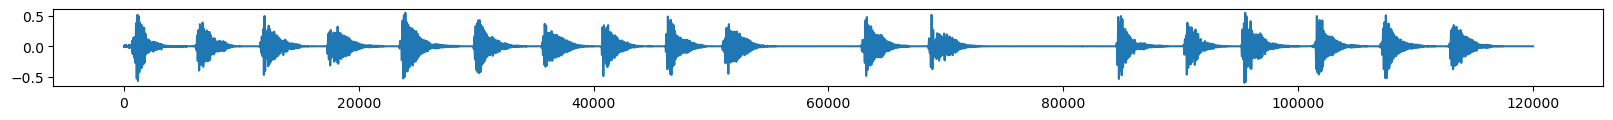

Finished epoch number 46 with a total of 10000 debug_seqs
 time: 2025-11-28 14:48:28.497195, epoch 47,  Loss: 0.2456
  Quantizer 0 Loss: 2.2238
  Quantizer 1 Loss: 3.1373
  Quantizer 2 Loss: 3.8827
  Quantizer 3 Loss: 4.3516
  Quantizer 4 Loss: 4.6545
  Quantizer 5 Loss: 4.8408
  Quantizer 6 Loss: 5.0691
  Quantizer 7 Loss: 5.1700
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


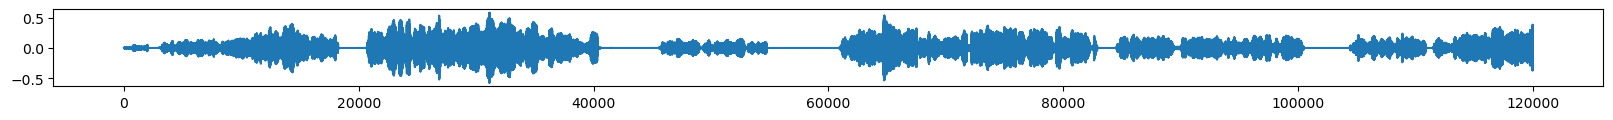

Finished epoch number 47 with a total of 10000 debug_seqs
 time: 2025-11-28 14:49:20.244507, epoch 48,  Loss: 0.2450
  Quantizer 0 Loss: 2.2228
  Quantizer 1 Loss: 3.1322
  Quantizer 2 Loss: 3.8855
  Quantizer 3 Loss: 4.3510
  Quantizer 4 Loss: 4.6546
  Quantizer 5 Loss: 4.8477
  Quantizer 6 Loss: 5.0755
  Quantizer 7 Loss: 5.1781
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


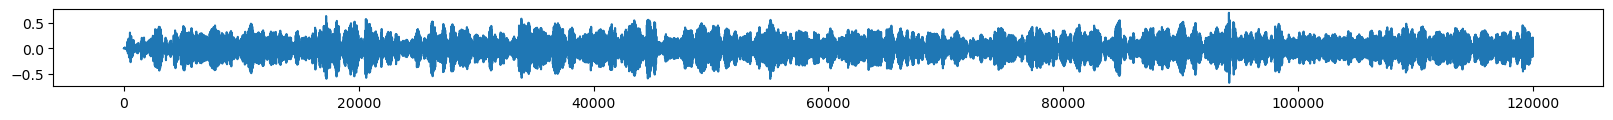

Finished epoch number 48 with a total of 10000 debug_seqs
 time: 2025-11-28 14:50:12.664256, epoch 49,  Loss: 0.2490
  Quantizer 0 Loss: 2.2143
  Quantizer 1 Loss: 3.1271
  Quantizer 2 Loss: 3.8741
  Quantizer 3 Loss: 4.3397
  Quantizer 4 Loss: 4.6433
  Quantizer 5 Loss: 4.8314
  Quantizer 6 Loss: 5.0597
  Quantizer 7 Loss: 5.1619
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


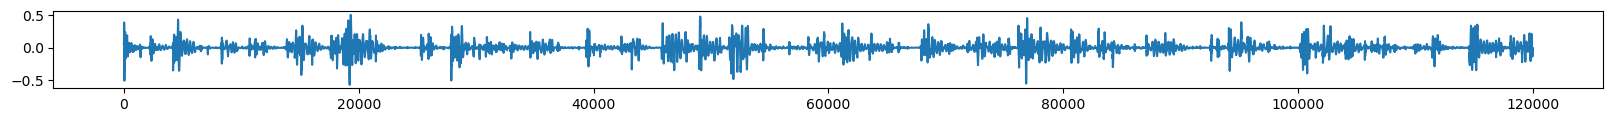

Finished epoch number 49 with a total of 10000 debug_seqs
 time: 2025-11-28 14:51:04.610909, epoch 50,  Loss: 0.2500
  Quantizer 0 Loss: 2.2180
  Quantizer 1 Loss: 3.1280
  Quantizer 2 Loss: 3.8764
  Quantizer 3 Loss: 4.3443
  Quantizer 4 Loss: 4.6514
  Quantizer 5 Loss: 4.8416
  Quantizer 6 Loss: 5.0683
  Quantizer 7 Loss: 5.1658
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


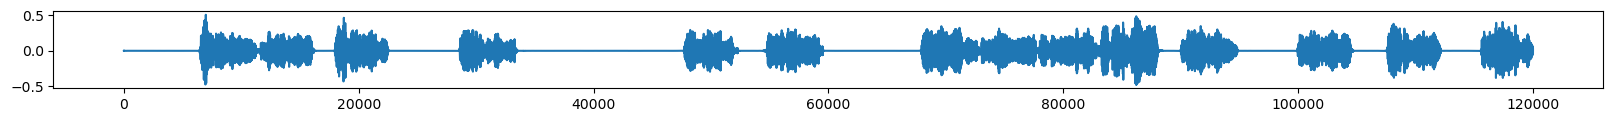

Saved checkpoint at epoch 50
Finished epoch number 50 with a total of 10000 debug_seqs
 time: 2025-11-28 14:51:58.046987, epoch 51,  Loss: 0.2252
  Quantizer 0 Loss: 2.1951
  Quantizer 1 Loss: 2.7678
  Quantizer 2 Loss: 3.4667
  Quantizer 3 Loss: 3.9362
  Quantizer 4 Loss: 4.2597
  Quantizer 5 Loss: 4.4719
  Quantizer 6 Loss: 4.7156
  Quantizer 7 Loss: 4.8428
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


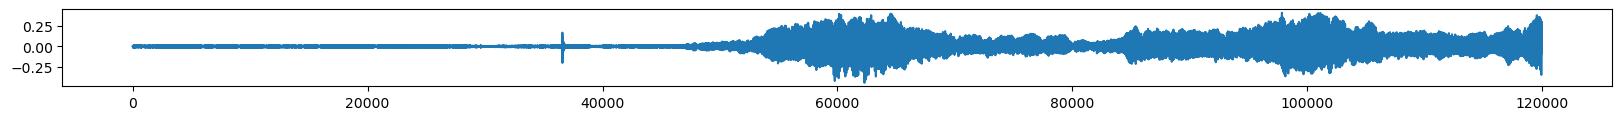

Finished epoch number 51 with a total of 10000 debug_seqs
 time: 2025-11-28 14:52:49.518564, epoch 52,  Loss: 0.2253
  Quantizer 0 Loss: 2.2030
  Quantizer 1 Loss: 2.7361
  Quantizer 2 Loss: 3.4157
  Quantizer 3 Loss: 3.8772
  Quantizer 4 Loss: 4.1953
  Quantizer 5 Loss: 4.3999
  Quantizer 6 Loss: 4.6450
  Quantizer 7 Loss: 4.7738
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


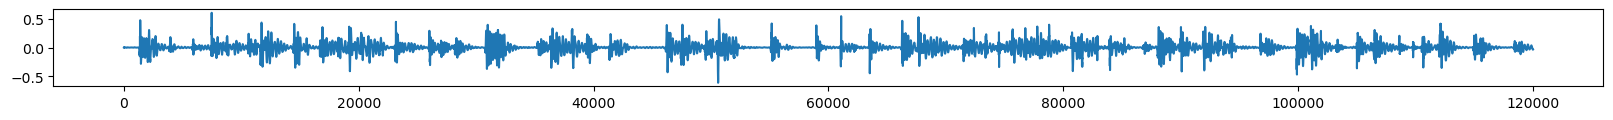

Finished epoch number 52 with a total of 10000 debug_seqs
 time: 2025-11-28 14:53:41.592189, epoch 53,  Loss: 0.2196
  Quantizer 0 Loss: 2.1985
  Quantizer 1 Loss: 2.7117
  Quantizer 2 Loss: 3.3853
  Quantizer 3 Loss: 3.8410
  Quantizer 4 Loss: 4.1584
  Quantizer 5 Loss: 4.3634
  Quantizer 6 Loss: 4.6070
  Quantizer 7 Loss: 4.7359
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


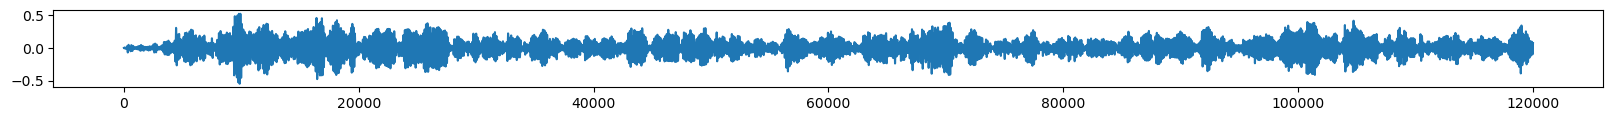

Finished epoch number 53 with a total of 10000 debug_seqs
 time: 2025-11-28 14:54:36.860963, epoch 54,  Loss: 0.2261
  Quantizer 0 Loss: 2.2056
  Quantizer 1 Loss: 2.7197
  Quantizer 2 Loss: 3.3925
  Quantizer 3 Loss: 3.8506
  Quantizer 4 Loss: 4.1644
  Quantizer 5 Loss: 4.3680
  Quantizer 6 Loss: 4.6069
  Quantizer 7 Loss: 4.7340
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


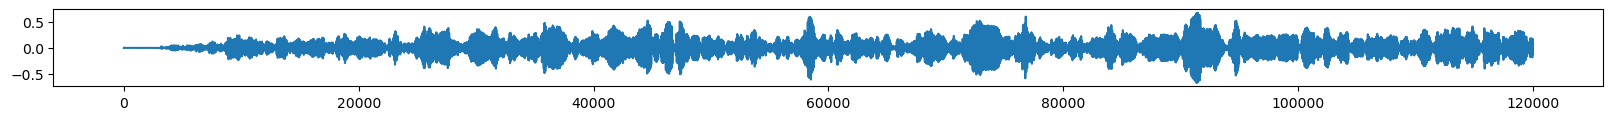

Finished epoch number 54 with a total of 10000 debug_seqs
 time: 2025-11-28 14:55:29.274673, epoch 55,  Loss: 0.2193
  Quantizer 0 Loss: 2.2233
  Quantizer 1 Loss: 2.7383
  Quantizer 2 Loss: 3.4071
  Quantizer 3 Loss: 3.8571
  Quantizer 4 Loss: 4.1632
  Quantizer 5 Loss: 4.3622
  Quantizer 6 Loss: 4.6090
  Quantizer 7 Loss: 4.7344
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


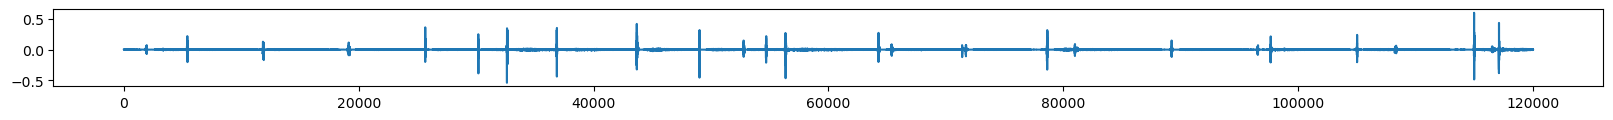

Finished epoch number 55 with a total of 10000 debug_seqs
 time: 2025-11-28 14:56:23.058037, epoch 56,  Loss: 0.2170
  Quantizer 0 Loss: 2.2030
  Quantizer 1 Loss: 2.7221
  Quantizer 2 Loss: 3.3794
  Quantizer 3 Loss: 3.8360
  Quantizer 4 Loss: 4.1456
  Quantizer 5 Loss: 4.3506
  Quantizer 6 Loss: 4.5946
  Quantizer 7 Loss: 4.7238
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


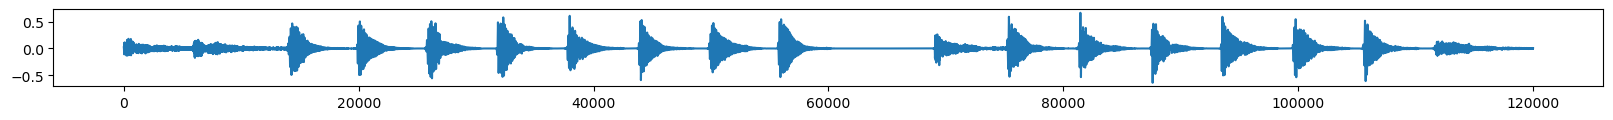

Finished epoch number 56 with a total of 10000 debug_seqs
 time: 2025-11-28 14:57:15.753994, epoch 57,  Loss: 0.2195
  Quantizer 0 Loss: 2.1996
  Quantizer 1 Loss: 2.7135
  Quantizer 2 Loss: 3.3671
  Quantizer 3 Loss: 3.8221
  Quantizer 4 Loss: 4.1318
  Quantizer 5 Loss: 4.3319
  Quantizer 6 Loss: 4.5778
  Quantizer 7 Loss: 4.7055
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


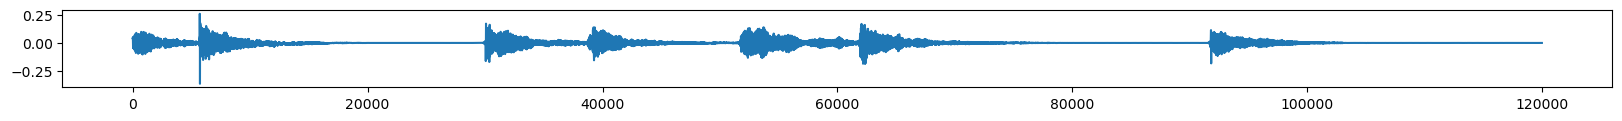

Finished epoch number 57 with a total of 10000 debug_seqs
 time: 2025-11-28 14:58:07.151667, epoch 58,  Loss: 0.2185
  Quantizer 0 Loss: 2.1938
  Quantizer 1 Loss: 2.7064
  Quantizer 2 Loss: 3.3624
  Quantizer 3 Loss: 3.8188
  Quantizer 4 Loss: 4.1335
  Quantizer 5 Loss: 4.3372
  Quantizer 6 Loss: 4.5769
  Quantizer 7 Loss: 4.7096
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


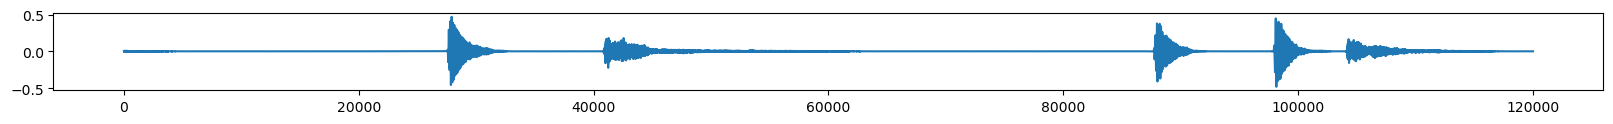

Finished epoch number 58 with a total of 10000 debug_seqs
 time: 2025-11-28 14:59:00.272933, epoch 59,  Loss: 0.2193
  Quantizer 0 Loss: 2.1944
  Quantizer 1 Loss: 2.7054
  Quantizer 2 Loss: 3.3620
  Quantizer 3 Loss: 3.8092
  Quantizer 4 Loss: 4.1197
  Quantizer 5 Loss: 4.3230
  Quantizer 6 Loss: 4.5700
  Quantizer 7 Loss: 4.6947
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


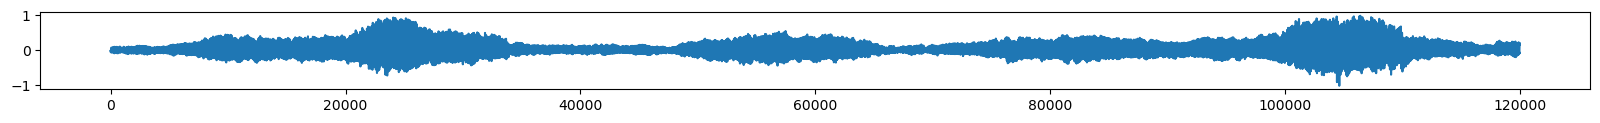

Finished epoch number 59 with a total of 10000 debug_seqs
 time: 2025-11-28 14:59:51.587974, epoch 60,  Loss: 0.2254
  Quantizer 0 Loss: 2.1923
  Quantizer 1 Loss: 2.7035
  Quantizer 2 Loss: 3.3563
  Quantizer 3 Loss: 3.8065
  Quantizer 4 Loss: 4.1245
  Quantizer 5 Loss: 4.3287
  Quantizer 6 Loss: 4.5758
  Quantizer 7 Loss: 4.7076
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


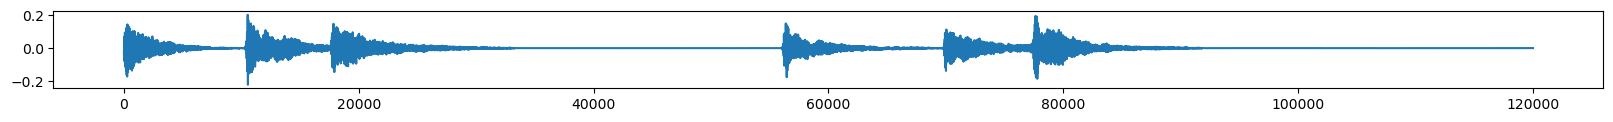

Finished epoch number 60 with a total of 10000 debug_seqs
 time: 2025-11-28 15:00:41.180002, epoch 61,  Loss: 0.2187
  Quantizer 0 Loss: 2.1994
  Quantizer 1 Loss: 2.7117
  Quantizer 2 Loss: 3.3644
  Quantizer 3 Loss: 3.8166
  Quantizer 4 Loss: 4.1259
  Quantizer 5 Loss: 4.3279
  Quantizer 6 Loss: 4.5744
  Quantizer 7 Loss: 4.7020
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


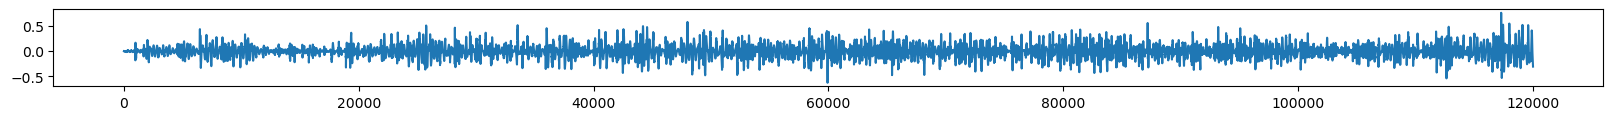

Finished epoch number 61 with a total of 10000 debug_seqs
 time: 2025-11-28 15:01:33.703433, epoch 62,  Loss: 0.2205
  Quantizer 0 Loss: 2.1976
  Quantizer 1 Loss: 2.7082
  Quantizer 2 Loss: 3.3602
  Quantizer 3 Loss: 3.8087
  Quantizer 4 Loss: 4.1251
  Quantizer 5 Loss: 4.3259
  Quantizer 6 Loss: 4.5720
  Quantizer 7 Loss: 4.6989
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


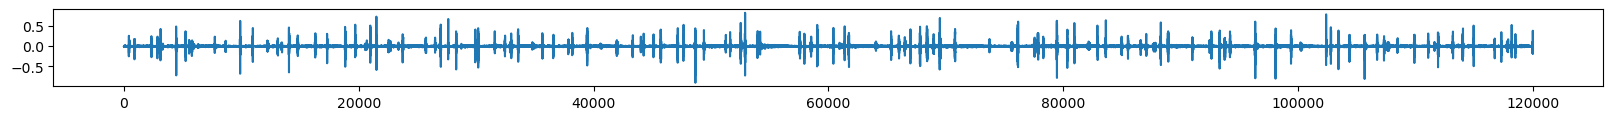

Finished epoch number 62 with a total of 10000 debug_seqs
 time: 2025-11-28 15:02:23.125146, epoch 63,  Loss: 0.2205
  Quantizer 0 Loss: 2.2006
  Quantizer 1 Loss: 2.7150
  Quantizer 2 Loss: 3.3642
  Quantizer 3 Loss: 3.8149
  Quantizer 4 Loss: 4.1227
  Quantizer 5 Loss: 4.3278
  Quantizer 6 Loss: 4.5729
  Quantizer 7 Loss: 4.7042
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


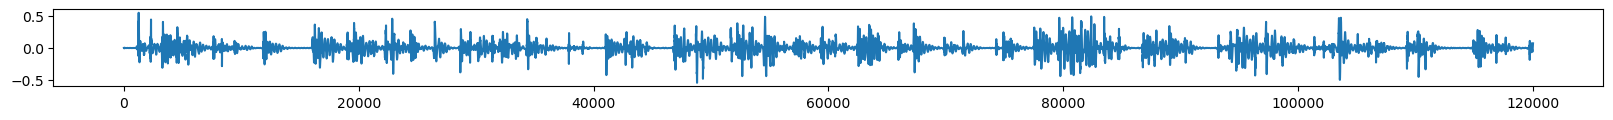

Finished epoch number 63 with a total of 10000 debug_seqs
 time: 2025-11-28 15:03:12.821830, epoch 64,  Loss: 0.2224
  Quantizer 0 Loss: 2.1981
  Quantizer 1 Loss: 2.7069
  Quantizer 2 Loss: 3.3562
  Quantizer 3 Loss: 3.8024
  Quantizer 4 Loss: 4.1198
  Quantizer 5 Loss: 4.3200
  Quantizer 6 Loss: 4.5631
  Quantizer 7 Loss: 4.6956
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


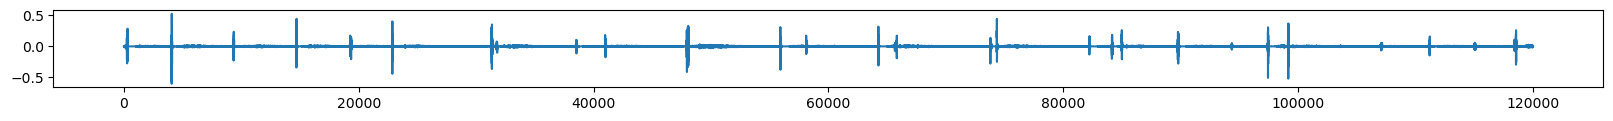

Finished epoch number 64 with a total of 10000 debug_seqs
 time: 2025-11-28 15:04:03.462118, epoch 65,  Loss: 0.2084
  Quantizer 0 Loss: 2.1927
  Quantizer 1 Loss: 2.7002
  Quantizer 2 Loss: 3.3581
  Quantizer 3 Loss: 3.8080
  Quantizer 4 Loss: 4.1224
  Quantizer 5 Loss: 4.3259
  Quantizer 6 Loss: 4.5705
  Quantizer 7 Loss: 4.6943
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


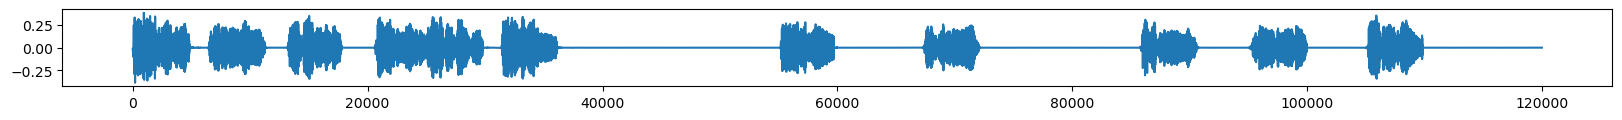

Finished epoch number 65 with a total of 10000 debug_seqs
 time: 2025-11-28 15:04:54.417065, epoch 66,  Loss: 0.2236
  Quantizer 0 Loss: 2.1996
  Quantizer 1 Loss: 2.7059
  Quantizer 2 Loss: 3.3559
  Quantizer 3 Loss: 3.8112
  Quantizer 4 Loss: 4.1184
  Quantizer 5 Loss: 4.3261
  Quantizer 6 Loss: 4.5688
  Quantizer 7 Loss: 4.6979
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


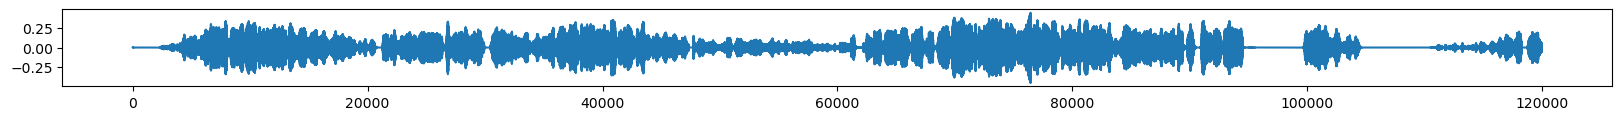

Finished epoch number 66 with a total of 10000 debug_seqs
 time: 2025-11-28 15:05:43.842854, epoch 67,  Loss: 0.2175
  Quantizer 0 Loss: 2.1864
  Quantizer 1 Loss: 2.6812
  Quantizer 2 Loss: 3.3386
  Quantizer 3 Loss: 3.7928
  Quantizer 4 Loss: 4.1041
  Quantizer 5 Loss: 4.3067
  Quantizer 6 Loss: 4.5579
  Quantizer 7 Loss: 4.6903
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


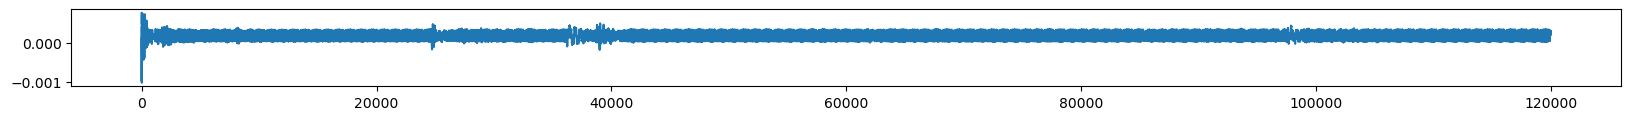

Finished epoch number 67 with a total of 10000 debug_seqs
 time: 2025-11-28 15:06:34.219218, epoch 68,  Loss: 0.2195
  Quantizer 0 Loss: 2.1856
  Quantizer 1 Loss: 2.6889
  Quantizer 2 Loss: 3.3400
  Quantizer 3 Loss: 3.7865
  Quantizer 4 Loss: 4.1012
  Quantizer 5 Loss: 4.3037
  Quantizer 6 Loss: 4.5476
  Quantizer 7 Loss: 4.6774
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


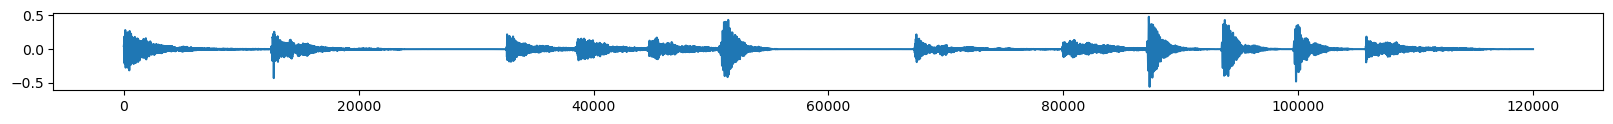

Finished epoch number 68 with a total of 10000 debug_seqs
 time: 2025-11-28 15:07:25.914041, epoch 69,  Loss: 0.2134
  Quantizer 0 Loss: 2.2003
  Quantizer 1 Loss: 2.7113
  Quantizer 2 Loss: 3.3602
  Quantizer 3 Loss: 3.8096
  Quantizer 4 Loss: 4.1165
  Quantizer 5 Loss: 4.3177
  Quantizer 6 Loss: 4.5722
  Quantizer 7 Loss: 4.7046
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


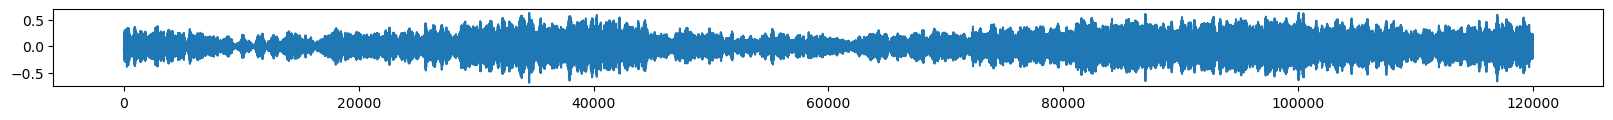

Finished epoch number 69 with a total of 10000 debug_seqs
 time: 2025-11-28 15:08:15.754298, epoch 70,  Loss: 0.2136
  Quantizer 0 Loss: 2.2028
  Quantizer 1 Loss: 2.7073
  Quantizer 2 Loss: 3.3642
  Quantizer 3 Loss: 3.8135
  Quantizer 4 Loss: 4.1245
  Quantizer 5 Loss: 4.3263
  Quantizer 6 Loss: 4.5675
  Quantizer 7 Loss: 4.7033
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


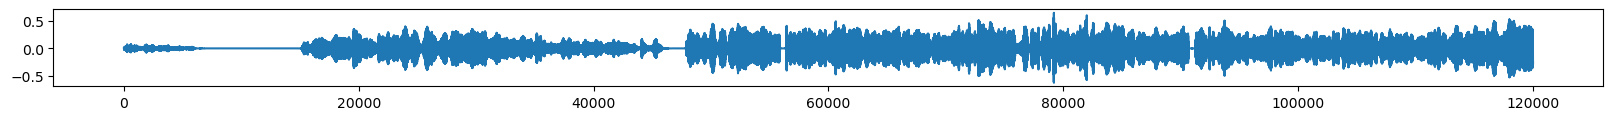

Finished epoch number 70 with a total of 10000 debug_seqs
 time: 2025-11-28 15:09:06.374736, epoch 71,  Loss: 0.2164
  Quantizer 0 Loss: 2.1954
  Quantizer 1 Loss: 2.6952
  Quantizer 2 Loss: 3.3458
  Quantizer 3 Loss: 3.7927
  Quantizer 4 Loss: 4.1012
  Quantizer 5 Loss: 4.3040
  Quantizer 6 Loss: 4.5471
  Quantizer 7 Loss: 4.6818
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


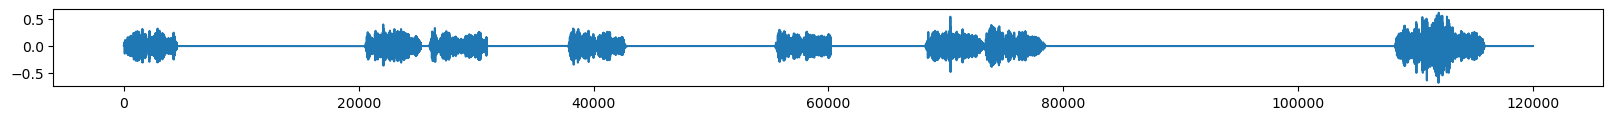

Finished epoch number 71 with a total of 10000 debug_seqs
 time: 2025-11-28 15:09:55.883270, epoch 72,  Loss: 0.2207
  Quantizer 0 Loss: 2.1926
  Quantizer 1 Loss: 2.6936
  Quantizer 2 Loss: 3.3481
  Quantizer 3 Loss: 3.7965
  Quantizer 4 Loss: 4.1095
  Quantizer 5 Loss: 4.3119
  Quantizer 6 Loss: 4.5544
  Quantizer 7 Loss: 4.6862
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


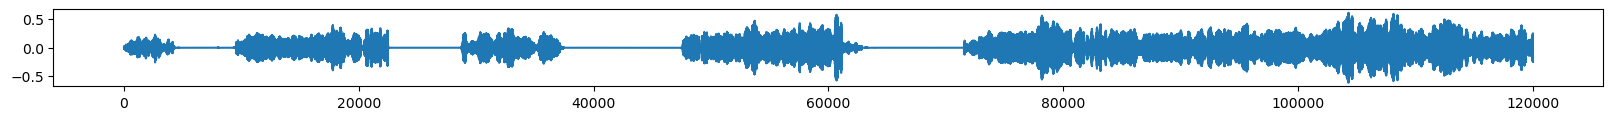

Finished epoch number 72 with a total of 10000 debug_seqs
 time: 2025-11-28 15:10:46.451684, epoch 73,  Loss: 0.2191
  Quantizer 0 Loss: 2.1976
  Quantizer 1 Loss: 2.6904
  Quantizer 2 Loss: 3.3447
  Quantizer 3 Loss: 3.7942
  Quantizer 4 Loss: 4.1059
  Quantizer 5 Loss: 4.3089
  Quantizer 6 Loss: 4.5498
  Quantizer 7 Loss: 4.6878
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


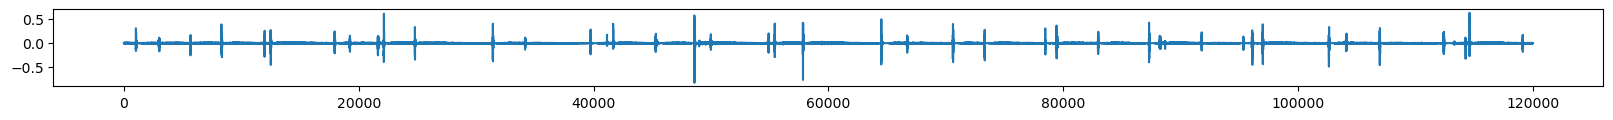

Finished epoch number 73 with a total of 10000 debug_seqs
 time: 2025-11-28 15:11:37.089286, epoch 74,  Loss: 0.2244
  Quantizer 0 Loss: 2.1974
  Quantizer 1 Loss: 2.7005
  Quantizer 2 Loss: 3.3532
  Quantizer 3 Loss: 3.7941
  Quantizer 4 Loss: 4.1118
  Quantizer 5 Loss: 4.3137
  Quantizer 6 Loss: 4.5570
  Quantizer 7 Loss: 4.6893
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


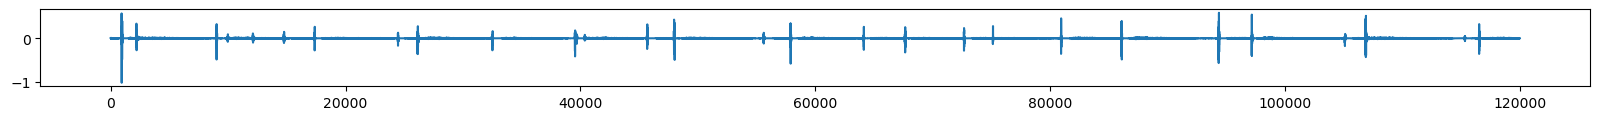

Finished epoch number 74 with a total of 10000 debug_seqs
 time: 2025-11-28 15:12:27.717688, epoch 75,  Loss: 0.2197
  Quantizer 0 Loss: 2.1866
  Quantizer 1 Loss: 2.6923
  Quantizer 2 Loss: 3.3471
  Quantizer 3 Loss: 3.7956
  Quantizer 4 Loss: 4.1148
  Quantizer 5 Loss: 4.3178
  Quantizer 6 Loss: 4.5587
  Quantizer 7 Loss: 4.6899
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


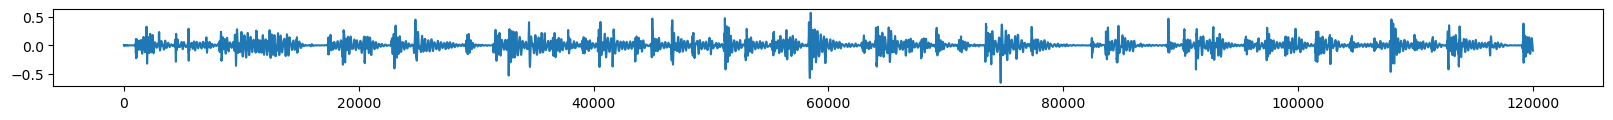

Saved checkpoint at epoch 75
Finished epoch number 75 with a total of 10000 debug_seqs
 time: 2025-11-28 15:13:20.100550, epoch 76,  Loss: 0.2429
  Quantizer 0 Loss: 2.2726
  Quantizer 1 Loss: 3.3321
  Quantizer 2 Loss: 4.0242
  Quantizer 3 Loss: 4.4658
  Quantizer 4 Loss: 4.7421
  Quantizer 5 Loss: 4.9251
  Quantizer 6 Loss: 5.1475
  Quantizer 7 Loss: 5.2463
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


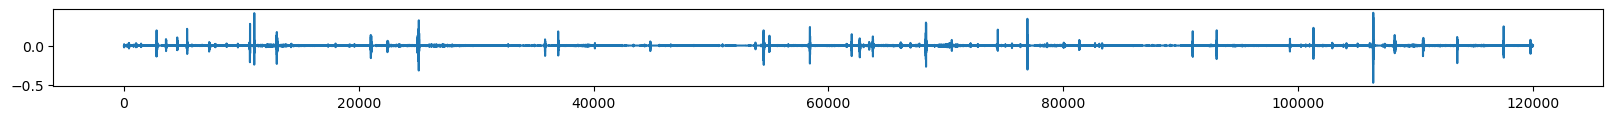

Finished epoch number 76 with a total of 10000 debug_seqs
 time: 2025-11-28 15:14:10.687692, epoch 77,  Loss: 0.2460
  Quantizer 0 Loss: 2.2379
  Quantizer 1 Loss: 3.2256
  Quantizer 2 Loss: 3.9543
  Quantizer 3 Loss: 4.4136
  Quantizer 4 Loss: 4.7005
  Quantizer 5 Loss: 4.8913
  Quantizer 6 Loss: 5.1217
  Quantizer 7 Loss: 5.2205
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


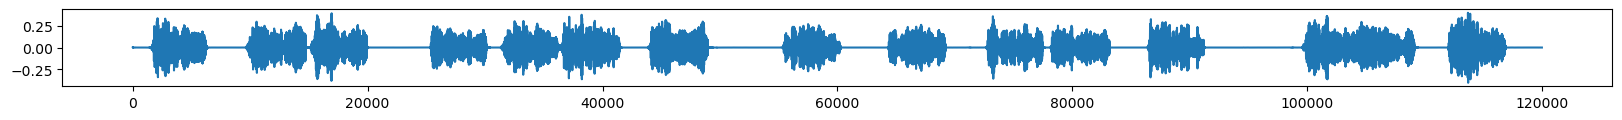

Finished epoch number 77 with a total of 10000 debug_seqs
 time: 2025-11-28 15:15:01.472836, epoch 78,  Loss: 0.2412
  Quantizer 0 Loss: 2.1986
  Quantizer 1 Loss: 3.1433
  Quantizer 2 Loss: 3.8919
  Quantizer 3 Loss: 4.3528
  Quantizer 4 Loss: 4.6630
  Quantizer 5 Loss: 4.8513
  Quantizer 6 Loss: 5.0819
  Quantizer 7 Loss: 5.1870
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


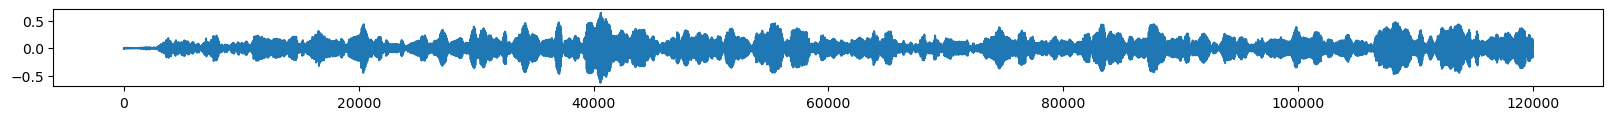

Finished epoch number 78 with a total of 10000 debug_seqs
 time: 2025-11-28 15:15:53.864488, epoch 79,  Loss: 0.2480
  Quantizer 0 Loss: 2.1999
  Quantizer 1 Loss: 3.1333
  Quantizer 2 Loss: 3.8809
  Quantizer 3 Loss: 4.3467
  Quantizer 4 Loss: 4.6484
  Quantizer 5 Loss: 4.8426
  Quantizer 6 Loss: 5.0708
  Quantizer 7 Loss: 5.1713
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


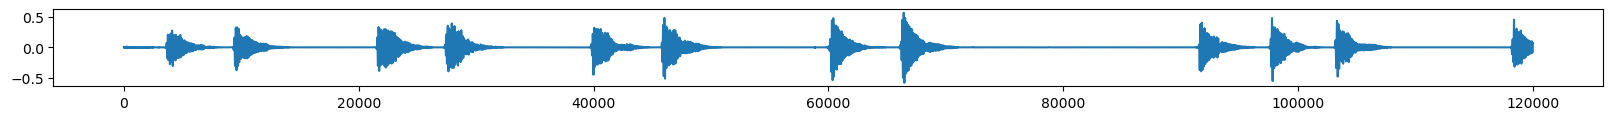

Finished epoch number 79 with a total of 10000 debug_seqs
 time: 2025-11-28 15:16:44.323929, epoch 80,  Loss: 0.2458
  Quantizer 0 Loss: 2.2141
  Quantizer 1 Loss: 3.1497
  Quantizer 2 Loss: 3.9024
  Quantizer 3 Loss: 4.3675
  Quantizer 4 Loss: 4.6699
  Quantizer 5 Loss: 4.8556
  Quantizer 6 Loss: 5.0924
  Quantizer 7 Loss: 5.1888
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


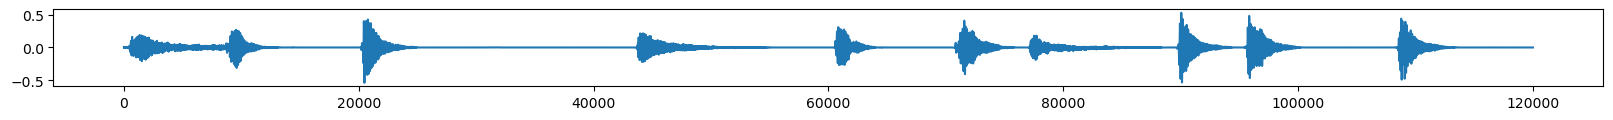

Finished epoch number 80 with a total of 10000 debug_seqs
 time: 2025-11-28 15:17:36.563019, epoch 81,  Loss: 0.2391
  Quantizer 0 Loss: 2.1969
  Quantizer 1 Loss: 3.1208
  Quantizer 2 Loss: 3.8746
  Quantizer 3 Loss: 4.3425
  Quantizer 4 Loss: 4.6506
  Quantizer 5 Loss: 4.8401
  Quantizer 6 Loss: 5.0690
  Quantizer 7 Loss: 5.1698
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


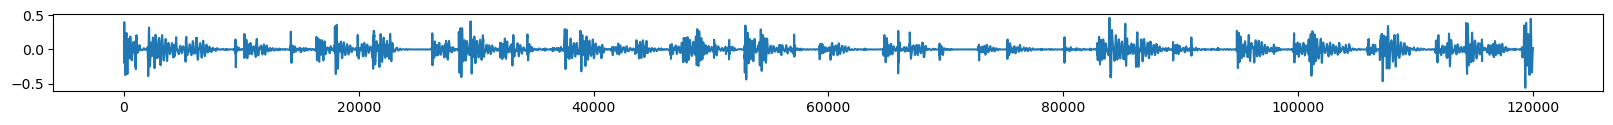

Finished epoch number 81 with a total of 10000 debug_seqs
 time: 2025-11-28 15:18:28.798292, epoch 82,  Loss: 0.2472
  Quantizer 0 Loss: 2.1950
  Quantizer 1 Loss: 3.1244
  Quantizer 2 Loss: 3.8734
  Quantizer 3 Loss: 4.3454
  Quantizer 4 Loss: 4.6531
  Quantizer 5 Loss: 4.8510
  Quantizer 6 Loss: 5.0770
  Quantizer 7 Loss: 5.1803
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


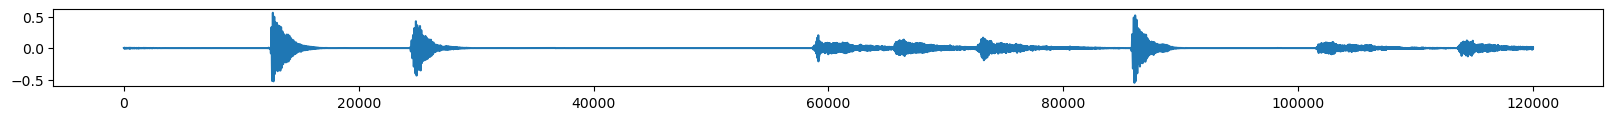

Finished epoch number 82 with a total of 10000 debug_seqs
 time: 2025-11-28 15:19:20.561288, epoch 83,  Loss: 0.2531
  Quantizer 0 Loss: 2.2036
  Quantizer 1 Loss: 3.1243
  Quantizer 2 Loss: 3.8714
  Quantizer 3 Loss: 4.3425
  Quantizer 4 Loss: 4.6493
  Quantizer 5 Loss: 4.8439
  Quantizer 6 Loss: 5.0737
  Quantizer 7 Loss: 5.1755
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


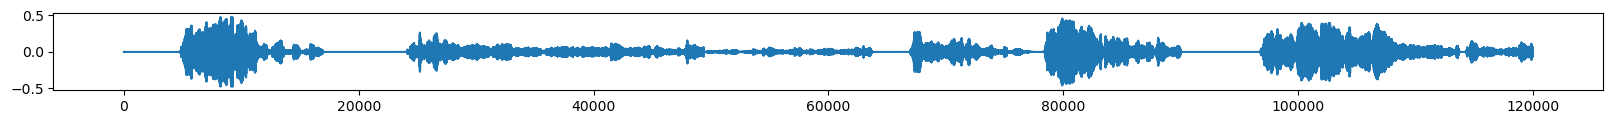

Finished epoch number 83 with a total of 10000 debug_seqs
 time: 2025-11-28 15:20:10.410533, epoch 84,  Loss: 0.2556
  Quantizer 0 Loss: 2.2069
  Quantizer 1 Loss: 3.1250
  Quantizer 2 Loss: 3.8779
  Quantizer 3 Loss: 4.3426
  Quantizer 4 Loss: 4.6477
  Quantizer 5 Loss: 4.8438
  Quantizer 6 Loss: 5.0701
  Quantizer 7 Loss: 5.1711
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


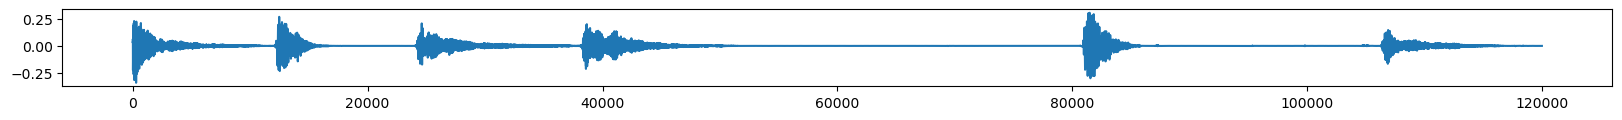

Finished epoch number 84 with a total of 10000 debug_seqs
 time: 2025-11-28 15:21:01.788300, epoch 85,  Loss: 0.2458
  Quantizer 0 Loss: 2.1909
  Quantizer 1 Loss: 3.1109
  Quantizer 2 Loss: 3.8656
  Quantizer 3 Loss: 4.3385
  Quantizer 4 Loss: 4.6486
  Quantizer 5 Loss: 4.8441
  Quantizer 6 Loss: 5.0738
  Quantizer 7 Loss: 5.1753
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


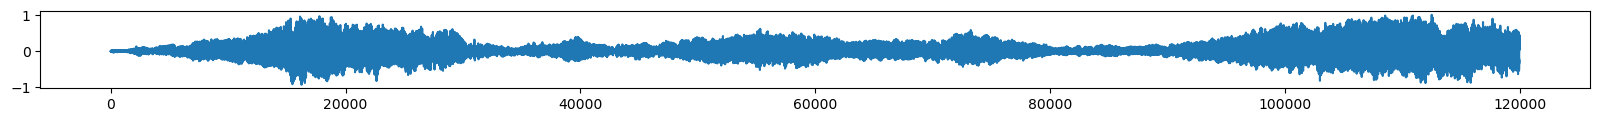

Finished epoch number 85 with a total of 10000 debug_seqs
 time: 2025-11-28 15:21:51.913524, epoch 86,  Loss: 0.2415
  Quantizer 0 Loss: 2.1872
  Quantizer 1 Loss: 3.1016
  Quantizer 2 Loss: 3.8564
  Quantizer 3 Loss: 4.3267
  Quantizer 4 Loss: 4.6350
  Quantizer 5 Loss: 4.8290
  Quantizer 6 Loss: 5.0600
  Quantizer 7 Loss: 5.1607
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


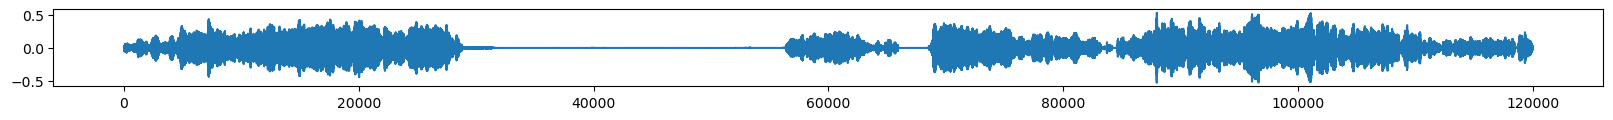

Finished epoch number 86 with a total of 10000 debug_seqs
 time: 2025-11-28 15:22:42.275347, epoch 87,  Loss: 0.2417
  Quantizer 0 Loss: 2.1905
  Quantizer 1 Loss: 3.1044
  Quantizer 2 Loss: 3.8637
  Quantizer 3 Loss: 4.3315
  Quantizer 4 Loss: 4.6438
  Quantizer 5 Loss: 4.8400
  Quantizer 6 Loss: 5.0671
  Quantizer 7 Loss: 5.1712
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


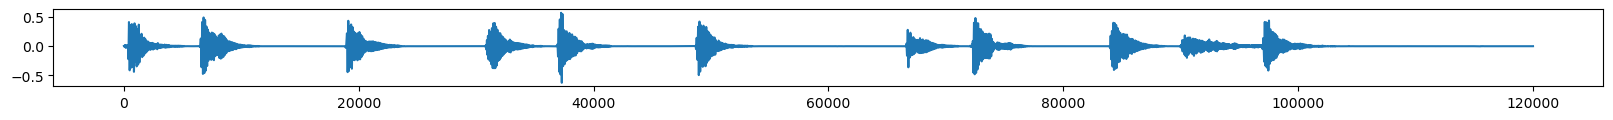

Finished epoch number 87 with a total of 10000 debug_seqs
 time: 2025-11-28 15:23:35.754540, epoch 88,  Loss: 0.2534
  Quantizer 0 Loss: 2.2106
  Quantizer 1 Loss: 3.1148
  Quantizer 2 Loss: 3.8703
  Quantizer 3 Loss: 4.3349
  Quantizer 4 Loss: 4.6452
  Quantizer 5 Loss: 4.8328
  Quantizer 6 Loss: 5.0622
  Quantizer 7 Loss: 5.1629
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


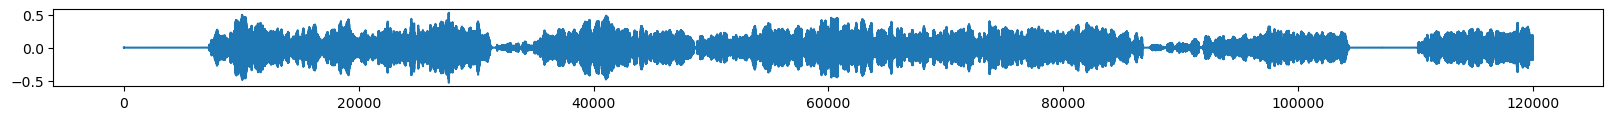

Finished epoch number 88 with a total of 10000 debug_seqs
 time: 2025-11-28 15:24:27.200233, epoch 89,  Loss: 0.2470
  Quantizer 0 Loss: 2.1922
  Quantizer 1 Loss: 3.1067
  Quantizer 2 Loss: 3.8615
  Quantizer 3 Loss: 4.3297
  Quantizer 4 Loss: 4.6393
  Quantizer 5 Loss: 4.8339
  Quantizer 6 Loss: 5.0630
  Quantizer 7 Loss: 5.1726
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


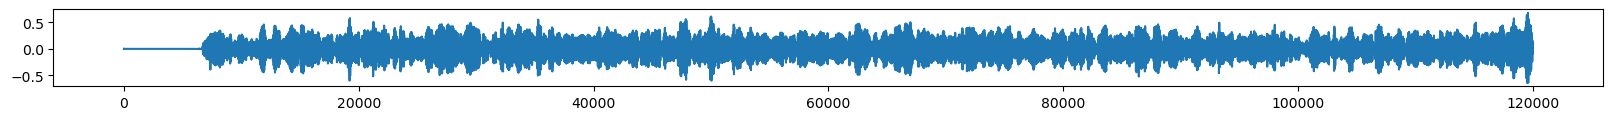

Finished epoch number 89 with a total of 10000 debug_seqs
 time: 2025-11-28 15:25:17.469466, epoch 90,  Loss: 0.2432
  Quantizer 0 Loss: 2.1850
  Quantizer 1 Loss: 3.0937
  Quantizer 2 Loss: 3.8447
  Quantizer 3 Loss: 4.3188
  Quantizer 4 Loss: 4.6308
  Quantizer 5 Loss: 4.8203
  Quantizer 6 Loss: 5.0545
  Quantizer 7 Loss: 5.1577
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


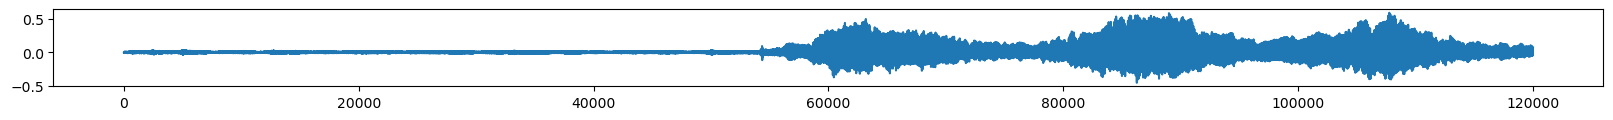

Finished epoch number 90 with a total of 10000 debug_seqs
 time: 2025-11-28 15:26:08.662608, epoch 91,  Loss: 0.2451
  Quantizer 0 Loss: 2.1871
  Quantizer 1 Loss: 3.1001
  Quantizer 2 Loss: 3.8489
  Quantizer 3 Loss: 4.3236
  Quantizer 4 Loss: 4.6307
  Quantizer 5 Loss: 4.8236
  Quantizer 6 Loss: 5.0478
  Quantizer 7 Loss: 5.1576
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


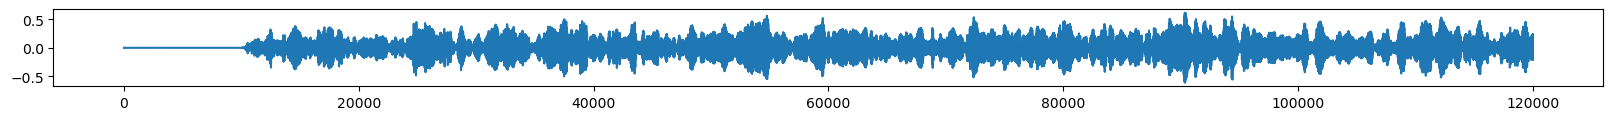

Finished epoch number 91 with a total of 10000 debug_seqs
 time: 2025-11-28 15:26:59.821243, epoch 92,  Loss: 0.2408
  Quantizer 0 Loss: 2.1854
  Quantizer 1 Loss: 3.0979
  Quantizer 2 Loss: 3.8535
  Quantizer 3 Loss: 4.3223
  Quantizer 4 Loss: 4.6328
  Quantizer 5 Loss: 4.8266
  Quantizer 6 Loss: 5.0526
  Quantizer 7 Loss: 5.1614
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


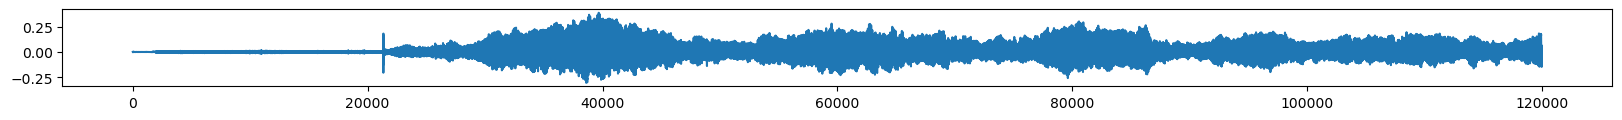

Finished epoch number 92 with a total of 10000 debug_seqs
 time: 2025-11-28 15:27:50.862679, epoch 93,  Loss: 0.2508
  Quantizer 0 Loss: 2.1933
  Quantizer 1 Loss: 3.1034
  Quantizer 2 Loss: 3.8554
  Quantizer 3 Loss: 4.3185
  Quantizer 4 Loss: 4.6334
  Quantizer 5 Loss: 4.8257
  Quantizer 6 Loss: 5.0614
  Quantizer 7 Loss: 5.1626
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


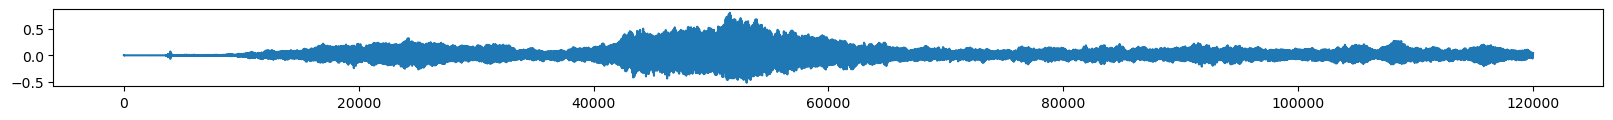

Finished epoch number 93 with a total of 10000 debug_seqs
 time: 2025-11-28 15:28:41.783263, epoch 94,  Loss: 0.2463
  Quantizer 0 Loss: 2.1790
  Quantizer 1 Loss: 3.0875
  Quantizer 2 Loss: 3.8371
  Quantizer 3 Loss: 4.3124
  Quantizer 4 Loss: 4.6191
  Quantizer 5 Loss: 4.8139
  Quantizer 6 Loss: 5.0387
  Quantizer 7 Loss: 5.1476
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


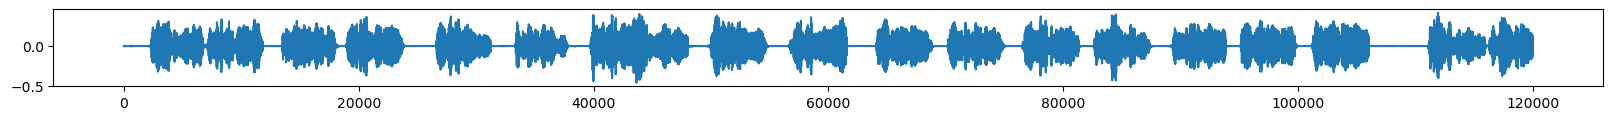

Finished epoch number 94 with a total of 10000 debug_seqs
 time: 2025-11-28 15:29:31.588396, epoch 95,  Loss: 0.2452
  Quantizer 0 Loss: 2.1940
  Quantizer 1 Loss: 3.1184
  Quantizer 2 Loss: 3.8585
  Quantizer 3 Loss: 4.3299
  Quantizer 4 Loss: 4.6326
  Quantizer 5 Loss: 4.8263
  Quantizer 6 Loss: 5.0615
  Quantizer 7 Loss: 5.1626
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


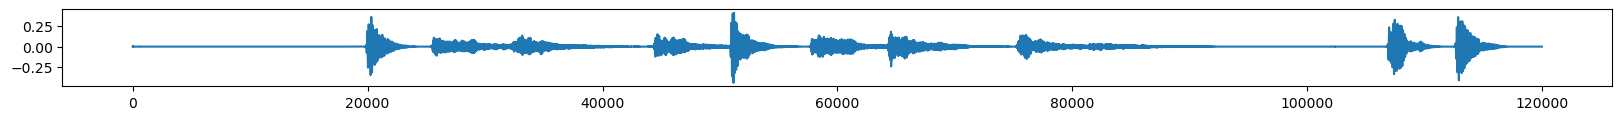

Finished epoch number 95 with a total of 10000 debug_seqs
 time: 2025-11-28 15:30:22.287703, epoch 96,  Loss: 0.2430
  Quantizer 0 Loss: 2.1757
  Quantizer 1 Loss: 3.0894
  Quantizer 2 Loss: 3.8427
  Quantizer 3 Loss: 4.3073
  Quantizer 4 Loss: 4.6172
  Quantizer 5 Loss: 4.8149
  Quantizer 6 Loss: 5.0452
  Quantizer 7 Loss: 5.1481
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


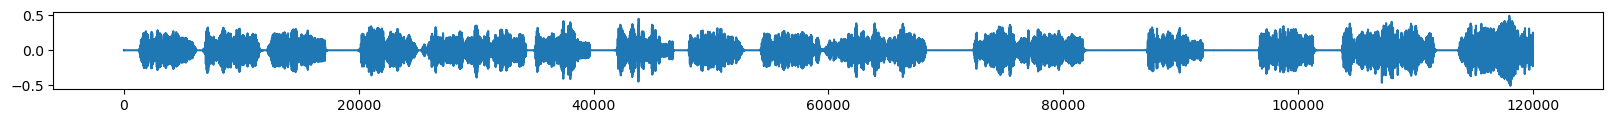

Finished epoch number 96 with a total of 10000 debug_seqs
 time: 2025-11-28 15:31:12.693794, epoch 97,  Loss: 0.2490
  Quantizer 0 Loss: 2.1848
  Quantizer 1 Loss: 3.0933
  Quantizer 2 Loss: 3.8486
  Quantizer 3 Loss: 4.3179
  Quantizer 4 Loss: 4.6238
  Quantizer 5 Loss: 4.8210
  Quantizer 6 Loss: 5.0479
  Quantizer 7 Loss: 5.1483
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


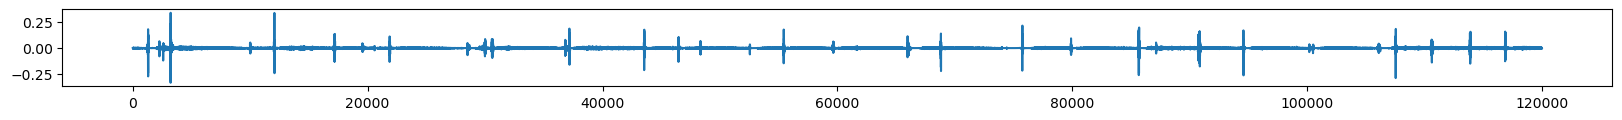

Finished epoch number 97 with a total of 10000 debug_seqs
 time: 2025-11-28 15:32:05.764563, epoch 98,  Loss: 0.2435
  Quantizer 0 Loss: 2.1920
  Quantizer 1 Loss: 3.0993
  Quantizer 2 Loss: 3.8522
  Quantizer 3 Loss: 4.3282
  Quantizer 4 Loss: 4.6291
  Quantizer 5 Loss: 4.8202
  Quantizer 6 Loss: 5.0510
  Quantizer 7 Loss: 5.1538
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


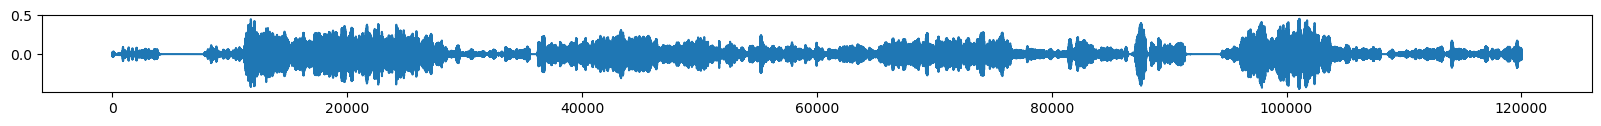

Finished epoch number 98 with a total of 10000 debug_seqs
 time: 2025-11-28 15:32:56.143715, epoch 99,  Loss: 0.2445
  Quantizer 0 Loss: 2.1837
  Quantizer 1 Loss: 3.0939
  Quantizer 2 Loss: 3.8447
  Quantizer 3 Loss: 4.3180
  Quantizer 4 Loss: 4.6271
  Quantizer 5 Loss: 4.8210
  Quantizer 6 Loss: 5.0500
  Quantizer 7 Loss: 5.1596
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


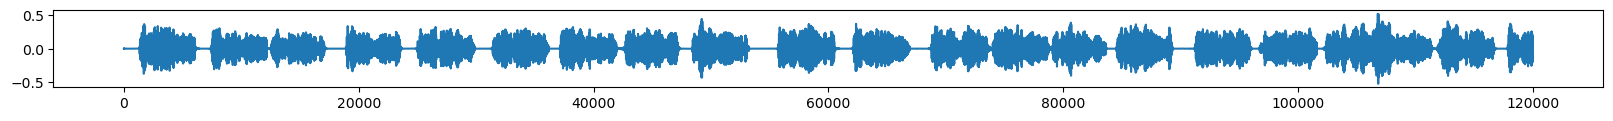

Finished epoch number 99 with a total of 10000 debug_seqs
 time: 2025-11-28 15:33:46.305562, epoch 100,  Loss: 0.2501
  Quantizer 0 Loss: 2.1820
  Quantizer 1 Loss: 3.0762
  Quantizer 2 Loss: 3.8295
  Quantizer 3 Loss: 4.2970
  Quantizer 4 Loss: 4.6092
  Quantizer 5 Loss: 4.8015
  Quantizer 6 Loss: 5.0306
  Quantizer 7 Loss: 5.1351
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


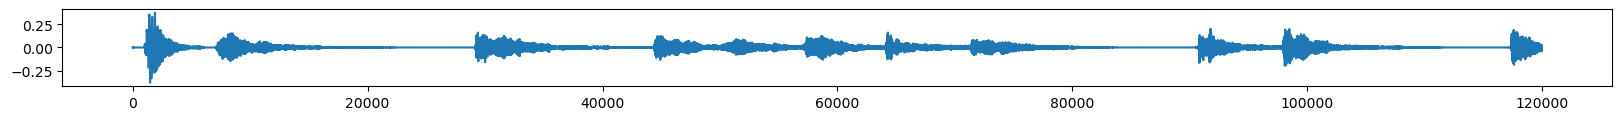

Saved checkpoint at epoch 100
Finished epoch number 100 with a total of 10000 debug_seqs
 time: 2025-11-28 15:34:37.235218, epoch 101,  Loss: 0.2220
  Quantizer 0 Loss: 2.1573
  Quantizer 1 Loss: 2.7174
  Quantizer 2 Loss: 3.4044
  Quantizer 3 Loss: 3.8752
  Quantizer 4 Loss: 4.2069
  Quantizer 5 Loss: 4.4176
  Quantizer 6 Loss: 4.6600
  Quantizer 7 Loss: 4.7967
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


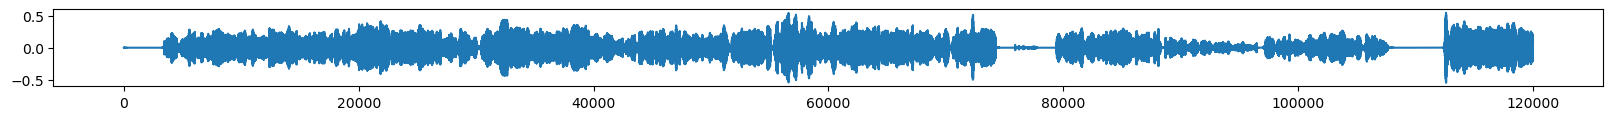

Finished epoch number 101 with a total of 10000 debug_seqs
 time: 2025-11-28 15:35:28.392644, epoch 102,  Loss: 0.2147
  Quantizer 0 Loss: 2.1591
  Quantizer 1 Loss: 2.6811
  Quantizer 2 Loss: 3.3547
  Quantizer 3 Loss: 3.8134
  Quantizer 4 Loss: 4.1383
  Quantizer 5 Loss: 4.3462
  Quantizer 6 Loss: 4.5953
  Quantizer 7 Loss: 4.7213
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


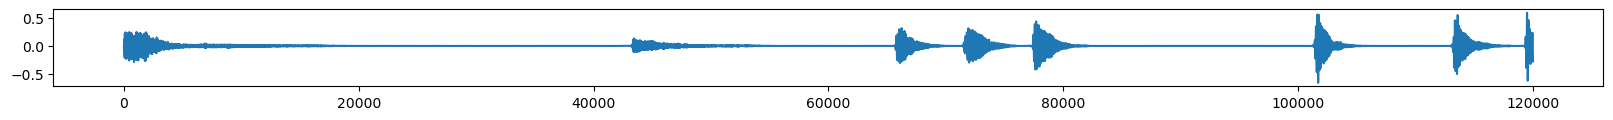

Finished epoch number 102 with a total of 10000 debug_seqs
 time: 2025-11-28 15:36:19.307631, epoch 103,  Loss: 0.2234
  Quantizer 0 Loss: 2.1769
  Quantizer 1 Loss: 2.6930
  Quantizer 2 Loss: 3.3539
  Quantizer 3 Loss: 3.8199
  Quantizer 4 Loss: 4.1324
  Quantizer 5 Loss: 4.3376
  Quantizer 6 Loss: 4.5810
  Quantizer 7 Loss: 4.7137
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


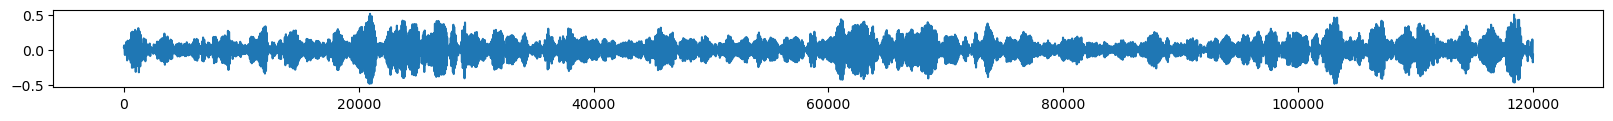

Finished epoch number 103 with a total of 10000 debug_seqs
 time: 2025-11-28 15:37:11.736795, epoch 104,  Loss: 0.2227
  Quantizer 0 Loss: 2.1760
  Quantizer 1 Loss: 2.6864
  Quantizer 2 Loss: 3.3523
  Quantizer 3 Loss: 3.8078
  Quantizer 4 Loss: 4.1215
  Quantizer 5 Loss: 4.3250
  Quantizer 6 Loss: 4.5703
  Quantizer 7 Loss: 4.6983
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


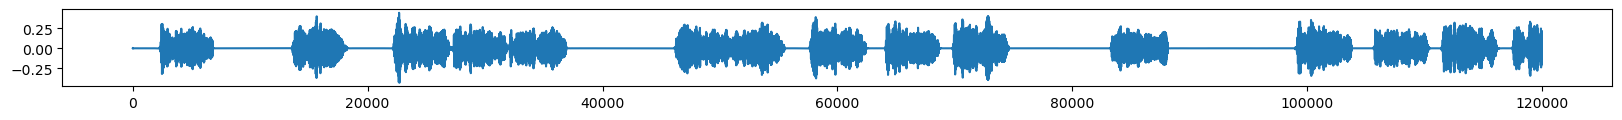

Finished epoch number 104 with a total of 10000 debug_seqs
 time: 2025-11-28 15:38:01.152690, epoch 105,  Loss: 0.2268
  Quantizer 0 Loss: 2.1612
  Quantizer 1 Loss: 2.6700
  Quantizer 2 Loss: 3.3305
  Quantizer 3 Loss: 3.7869
  Quantizer 4 Loss: 4.1053
  Quantizer 5 Loss: 4.3099
  Quantizer 6 Loss: 4.5558
  Quantizer 7 Loss: 4.6870
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


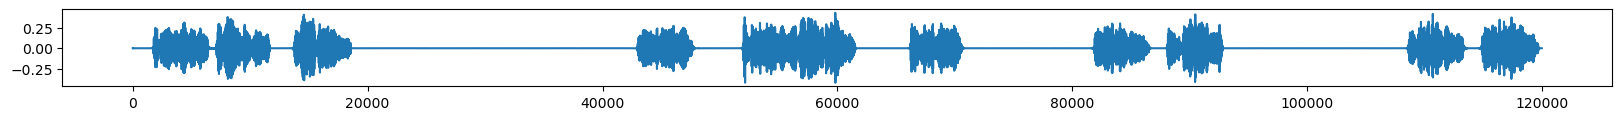

Finished epoch number 105 with a total of 10000 debug_seqs
 time: 2025-11-28 15:38:51.066427, epoch 106,  Loss: 0.2192
  Quantizer 0 Loss: 2.1714
  Quantizer 1 Loss: 2.6671
  Quantizer 2 Loss: 3.3320
  Quantizer 3 Loss: 3.7862
  Quantizer 4 Loss: 4.0983
  Quantizer 5 Loss: 4.3080
  Quantizer 6 Loss: 4.5475
  Quantizer 7 Loss: 4.6819
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


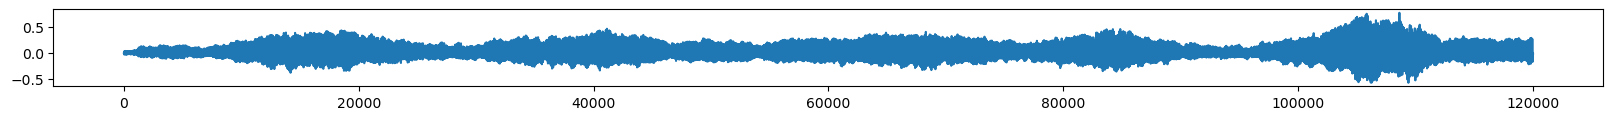

Finished epoch number 106 with a total of 10000 debug_seqs
 time: 2025-11-28 15:39:43.220905, epoch 107,  Loss: 0.2144
  Quantizer 0 Loss: 2.1740
  Quantizer 1 Loss: 2.6816
  Quantizer 2 Loss: 3.3384
  Quantizer 3 Loss: 3.7970
  Quantizer 4 Loss: 4.1124
  Quantizer 5 Loss: 4.3133
  Quantizer 6 Loss: 4.5611
  Quantizer 7 Loss: 4.6971
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


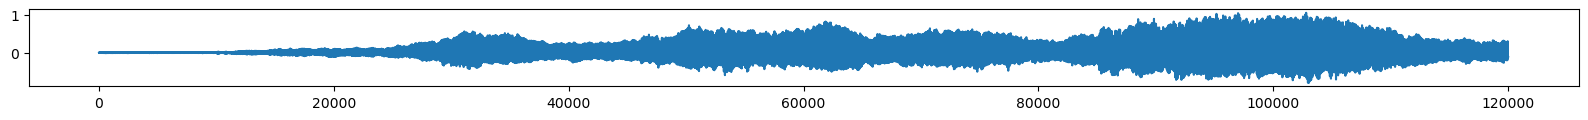

Finished epoch number 107 with a total of 10000 debug_seqs
 time: 2025-11-28 15:40:34.117480, epoch 108,  Loss: 0.2132
  Quantizer 0 Loss: 2.1688
  Quantizer 1 Loss: 2.6695
  Quantizer 2 Loss: 3.3312
  Quantizer 3 Loss: 3.7842
  Quantizer 4 Loss: 4.0994
  Quantizer 5 Loss: 4.3045
  Quantizer 6 Loss: 4.5472
  Quantizer 7 Loss: 4.6809
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


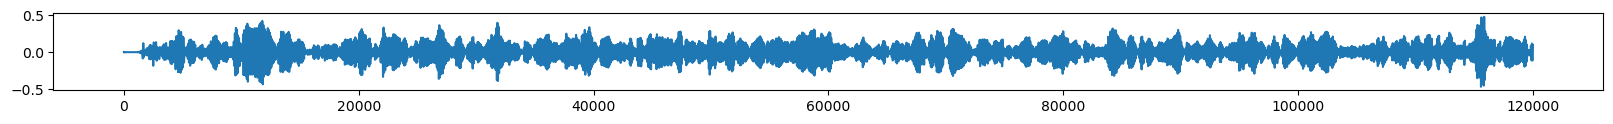

Finished epoch number 108 with a total of 10000 debug_seqs
 time: 2025-11-28 15:41:24.698575, epoch 109,  Loss: 0.2216
  Quantizer 0 Loss: 2.1686
  Quantizer 1 Loss: 2.6706
  Quantizer 2 Loss: 3.3274
  Quantizer 3 Loss: 3.7797
  Quantizer 4 Loss: 4.0944
  Quantizer 5 Loss: 4.3006
  Quantizer 6 Loss: 4.5464
  Quantizer 7 Loss: 4.6821
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


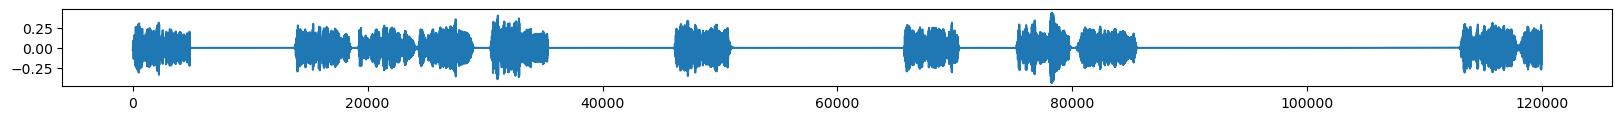

Finished epoch number 109 with a total of 10000 debug_seqs
 time: 2025-11-28 15:42:14.513627, epoch 110,  Loss: 0.2280
  Quantizer 0 Loss: 2.1679
  Quantizer 1 Loss: 2.6704
  Quantizer 2 Loss: 3.3233
  Quantizer 3 Loss: 3.7774
  Quantizer 4 Loss: 4.0893
  Quantizer 5 Loss: 4.2904
  Quantizer 6 Loss: 4.5344
  Quantizer 7 Loss: 4.6684
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


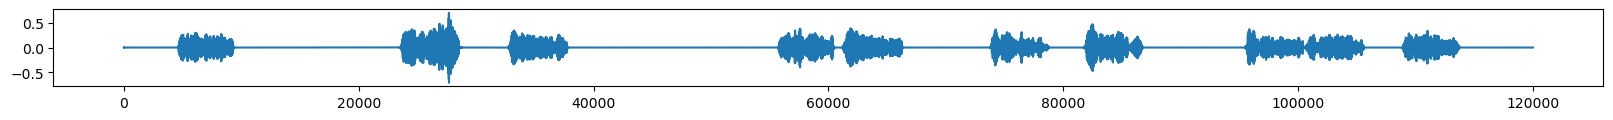

Finished epoch number 110 with a total of 10000 debug_seqs
 time: 2025-11-28 15:43:05.003917, epoch 111,  Loss: 0.2170
  Quantizer 0 Loss: 2.1523
  Quantizer 1 Loss: 2.6479
  Quantizer 2 Loss: 3.3052
  Quantizer 3 Loss: 3.7566
  Quantizer 4 Loss: 4.0750
  Quantizer 5 Loss: 4.2790
  Quantizer 6 Loss: 4.5213
  Quantizer 7 Loss: 4.6598
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


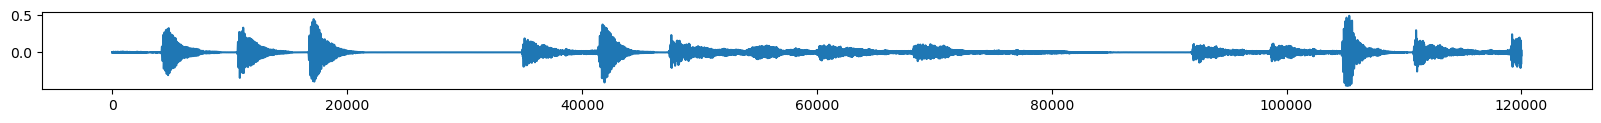

Finished epoch number 111 with a total of 10000 debug_seqs
 time: 2025-11-28 15:43:57.185652, epoch 112,  Loss: 0.2242
  Quantizer 0 Loss: 2.1768
  Quantizer 1 Loss: 2.6818
  Quantizer 2 Loss: 3.3281
  Quantizer 3 Loss: 3.7807
  Quantizer 4 Loss: 4.0944
  Quantizer 5 Loss: 4.3000
  Quantizer 6 Loss: 4.5480
  Quantizer 7 Loss: 4.6843
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


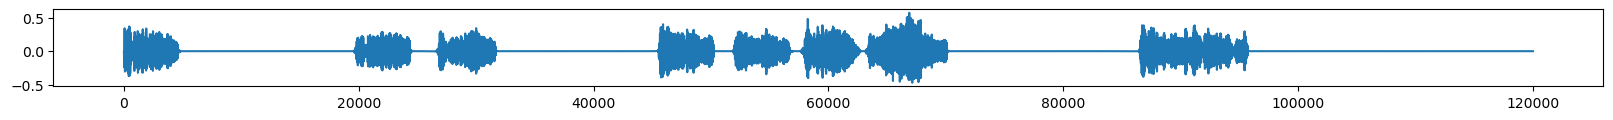

Finished epoch number 112 with a total of 10000 debug_seqs
 time: 2025-11-28 15:44:47.887391, epoch 113,  Loss: 0.2236
  Quantizer 0 Loss: 2.1721
  Quantizer 1 Loss: 2.6798
  Quantizer 2 Loss: 3.3286
  Quantizer 3 Loss: 3.7829
  Quantizer 4 Loss: 4.0946
  Quantizer 5 Loss: 4.3051
  Quantizer 6 Loss: 4.5539
  Quantizer 7 Loss: 4.6812
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


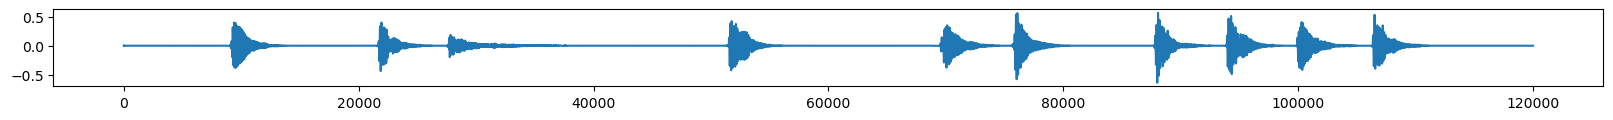

Finished epoch number 113 with a total of 10000 debug_seqs
 time: 2025-11-28 15:45:38.146899, epoch 114,  Loss: 0.2183
  Quantizer 0 Loss: 2.1756
  Quantizer 1 Loss: 2.6723
  Quantizer 2 Loss: 3.3299
  Quantizer 3 Loss: 3.7834
  Quantizer 4 Loss: 4.0984
  Quantizer 5 Loss: 4.3054
  Quantizer 6 Loss: 4.5434
  Quantizer 7 Loss: 4.6797
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


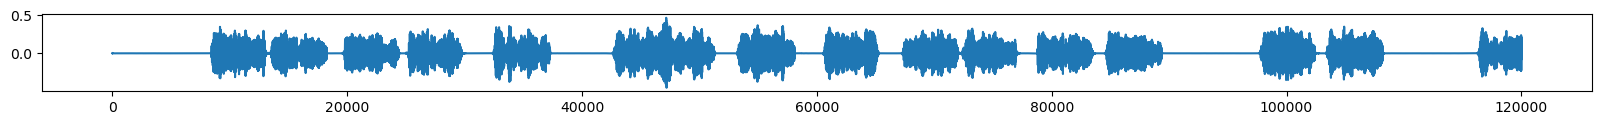

Finished epoch number 114 with a total of 10000 debug_seqs
 time: 2025-11-28 15:46:31.437582, epoch 115,  Loss: 0.2170
  Quantizer 0 Loss: 2.1757
  Quantizer 1 Loss: 2.6725
  Quantizer 2 Loss: 3.3238
  Quantizer 3 Loss: 3.7800
  Quantizer 4 Loss: 4.0902
  Quantizer 5 Loss: 4.3013
  Quantizer 6 Loss: 4.5465
  Quantizer 7 Loss: 4.6765
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


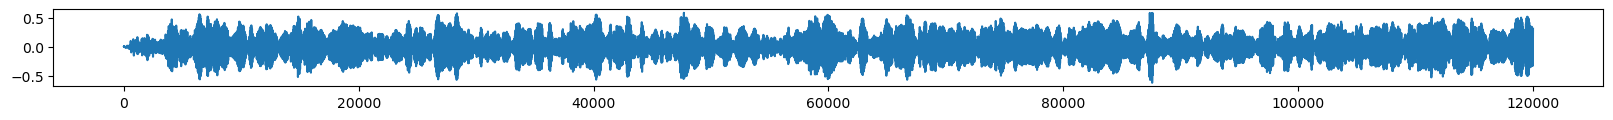

Finished epoch number 115 with a total of 10000 debug_seqs
 time: 2025-11-28 15:47:23.706786, epoch 116,  Loss: 0.2186
  Quantizer 0 Loss: 2.1692
  Quantizer 1 Loss: 2.6730
  Quantizer 2 Loss: 3.3248
  Quantizer 3 Loss: 3.7729
  Quantizer 4 Loss: 4.0883
  Quantizer 5 Loss: 4.2922
  Quantizer 6 Loss: 4.5377
  Quantizer 7 Loss: 4.6685
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


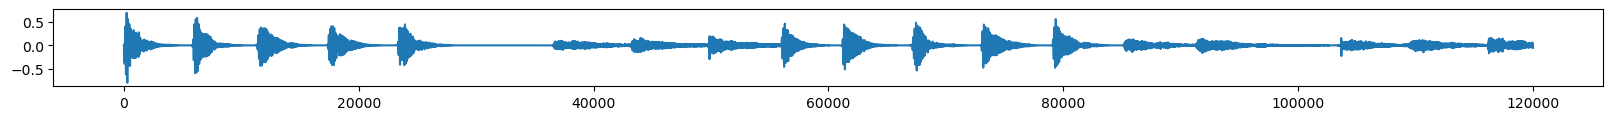

Finished epoch number 116 with a total of 10000 debug_seqs
 time: 2025-11-28 15:48:15.878610, epoch 117,  Loss: 0.2062
  Quantizer 0 Loss: 2.1665
  Quantizer 1 Loss: 2.6603
  Quantizer 2 Loss: 3.3125
  Quantizer 3 Loss: 3.7635
  Quantizer 4 Loss: 4.0760
  Quantizer 5 Loss: 4.2888
  Quantizer 6 Loss: 4.5271
  Quantizer 7 Loss: 4.6635
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


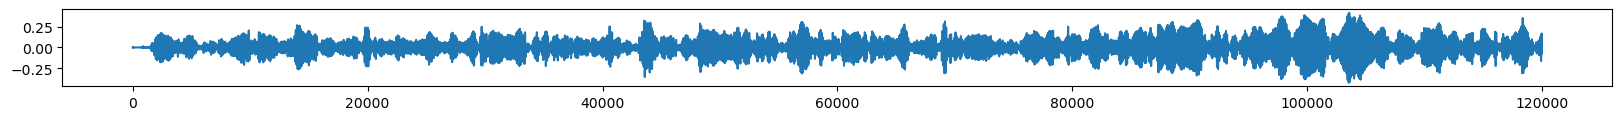

Finished epoch number 117 with a total of 10000 debug_seqs
 time: 2025-11-28 15:49:07.460100, epoch 118,  Loss: 0.2101
  Quantizer 0 Loss: 2.1576
  Quantizer 1 Loss: 2.6562
  Quantizer 2 Loss: 3.3062
  Quantizer 3 Loss: 3.7602
  Quantizer 4 Loss: 4.0747
  Quantizer 5 Loss: 4.2832
  Quantizer 6 Loss: 4.5276
  Quantizer 7 Loss: 4.6623
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


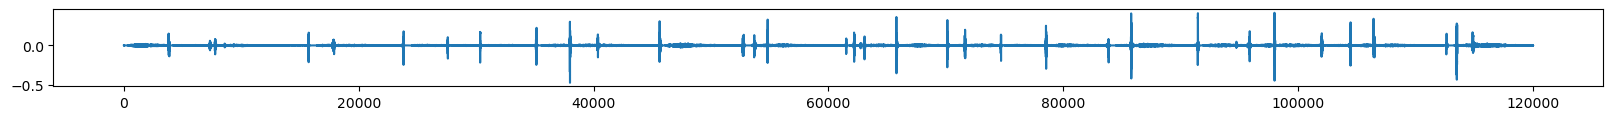

Finished epoch number 118 with a total of 10000 debug_seqs
 time: 2025-11-28 15:49:57.794979, epoch 119,  Loss: 0.2173
  Quantizer 0 Loss: 2.1845
  Quantizer 1 Loss: 2.6794
  Quantizer 2 Loss: 3.3312
  Quantizer 3 Loss: 3.7851
  Quantizer 4 Loss: 4.0951
  Quantizer 5 Loss: 4.2987
  Quantizer 6 Loss: 4.5433
  Quantizer 7 Loss: 4.6740
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


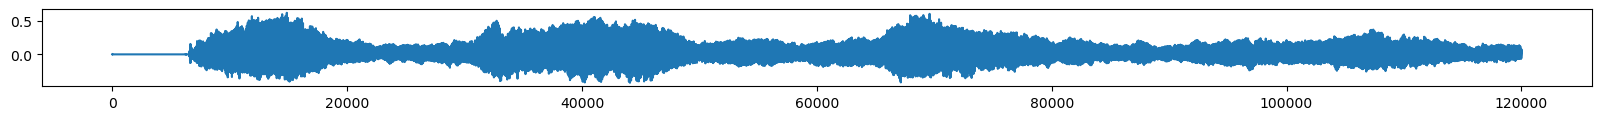

Finished epoch number 119 with a total of 10000 debug_seqs
 time: 2025-11-28 15:50:48.494915, epoch 120,  Loss: 0.2152
  Quantizer 0 Loss: 2.1655
  Quantizer 1 Loss: 2.6714
  Quantizer 2 Loss: 3.3179
  Quantizer 3 Loss: 3.7737
  Quantizer 4 Loss: 4.0933
  Quantizer 5 Loss: 4.2964
  Quantizer 6 Loss: 4.5427
  Quantizer 7 Loss: 4.6781
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


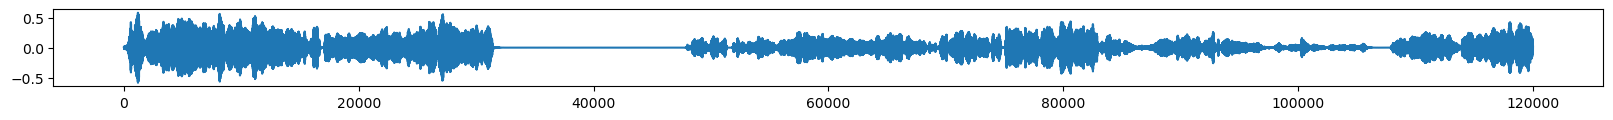

Finished epoch number 120 with a total of 10000 debug_seqs
 time: 2025-11-28 15:51:40.868268, epoch 121,  Loss: 0.2181
  Quantizer 0 Loss: 2.1642
  Quantizer 1 Loss: 2.6689
  Quantizer 2 Loss: 3.3173
  Quantizer 3 Loss: 3.7672
  Quantizer 4 Loss: 4.0867
  Quantizer 5 Loss: 4.2879
  Quantizer 6 Loss: 4.5343
  Quantizer 7 Loss: 4.6678
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


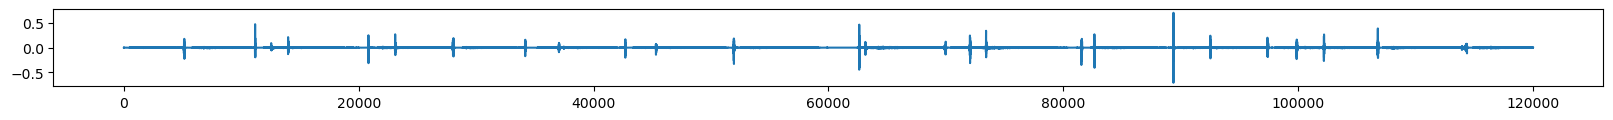

Finished epoch number 121 with a total of 10000 debug_seqs
 time: 2025-11-28 15:52:31.992307, epoch 122,  Loss: 0.2241
  Quantizer 0 Loss: 2.1718
  Quantizer 1 Loss: 2.6767
  Quantizer 2 Loss: 3.3270
  Quantizer 3 Loss: 3.7784
  Quantizer 4 Loss: 4.0918
  Quantizer 5 Loss: 4.2975
  Quantizer 6 Loss: 4.5428
  Quantizer 7 Loss: 4.6759
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


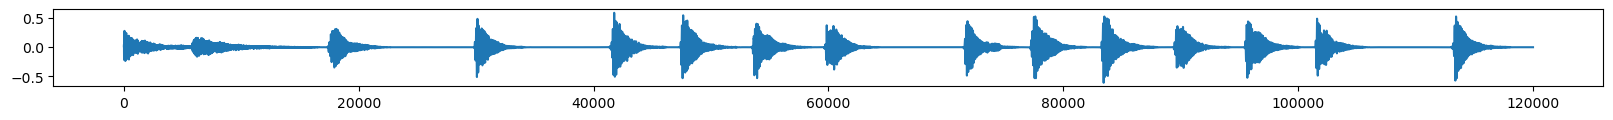

Finished epoch number 122 with a total of 10000 debug_seqs
 time: 2025-11-28 15:53:22.337071, epoch 123,  Loss: 0.2182
  Quantizer 0 Loss: 2.1643
  Quantizer 1 Loss: 2.6615
  Quantizer 2 Loss: 3.3180
  Quantizer 3 Loss: 3.7654
  Quantizer 4 Loss: 4.0811
  Quantizer 5 Loss: 4.2883
  Quantizer 6 Loss: 4.5334
  Quantizer 7 Loss: 4.6705
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


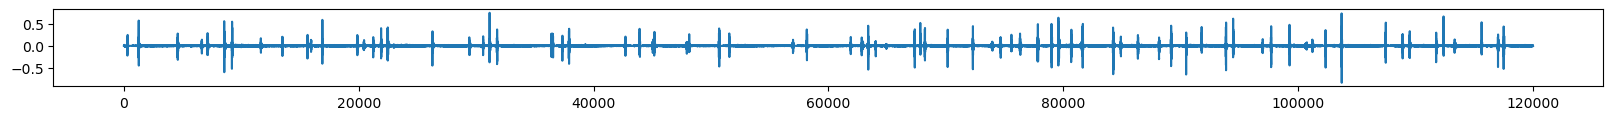

Finished epoch number 123 with a total of 10000 debug_seqs
 time: 2025-11-28 15:54:12.482669, epoch 124,  Loss: 0.2147
  Quantizer 0 Loss: 2.1803
  Quantizer 1 Loss: 2.6709
  Quantizer 2 Loss: 3.3198
  Quantizer 3 Loss: 3.7703
  Quantizer 4 Loss: 4.0833
  Quantizer 5 Loss: 4.2913
  Quantizer 6 Loss: 4.5344
  Quantizer 7 Loss: 4.6675
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


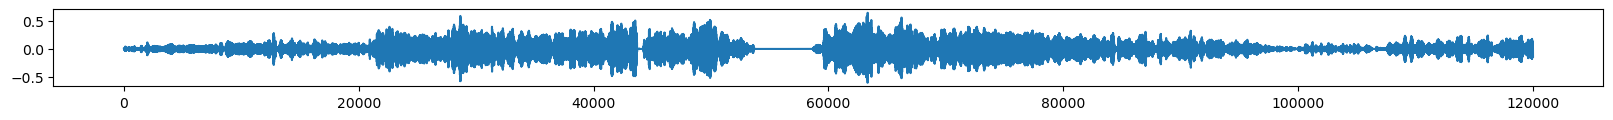

Finished epoch number 124 with a total of 10000 debug_seqs
 time: 2025-11-28 15:55:02.821631, epoch 125,  Loss: 0.2157
  Quantizer 0 Loss: 2.1652
  Quantizer 1 Loss: 2.6647
  Quantizer 2 Loss: 3.3170
  Quantizer 3 Loss: 3.7668
  Quantizer 4 Loss: 4.0812
  Quantizer 5 Loss: 4.2924
  Quantizer 6 Loss: 4.5324
  Quantizer 7 Loss: 4.6679
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


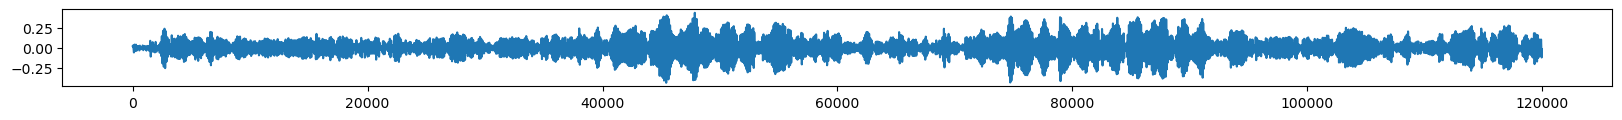

Saved checkpoint at epoch 125
Finished epoch number 125 with a total of 10000 debug_seqs
 time: 2025-11-28 15:55:55.051064, epoch 126,  Loss: 0.2530
  Quantizer 0 Loss: 2.3532
  Quantizer 1 Loss: 3.4681
  Quantizer 2 Loss: 4.0952
  Quantizer 3 Loss: 4.5104
  Quantizer 4 Loss: 4.7823
  Quantizer 5 Loss: 4.9606
  Quantizer 6 Loss: 5.1651
  Quantizer 7 Loss: 5.2589
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


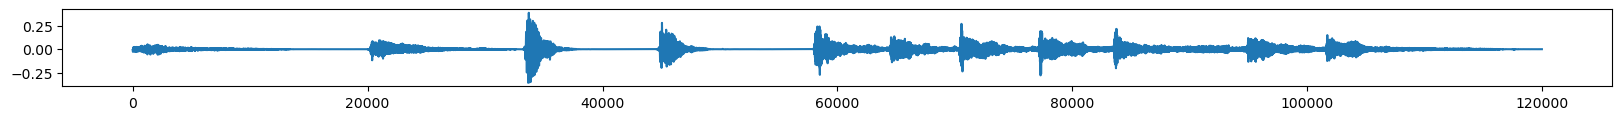

Finished epoch number 126 with a total of 10000 debug_seqs
 time: 2025-11-28 15:56:46.059240, epoch 127,  Loss: 0.2506
  Quantizer 0 Loss: 2.2172
  Quantizer 1 Loss: 3.1984
  Quantizer 2 Loss: 3.9275
  Quantizer 3 Loss: 4.3841
  Quantizer 4 Loss: 4.6799
  Quantizer 5 Loss: 4.8666
  Quantizer 6 Loss: 5.1031
  Quantizer 7 Loss: 5.2018
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


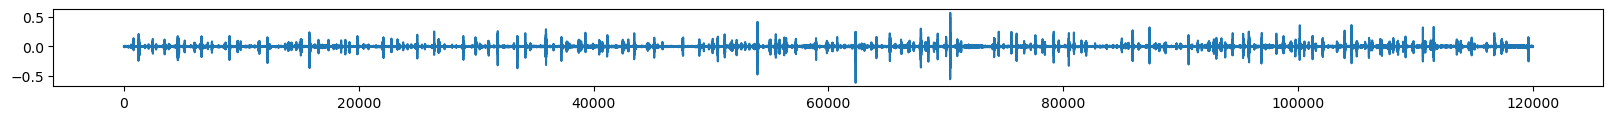

Finished epoch number 127 with a total of 10000 debug_seqs
 time: 2025-11-28 15:57:36.333971, epoch 128,  Loss: 0.2422
  Quantizer 0 Loss: 2.2141
  Quantizer 1 Loss: 3.1541
  Quantizer 2 Loss: 3.9078
  Quantizer 3 Loss: 4.3631
  Quantizer 4 Loss: 4.6703
  Quantizer 5 Loss: 4.8615
  Quantizer 6 Loss: 5.0824
  Quantizer 7 Loss: 5.1896
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


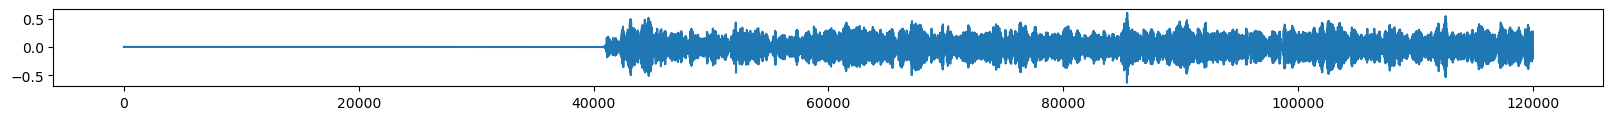

Finished epoch number 128 with a total of 10000 debug_seqs
 time: 2025-11-28 15:58:27.985924, epoch 129,  Loss: 0.2409
  Quantizer 0 Loss: 2.1772
  Quantizer 1 Loss: 3.1123
  Quantizer 2 Loss: 3.8615
  Quantizer 3 Loss: 4.3269
  Quantizer 4 Loss: 4.6370
  Quantizer 5 Loss: 4.8319
  Quantizer 6 Loss: 5.0599
  Quantizer 7 Loss: 5.1628
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


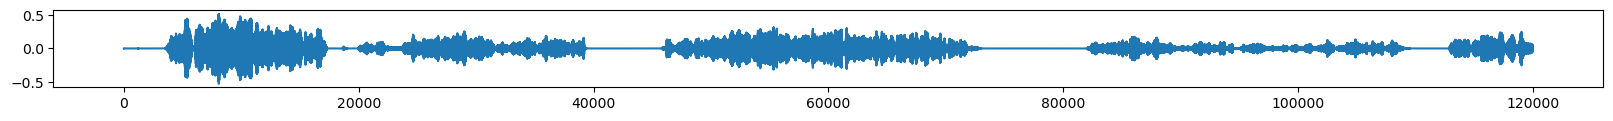

Finished epoch number 129 with a total of 10000 debug_seqs
 time: 2025-11-28 15:59:19.270537, epoch 130,  Loss: 0.2412
  Quantizer 0 Loss: 2.1789
  Quantizer 1 Loss: 3.1016
  Quantizer 2 Loss: 3.8508
  Quantizer 3 Loss: 4.3188
  Quantizer 4 Loss: 4.6300
  Quantizer 5 Loss: 4.8186
  Quantizer 6 Loss: 5.0534
  Quantizer 7 Loss: 5.1521
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


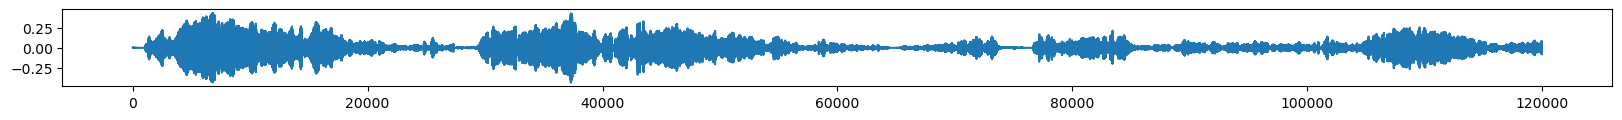

Finished epoch number 130 with a total of 10000 debug_seqs
 time: 2025-11-28 16:00:10.420958, epoch 131,  Loss: 0.2487
  Quantizer 0 Loss: 2.1713
  Quantizer 1 Loss: 3.0974
  Quantizer 2 Loss: 3.8490
  Quantizer 3 Loss: 4.3198
  Quantizer 4 Loss: 4.6332
  Quantizer 5 Loss: 4.8226
  Quantizer 6 Loss: 5.0518
  Quantizer 7 Loss: 5.1563
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


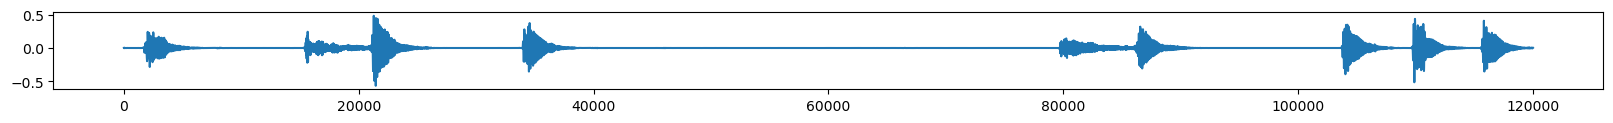

Finished epoch number 131 with a total of 10000 debug_seqs
 time: 2025-11-28 16:01:01.890153, epoch 132,  Loss: 0.2432
  Quantizer 0 Loss: 2.2029
  Quantizer 1 Loss: 3.1285
  Quantizer 2 Loss: 3.8745
  Quantizer 3 Loss: 4.3462
  Quantizer 4 Loss: 4.6470
  Quantizer 5 Loss: 4.8405
  Quantizer 6 Loss: 5.0769
  Quantizer 7 Loss: 5.1786
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


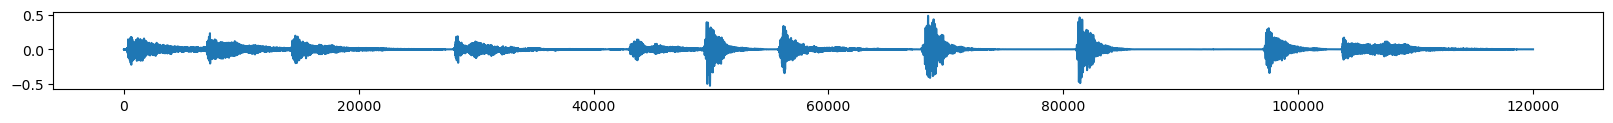

Finished epoch number 132 with a total of 10000 debug_seqs
 time: 2025-11-28 16:01:52.840214, epoch 133,  Loss: 0.2464
  Quantizer 0 Loss: 2.1885
  Quantizer 1 Loss: 3.1013
  Quantizer 2 Loss: 3.8571
  Quantizer 3 Loss: 4.3272
  Quantizer 4 Loss: 4.6370
  Quantizer 5 Loss: 4.8341
  Quantizer 6 Loss: 5.0663
  Quantizer 7 Loss: 5.1698
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


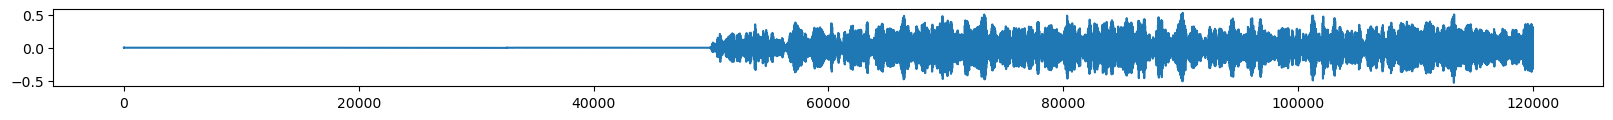

Finished epoch number 133 with a total of 10000 debug_seqs
 time: 2025-11-28 16:02:42.083324, epoch 134,  Loss: 0.2438
  Quantizer 0 Loss: 2.1807
  Quantizer 1 Loss: 3.0950
  Quantizer 2 Loss: 3.8498
  Quantizer 3 Loss: 4.3157
  Quantizer 4 Loss: 4.6264
  Quantizer 5 Loss: 4.8211
  Quantizer 6 Loss: 5.0531
  Quantizer 7 Loss: 5.1591
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


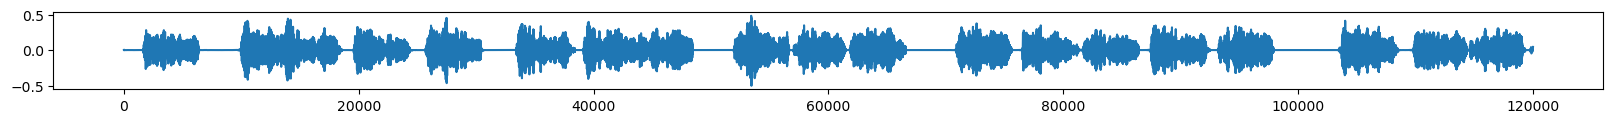

Finished epoch number 134 with a total of 10000 debug_seqs
 time: 2025-11-28 16:03:34.145694, epoch 135,  Loss: 0.2538
  Quantizer 0 Loss: 2.1874
  Quantizer 1 Loss: 3.1017
  Quantizer 2 Loss: 3.8631
  Quantizer 3 Loss: 4.3383
  Quantizer 4 Loss: 4.6517
  Quantizer 5 Loss: 4.8482
  Quantizer 6 Loss: 5.0755
  Quantizer 7 Loss: 5.1789
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


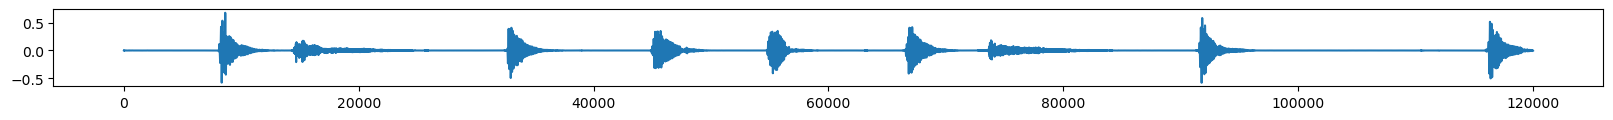

Finished epoch number 135 with a total of 10000 debug_seqs
 time: 2025-11-28 16:04:24.096215, epoch 136,  Loss: 0.2489
  Quantizer 0 Loss: 2.1796
  Quantizer 1 Loss: 3.0957
  Quantizer 2 Loss: 3.8528
  Quantizer 3 Loss: 4.3279
  Quantizer 4 Loss: 4.6377
  Quantizer 5 Loss: 4.8332
  Quantizer 6 Loss: 5.0607
  Quantizer 7 Loss: 5.1668
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


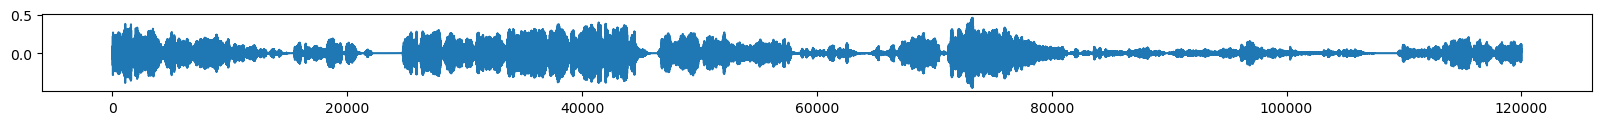

Finished epoch number 136 with a total of 10000 debug_seqs
 time: 2025-11-28 16:05:13.761020, epoch 137,  Loss: 0.2448
  Quantizer 0 Loss: 2.1740
  Quantizer 1 Loss: 3.0893
  Quantizer 2 Loss: 3.8427
  Quantizer 3 Loss: 4.3218
  Quantizer 4 Loss: 4.6367
  Quantizer 5 Loss: 4.8324
  Quantizer 6 Loss: 5.0639
  Quantizer 7 Loss: 5.1692
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


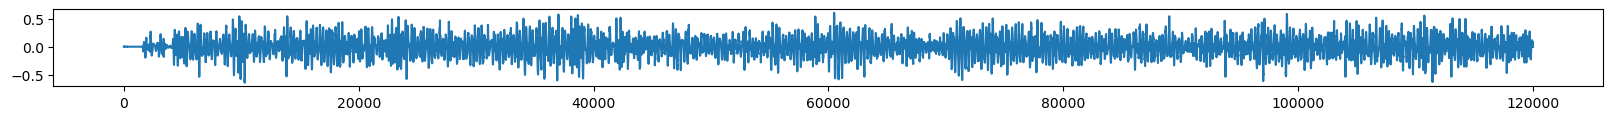

Finished epoch number 137 with a total of 10000 debug_seqs
 time: 2025-11-28 16:06:04.262872, epoch 138,  Loss: 0.2493
  Quantizer 0 Loss: 2.1754
  Quantizer 1 Loss: 3.0932
  Quantizer 2 Loss: 3.8485
  Quantizer 3 Loss: 4.3189
  Quantizer 4 Loss: 4.6292
  Quantizer 5 Loss: 4.8227
  Quantizer 6 Loss: 5.0628
  Quantizer 7 Loss: 5.1673
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


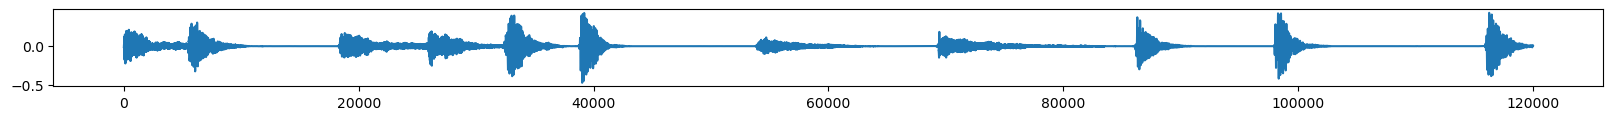

Finished epoch number 138 with a total of 10000 debug_seqs
 time: 2025-11-28 16:06:55.387245, epoch 139,  Loss: 0.2525
  Quantizer 0 Loss: 2.1726
  Quantizer 1 Loss: 3.0868
  Quantizer 2 Loss: 3.8362
  Quantizer 3 Loss: 4.3095
  Quantizer 4 Loss: 4.6181
  Quantizer 5 Loss: 4.8134
  Quantizer 6 Loss: 5.0481
  Quantizer 7 Loss: 5.1518
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


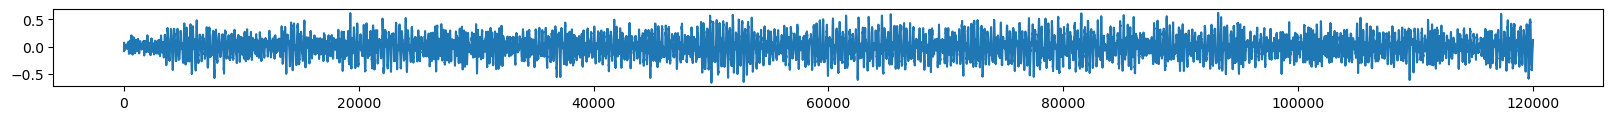

Finished epoch number 139 with a total of 10000 debug_seqs
 time: 2025-11-28 16:07:45.195148, epoch 140,  Loss: 0.2439
  Quantizer 0 Loss: 2.1647
  Quantizer 1 Loss: 3.0793
  Quantizer 2 Loss: 3.8312
  Quantizer 3 Loss: 4.3054
  Quantizer 4 Loss: 4.6114
  Quantizer 5 Loss: 4.8106
  Quantizer 6 Loss: 5.0394
  Quantizer 7 Loss: 5.1463
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


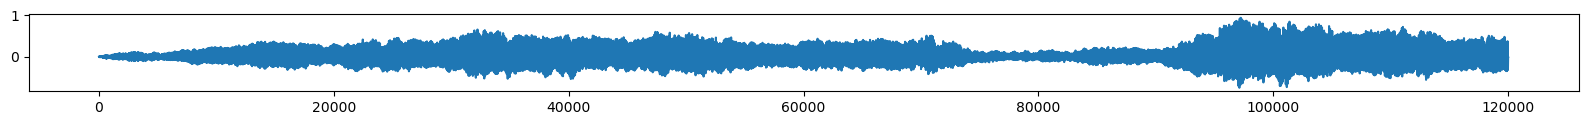

Finished epoch number 140 with a total of 10000 debug_seqs
 time: 2025-11-28 16:08:35.453038, epoch 141,  Loss: 0.2406
  Quantizer 0 Loss: 2.1553
  Quantizer 1 Loss: 3.0690
  Quantizer 2 Loss: 3.8278
  Quantizer 3 Loss: 4.3033
  Quantizer 4 Loss: 4.6157
  Quantizer 5 Loss: 4.8158
  Quantizer 6 Loss: 5.0483
  Quantizer 7 Loss: 5.1509
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


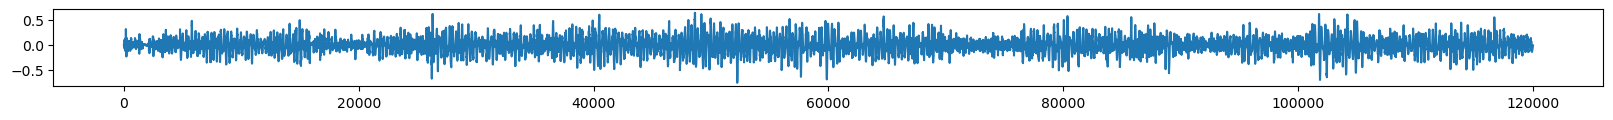

Finished epoch number 141 with a total of 10000 debug_seqs
 time: 2025-11-28 16:09:26.114586, epoch 142,  Loss: 0.2368
  Quantizer 0 Loss: 2.1625
  Quantizer 1 Loss: 3.0755
  Quantizer 2 Loss: 3.8327
  Quantizer 3 Loss: 4.3064
  Quantizer 4 Loss: 4.6194
  Quantizer 5 Loss: 4.8177
  Quantizer 6 Loss: 5.0458
  Quantizer 7 Loss: 5.1538
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


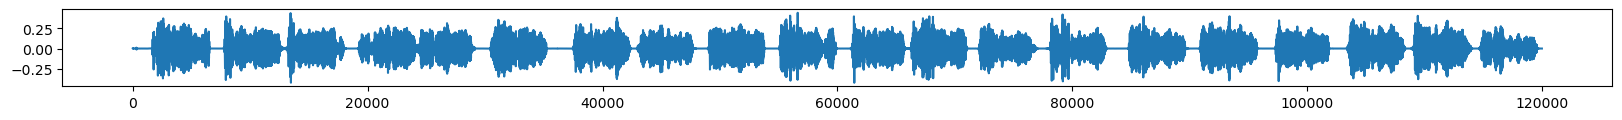

Finished epoch number 142 with a total of 10000 debug_seqs
 time: 2025-11-28 16:10:16.135872, epoch 143,  Loss: 0.2472
  Quantizer 0 Loss: 2.1647
  Quantizer 1 Loss: 3.0788
  Quantizer 2 Loss: 3.8401
  Quantizer 3 Loss: 4.3074
  Quantizer 4 Loss: 4.6226
  Quantizer 5 Loss: 4.8156
  Quantizer 6 Loss: 5.0510
  Quantizer 7 Loss: 5.1569
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


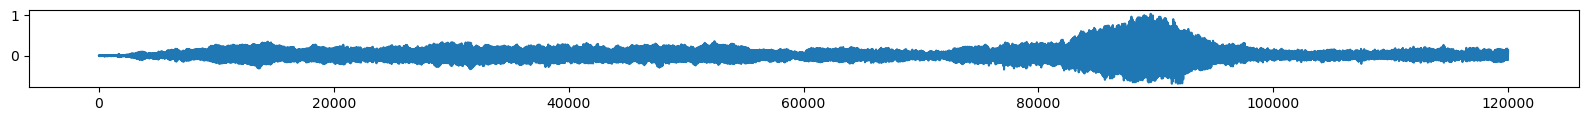

Finished epoch number 143 with a total of 10000 debug_seqs
 time: 2025-11-28 16:11:06.904847, epoch 144,  Loss: 0.2341
  Quantizer 0 Loss: 2.1812
  Quantizer 1 Loss: 3.0870
  Quantizer 2 Loss: 3.8379
  Quantizer 3 Loss: 4.3132
  Quantizer 4 Loss: 4.6189
  Quantizer 5 Loss: 4.8136
  Quantizer 6 Loss: 5.0436
  Quantizer 7 Loss: 5.1482
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


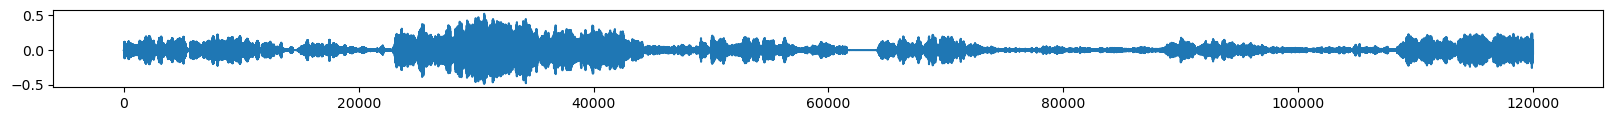

Finished epoch number 144 with a total of 10000 debug_seqs
 time: 2025-11-28 16:11:57.160532, epoch 145,  Loss: 0.2552
  Quantizer 0 Loss: 2.1788
  Quantizer 1 Loss: 3.0899
  Quantizer 2 Loss: 3.8458
  Quantizer 3 Loss: 4.3180
  Quantizer 4 Loss: 4.6309
  Quantizer 5 Loss: 4.8283
  Quantizer 6 Loss: 5.0574
  Quantizer 7 Loss: 5.1629
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


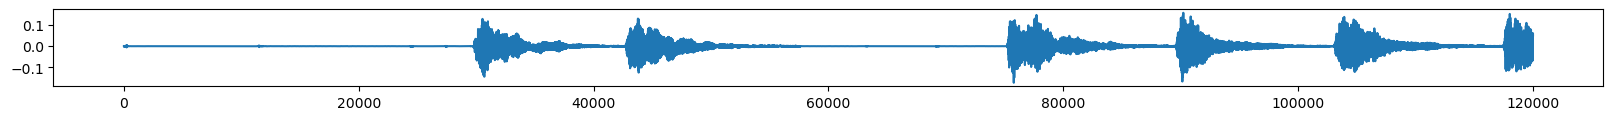

Finished epoch number 145 with a total of 10000 debug_seqs
 time: 2025-11-28 16:12:46.564950, epoch 146,  Loss: 0.2494
  Quantizer 0 Loss: 2.1727
  Quantizer 1 Loss: 3.0794
  Quantizer 2 Loss: 3.8400
  Quantizer 3 Loss: 4.3060
  Quantizer 4 Loss: 4.6177
  Quantizer 5 Loss: 4.8156
  Quantizer 6 Loss: 5.0427
  Quantizer 7 Loss: 5.1518
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


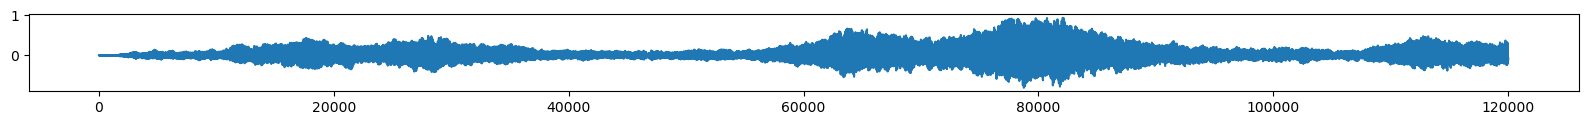

Finished epoch number 146 with a total of 10000 debug_seqs
 time: 2025-11-28 16:13:36.175501, epoch 147,  Loss: 0.2403
  Quantizer 0 Loss: 2.1737
  Quantizer 1 Loss: 3.0830
  Quantizer 2 Loss: 3.8308
  Quantizer 3 Loss: 4.3082
  Quantizer 4 Loss: 4.6111
  Quantizer 5 Loss: 4.8051
  Quantizer 6 Loss: 5.0433
  Quantizer 7 Loss: 5.1474
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


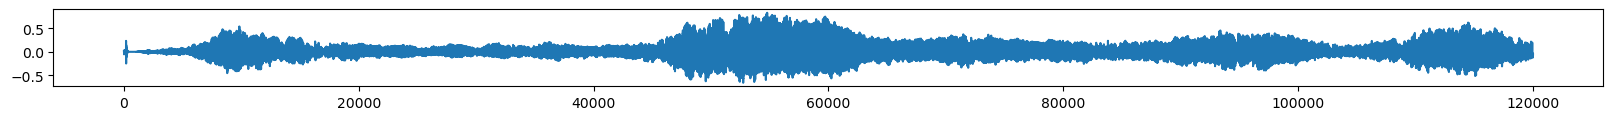

Finished epoch number 147 with a total of 10000 debug_seqs
 time: 2025-11-28 16:14:26.177407, epoch 148,  Loss: 0.2499
  Quantizer 0 Loss: 2.1696
  Quantizer 1 Loss: 3.0836
  Quantizer 2 Loss: 3.8331
  Quantizer 3 Loss: 4.3038
  Quantizer 4 Loss: 4.6168
  Quantizer 5 Loss: 4.8142
  Quantizer 6 Loss: 5.0486
  Quantizer 7 Loss: 5.1520
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


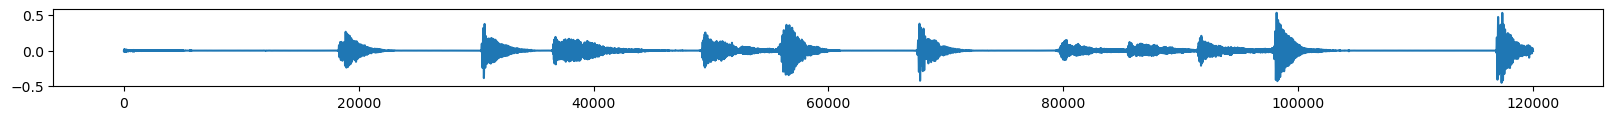

Finished epoch number 148 with a total of 10000 debug_seqs
 time: 2025-11-28 16:15:16.830656, epoch 149,  Loss: 0.2383
  Quantizer 0 Loss: 2.1786
  Quantizer 1 Loss: 3.0851
  Quantizer 2 Loss: 3.8407
  Quantizer 3 Loss: 4.3138
  Quantizer 4 Loss: 4.6264
  Quantizer 5 Loss: 4.8246
  Quantizer 6 Loss: 5.0536
  Quantizer 7 Loss: 5.1608
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


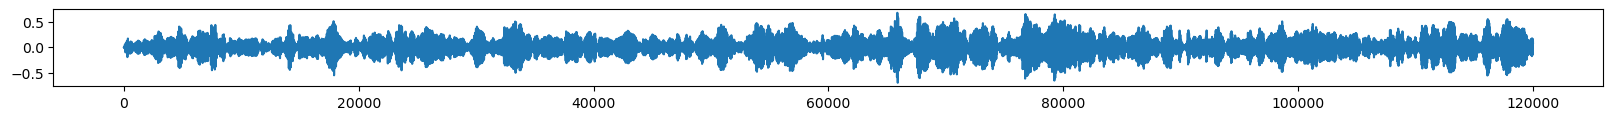

Finished epoch number 149 with a total of 10000 debug_seqs
 time: 2025-11-28 16:16:08.328280, epoch 150,  Loss: 0.2533
  Quantizer 0 Loss: 2.1827
  Quantizer 1 Loss: 3.0868
  Quantizer 2 Loss: 3.8482
  Quantizer 3 Loss: 4.3203
  Quantizer 4 Loss: 4.6289
  Quantizer 5 Loss: 4.8240
  Quantizer 6 Loss: 5.0522
  Quantizer 7 Loss: 5.1580
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


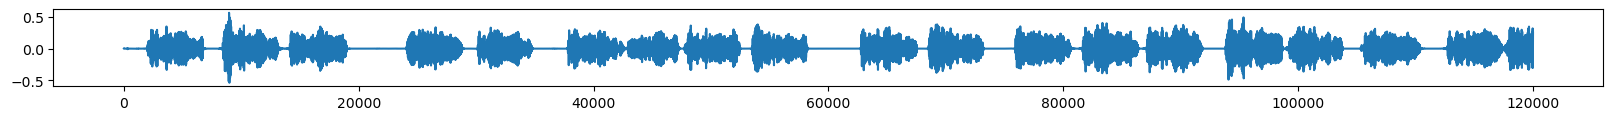

Saved checkpoint at epoch 150
Finished epoch number 150 with a total of 10000 debug_seqs
 time: 2025-11-28 16:16:58.125236, epoch 151,  Loss: 0.2210
  Quantizer 0 Loss: 2.1460
  Quantizer 1 Loss: 2.7004
  Quantizer 2 Loss: 3.3875
  Quantizer 3 Loss: 3.8599
  Quantizer 4 Loss: 4.1857
  Quantizer 5 Loss: 4.3957
  Quantizer 6 Loss: 4.6446
  Quantizer 7 Loss: 4.7782
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


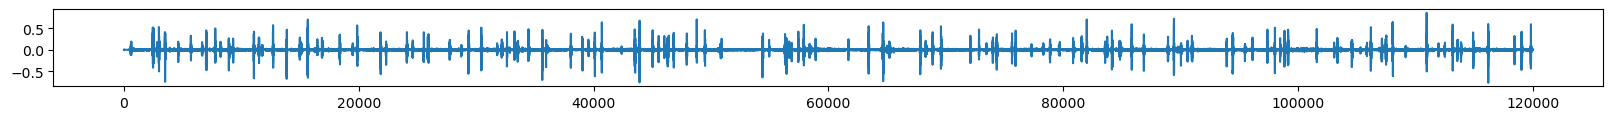

Finished epoch number 151 with a total of 10000 debug_seqs
 time: 2025-11-28 16:17:46.993373, epoch 152,  Loss: 0.2157
  Quantizer 0 Loss: 2.1574
  Quantizer 1 Loss: 2.6705
  Quantizer 2 Loss: 3.3410
  Quantizer 3 Loss: 3.8065
  Quantizer 4 Loss: 4.1248
  Quantizer 5 Loss: 4.3357
  Quantizer 6 Loss: 4.5847
  Quantizer 7 Loss: 4.7154
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


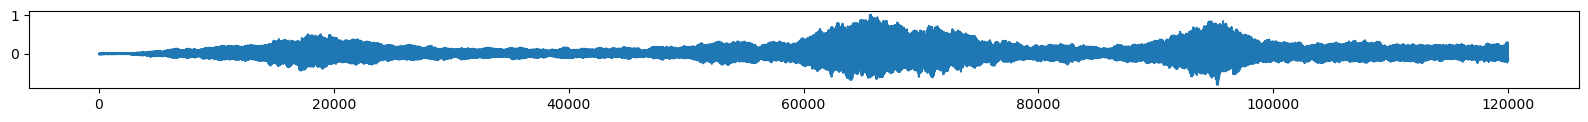

Finished epoch number 152 with a total of 10000 debug_seqs
 time: 2025-11-28 16:18:37.033657, epoch 153,  Loss: 0.2177
  Quantizer 0 Loss: 2.1548
  Quantizer 1 Loss: 2.6636
  Quantizer 2 Loss: 3.3320
  Quantizer 3 Loss: 3.7919
  Quantizer 4 Loss: 4.1143
  Quantizer 5 Loss: 4.3182
  Quantizer 6 Loss: 4.5687
  Quantizer 7 Loss: 4.7017
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


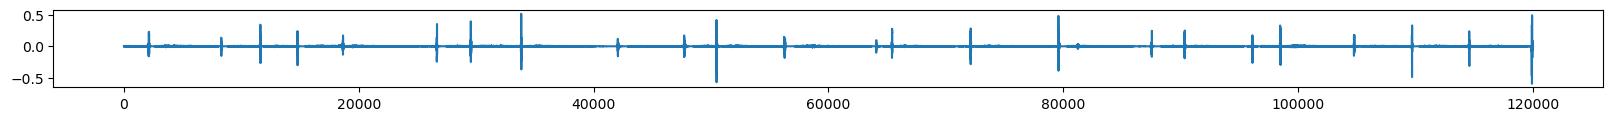

Finished epoch number 153 with a total of 10000 debug_seqs
 time: 2025-11-28 16:19:25.532208, epoch 154,  Loss: 0.2267
  Quantizer 0 Loss: 2.1495
  Quantizer 1 Loss: 2.6500
  Quantizer 2 Loss: 3.3157
  Quantizer 3 Loss: 3.7683
  Quantizer 4 Loss: 4.0877
  Quantizer 5 Loss: 4.2994
  Quantizer 6 Loss: 4.5417
  Quantizer 7 Loss: 4.6758
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


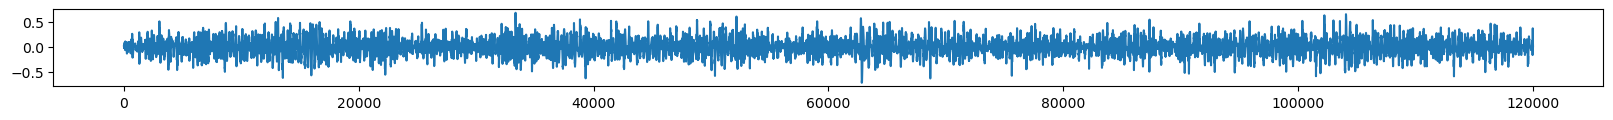

Finished epoch number 154 with a total of 10000 debug_seqs
 time: 2025-11-28 16:20:15.503557, epoch 155,  Loss: 0.2171
  Quantizer 0 Loss: 2.1480
  Quantizer 1 Loss: 2.6439
  Quantizer 2 Loss: 3.3098
  Quantizer 3 Loss: 3.7605
  Quantizer 4 Loss: 4.0880
  Quantizer 5 Loss: 4.2992
  Quantizer 6 Loss: 4.5447
  Quantizer 7 Loss: 4.6738
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


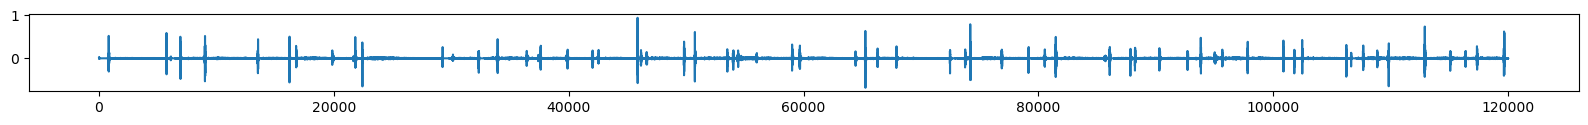

Finished epoch number 155 with a total of 10000 debug_seqs
 time: 2025-11-28 16:21:04.087815, epoch 156,  Loss: 0.2185
  Quantizer 0 Loss: 2.1646
  Quantizer 1 Loss: 2.6642
  Quantizer 2 Loss: 3.3247
  Quantizer 3 Loss: 3.7826
  Quantizer 4 Loss: 4.1012
  Quantizer 5 Loss: 4.3096
  Quantizer 6 Loss: 4.5620
  Quantizer 7 Loss: 4.6951
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


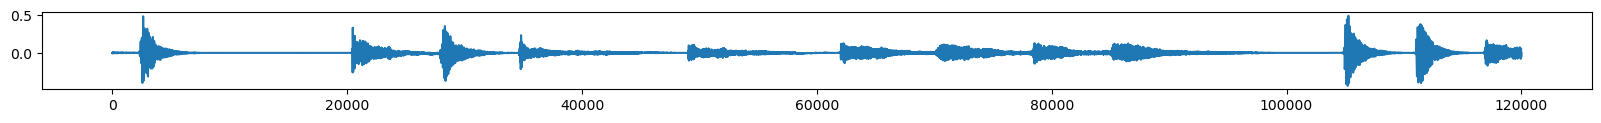

Finished epoch number 156 with a total of 10000 debug_seqs
 time: 2025-11-28 16:21:54.063891, epoch 157,  Loss: 0.2165
  Quantizer 0 Loss: 2.1570
  Quantizer 1 Loss: 2.6556
  Quantizer 2 Loss: 3.3083
  Quantizer 3 Loss: 3.7640
  Quantizer 4 Loss: 4.0836
  Quantizer 5 Loss: 4.2895
  Quantizer 6 Loss: 4.5344
  Quantizer 7 Loss: 4.6664
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


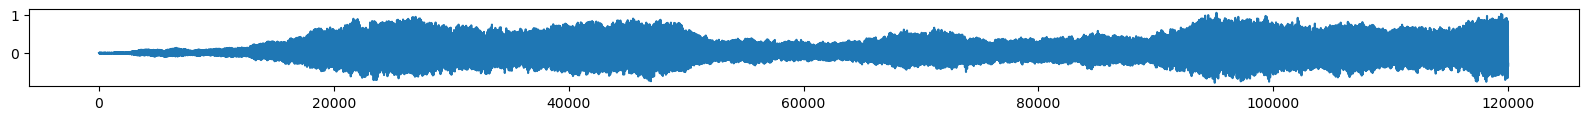

Finished epoch number 157 with a total of 10000 debug_seqs
 time: 2025-11-28 16:22:45.034289, epoch 158,  Loss: 0.2053
  Quantizer 0 Loss: 2.1423
  Quantizer 1 Loss: 2.6447
  Quantizer 2 Loss: 3.3019
  Quantizer 3 Loss: 3.7617
  Quantizer 4 Loss: 4.0747
  Quantizer 5 Loss: 4.2823
  Quantizer 6 Loss: 4.5296
  Quantizer 7 Loss: 4.6668
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


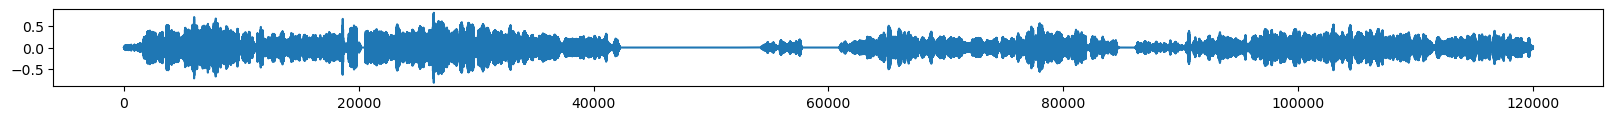

Finished epoch number 158 with a total of 10000 debug_seqs
 time: 2025-11-28 16:23:34.567143, epoch 159,  Loss: 0.2168
  Quantizer 0 Loss: 2.1605
  Quantizer 1 Loss: 2.6693
  Quantizer 2 Loss: 3.3107
  Quantizer 3 Loss: 3.7749
  Quantizer 4 Loss: 4.0896
  Quantizer 5 Loss: 4.2991
  Quantizer 6 Loss: 4.5520
  Quantizer 7 Loss: 4.6868
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


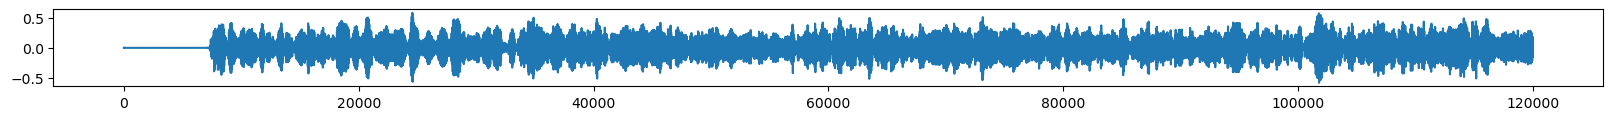

Finished epoch number 159 with a total of 10000 debug_seqs
 time: 2025-11-28 16:24:23.113033, epoch 160,  Loss: 0.2163
  Quantizer 0 Loss: 2.1448
  Quantizer 1 Loss: 2.6472
  Quantizer 2 Loss: 3.3029
  Quantizer 3 Loss: 3.7589
  Quantizer 4 Loss: 4.0760
  Quantizer 5 Loss: 4.2778
  Quantizer 6 Loss: 4.5306
  Quantizer 7 Loss: 4.6638
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


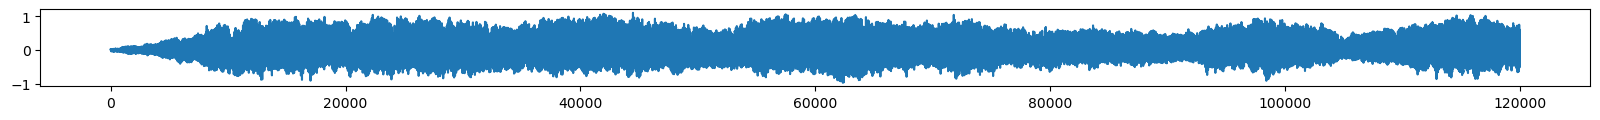

Finished epoch number 160 with a total of 10000 debug_seqs
 time: 2025-11-28 16:25:11.819825, epoch 161,  Loss: 0.2087
  Quantizer 0 Loss: 2.1496
  Quantizer 1 Loss: 2.6545
  Quantizer 2 Loss: 3.3123
  Quantizer 3 Loss: 3.7597
  Quantizer 4 Loss: 4.0778
  Quantizer 5 Loss: 4.2924
  Quantizer 6 Loss: 4.5371
  Quantizer 7 Loss: 4.6693
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


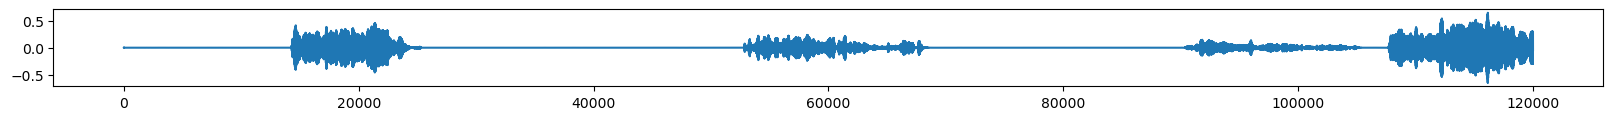

Finished epoch number 161 with a total of 10000 debug_seqs
 time: 2025-11-28 16:26:00.332383, epoch 162,  Loss: 0.2125
  Quantizer 0 Loss: 2.1435
  Quantizer 1 Loss: 2.6449
  Quantizer 2 Loss: 3.2955
  Quantizer 3 Loss: 3.7468
  Quantizer 4 Loss: 4.0655
  Quantizer 5 Loss: 4.2753
  Quantizer 6 Loss: 4.5151
  Quantizer 7 Loss: 4.6557
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


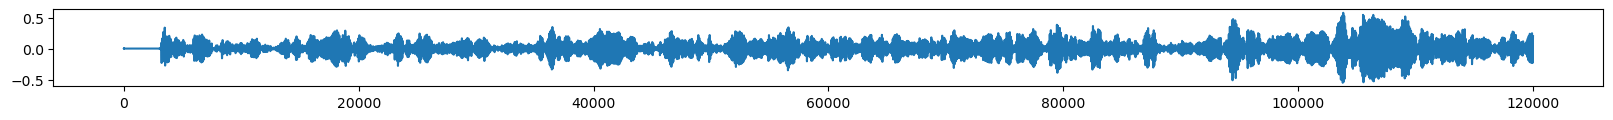

Finished epoch number 162 with a total of 10000 debug_seqs
 time: 2025-11-28 16:26:48.671818, epoch 163,  Loss: 0.2871
  Quantizer 0 Loss: 2.2751
  Quantizer 1 Loss: 2.7837
  Quantizer 2 Loss: 3.4349
  Quantizer 3 Loss: 3.8820
  Quantizer 4 Loss: 4.1819
  Quantizer 5 Loss: 4.3876
  Quantizer 6 Loss: 4.6150
  Quantizer 7 Loss: 4.7436
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


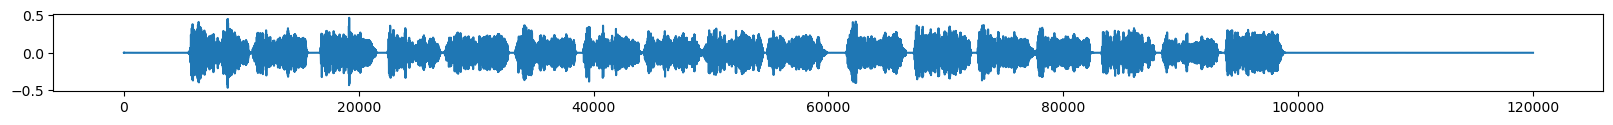

Finished epoch number 163 with a total of 10000 debug_seqs
 time: 2025-11-28 16:27:37.792438, epoch 164,  Loss: 0.2191
  Quantizer 0 Loss: 2.3943
  Quantizer 1 Loss: 2.9369
  Quantizer 2 Loss: 3.5757
  Quantizer 3 Loss: 4.0150
  Quantizer 4 Loss: 4.3063
  Quantizer 5 Loss: 4.4946
  Quantizer 6 Loss: 4.7175
  Quantizer 7 Loss: 4.8352
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


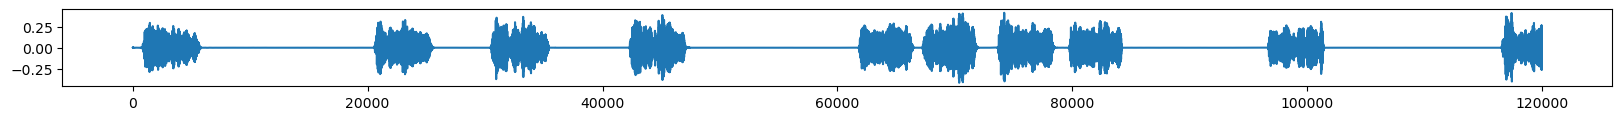

Finished epoch number 164 with a total of 10000 debug_seqs
 time: 2025-11-28 16:28:26.662543, epoch 165,  Loss: 0.2217
  Quantizer 0 Loss: 2.2121
  Quantizer 1 Loss: 2.6955
  Quantizer 2 Loss: 3.3433
  Quantizer 3 Loss: 3.7940
  Quantizer 4 Loss: 4.1012
  Quantizer 5 Loss: 4.3039
  Quantizer 6 Loss: 4.5460
  Quantizer 7 Loss: 4.6741
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


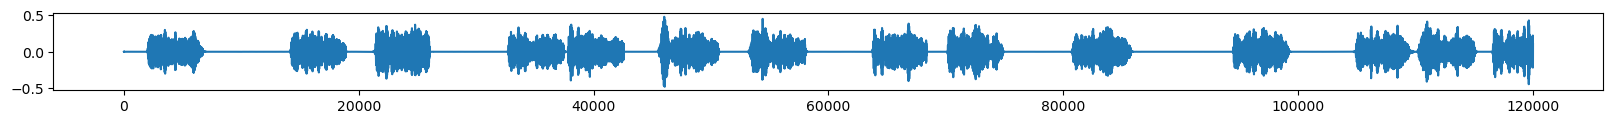

Finished epoch number 165 with a total of 10000 debug_seqs
 time: 2025-11-28 16:29:16.423935, epoch 166,  Loss: 0.2177
  Quantizer 0 Loss: 2.1821
  Quantizer 1 Loss: 2.6762
  Quantizer 2 Loss: 3.3225
  Quantizer 3 Loss: 3.7728
  Quantizer 4 Loss: 4.0906
  Quantizer 5 Loss: 4.2940
  Quantizer 6 Loss: 4.5397
  Quantizer 7 Loss: 4.6726
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


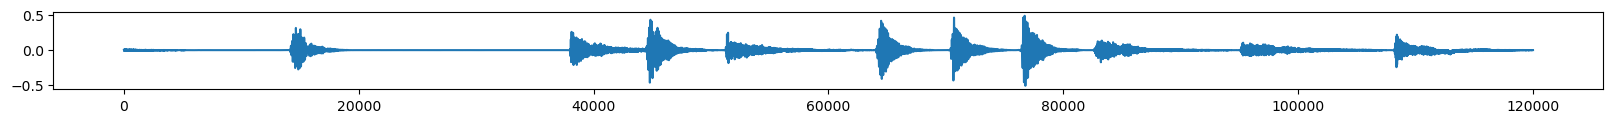

Finished epoch number 166 with a total of 10000 debug_seqs
 time: 2025-11-28 16:30:05.241495, epoch 167,  Loss: 0.2133
  Quantizer 0 Loss: 2.1716
  Quantizer 1 Loss: 2.6627
  Quantizer 2 Loss: 3.3109
  Quantizer 3 Loss: 3.7600
  Quantizer 4 Loss: 4.0718
  Quantizer 5 Loss: 4.2779
  Quantizer 6 Loss: 4.5206
  Quantizer 7 Loss: 4.6555
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


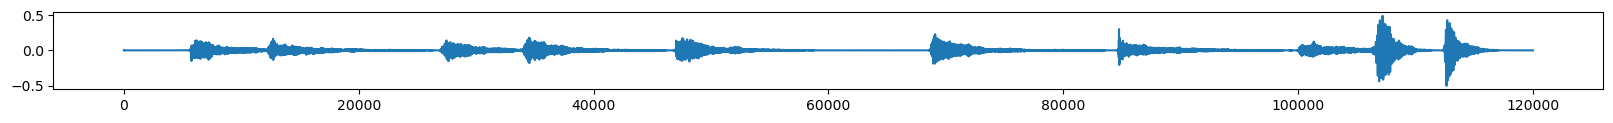

Finished epoch number 167 with a total of 10000 debug_seqs
 time: 2025-11-28 16:30:53.745285, epoch 168,  Loss: 0.2193
  Quantizer 0 Loss: 2.1673
  Quantizer 1 Loss: 2.6567
  Quantizer 2 Loss: 3.3060
  Quantizer 3 Loss: 3.7570
  Quantizer 4 Loss: 4.0711
  Quantizer 5 Loss: 4.2714
  Quantizer 6 Loss: 4.5242
  Quantizer 7 Loss: 4.6527
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


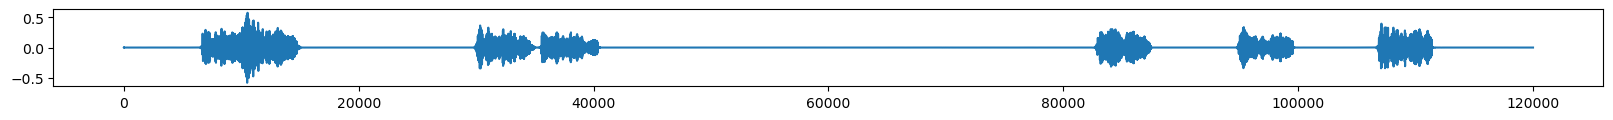

Finished epoch number 168 with a total of 10000 debug_seqs
 time: 2025-11-28 16:31:42.849711, epoch 169,  Loss: 0.2181
  Quantizer 0 Loss: 2.1671
  Quantizer 1 Loss: 2.6576
  Quantizer 2 Loss: 3.3056
  Quantizer 3 Loss: 3.7596
  Quantizer 4 Loss: 4.0743
  Quantizer 5 Loss: 4.2791
  Quantizer 6 Loss: 4.5283
  Quantizer 7 Loss: 4.6630
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


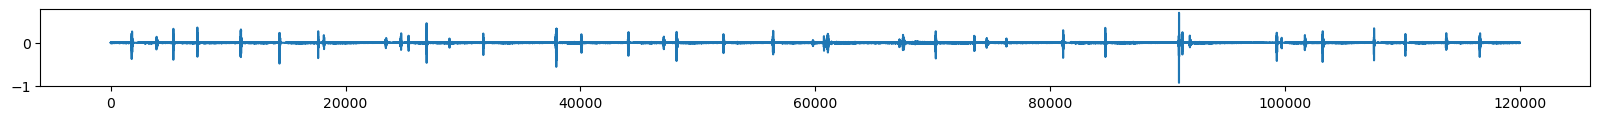

Finished epoch number 169 with a total of 10000 debug_seqs
 time: 2025-11-28 16:32:33.109608, epoch 170,  Loss: 0.2146
  Quantizer 0 Loss: 2.1515
  Quantizer 1 Loss: 2.6444
  Quantizer 2 Loss: 3.3015
  Quantizer 3 Loss: 3.7470
  Quantizer 4 Loss: 4.0666
  Quantizer 5 Loss: 4.2766
  Quantizer 6 Loss: 4.5200
  Quantizer 7 Loss: 4.6510
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


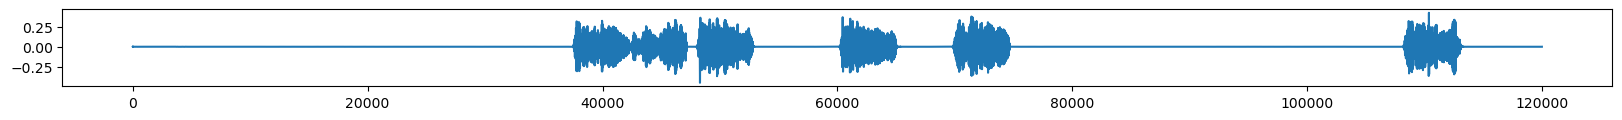

Finished epoch number 170 with a total of 10000 debug_seqs
 time: 2025-11-28 16:33:21.755116, epoch 171,  Loss: 0.2092
  Quantizer 0 Loss: 2.1576
  Quantizer 1 Loss: 2.6484
  Quantizer 2 Loss: 3.3007
  Quantizer 3 Loss: 3.7525
  Quantizer 4 Loss: 4.0715
  Quantizer 5 Loss: 4.2723
  Quantizer 6 Loss: 4.5194
  Quantizer 7 Loss: 4.6576
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


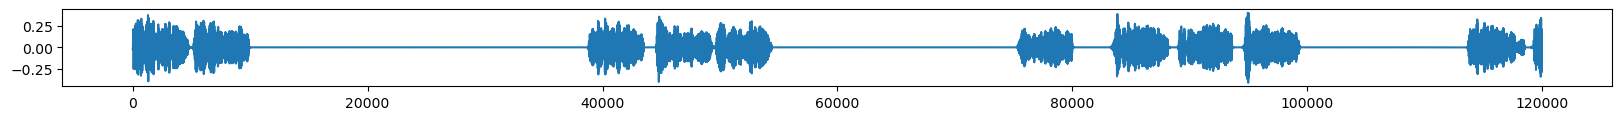

Finished epoch number 171 with a total of 10000 debug_seqs
 time: 2025-11-28 16:34:10.555299, epoch 172,  Loss: 0.2231
  Quantizer 0 Loss: 2.1378
  Quantizer 1 Loss: 2.6362
  Quantizer 2 Loss: 3.2889
  Quantizer 3 Loss: 3.7395
  Quantizer 4 Loss: 4.0581
  Quantizer 5 Loss: 4.2650
  Quantizer 6 Loss: 4.5166
  Quantizer 7 Loss: 4.6460
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


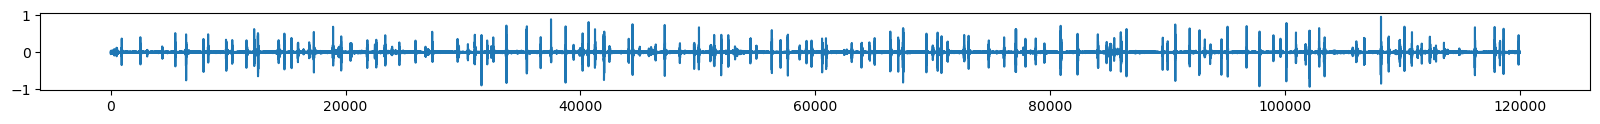

Finished epoch number 172 with a total of 10000 debug_seqs
 time: 2025-11-28 16:34:59.203961, epoch 173,  Loss: 0.2135
  Quantizer 0 Loss: 2.1562
  Quantizer 1 Loss: 2.6471
  Quantizer 2 Loss: 3.2968
  Quantizer 3 Loss: 3.7481
  Quantizer 4 Loss: 4.0701
  Quantizer 5 Loss: 4.2752
  Quantizer 6 Loss: 4.5189
  Quantizer 7 Loss: 4.6528
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


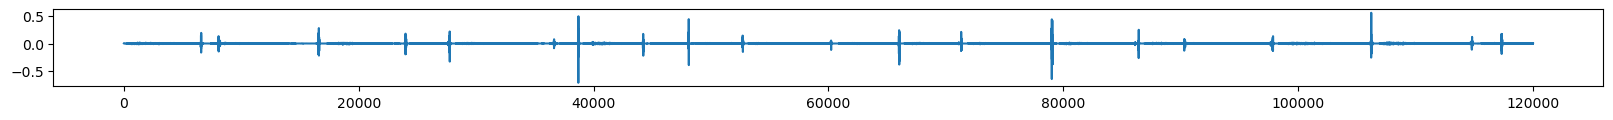

Finished epoch number 173 with a total of 10000 debug_seqs
 time: 2025-11-28 16:35:47.206385, epoch 174,  Loss: 0.2131
  Quantizer 0 Loss: 2.1673
  Quantizer 1 Loss: 2.6579
  Quantizer 2 Loss: 3.3077
  Quantizer 3 Loss: 3.7657
  Quantizer 4 Loss: 4.0785
  Quantizer 5 Loss: 4.2889
  Quantizer 6 Loss: 4.5340
  Quantizer 7 Loss: 4.6647
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


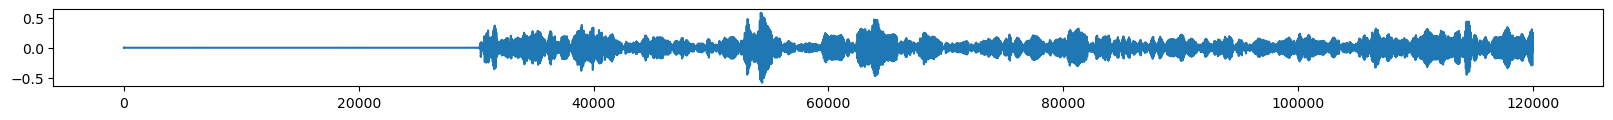

Finished epoch number 174 with a total of 10000 debug_seqs
 time: 2025-11-28 16:36:35.274311, epoch 175,  Loss: 0.2199
  Quantizer 0 Loss: 2.1632
  Quantizer 1 Loss: 2.6528
  Quantizer 2 Loss: 3.3077
  Quantizer 3 Loss: 3.7573
  Quantizer 4 Loss: 4.0738
  Quantizer 5 Loss: 4.2815
  Quantizer 6 Loss: 4.5226
  Quantizer 7 Loss: 4.6578
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


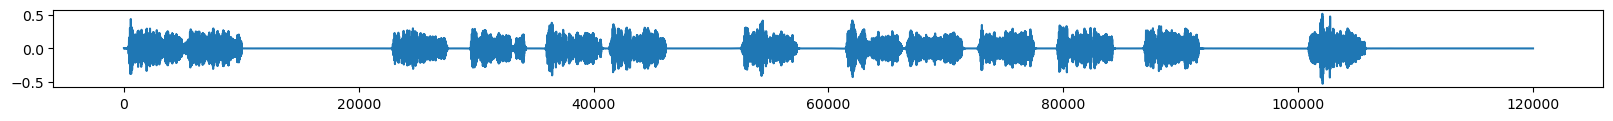

Saved checkpoint at epoch 175
Finished epoch number 175 with a total of 10000 debug_seqs
 time: 2025-11-28 16:37:23.701026, epoch 176,  Loss: 0.2461
  Quantizer 0 Loss: 2.2342
  Quantizer 1 Loss: 3.2993
  Quantizer 2 Loss: 3.9834
  Quantizer 3 Loss: 4.4228
  Quantizer 4 Loss: 4.7108
  Quantizer 5 Loss: 4.8937
  Quantizer 6 Loss: 5.1284
  Quantizer 7 Loss: 5.2254
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


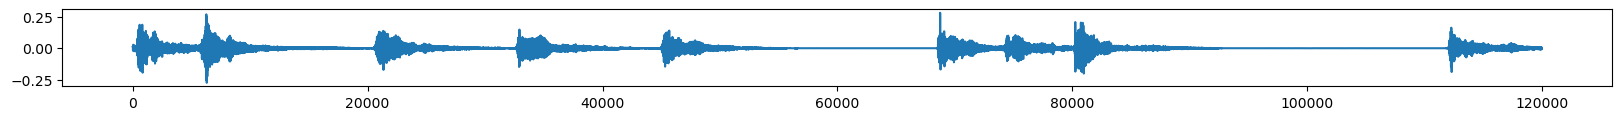

Finished epoch number 176 with a total of 10000 debug_seqs
 time: 2025-11-28 16:38:13.657256, epoch 177,  Loss: 0.2506
  Quantizer 0 Loss: 2.1897
  Quantizer 1 Loss: 3.1541
  Quantizer 2 Loss: 3.8933
  Quantizer 3 Loss: 4.3464
  Quantizer 4 Loss: 4.6462
  Quantizer 5 Loss: 4.8348
  Quantizer 6 Loss: 5.0650
  Quantizer 7 Loss: 5.1665
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


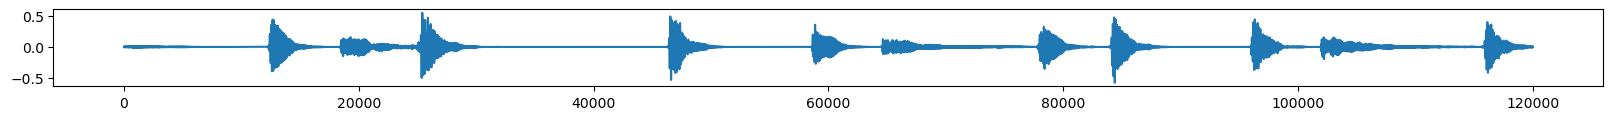

Finished epoch number 177 with a total of 10000 debug_seqs
 time: 2025-11-28 16:39:03.734387, epoch 178,  Loss: 0.2405
  Quantizer 0 Loss: 2.1729
  Quantizer 1 Loss: 3.1178
  Quantizer 2 Loss: 3.8648
  Quantizer 3 Loss: 4.3287
  Quantizer 4 Loss: 4.6360
  Quantizer 5 Loss: 4.8267
  Quantizer 6 Loss: 5.0562
  Quantizer 7 Loss: 5.1598
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


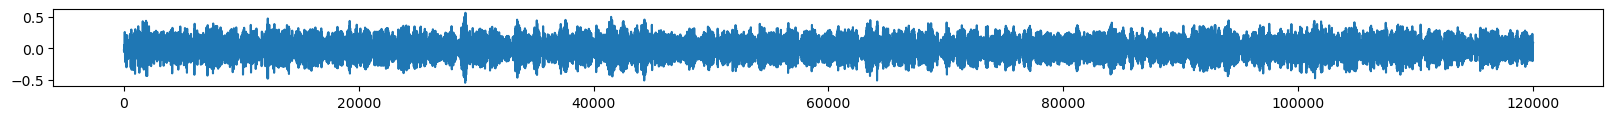

Finished epoch number 178 with a total of 10000 debug_seqs
 time: 2025-11-28 16:39:52.998259, epoch 179,  Loss: 0.2421
  Quantizer 0 Loss: 2.1752
  Quantizer 1 Loss: 3.1106
  Quantizer 2 Loss: 3.8624
  Quantizer 3 Loss: 4.3282
  Quantizer 4 Loss: 4.6348
  Quantizer 5 Loss: 4.8298
  Quantizer 6 Loss: 5.0560
  Quantizer 7 Loss: 5.1617
Latents embedded in 80 of the GRU input size of 128
Conditioning parameters embedded in 48 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([8])
params_seq.shape = torch.Size([10, 8])
plot the audio which has shape (120000,)


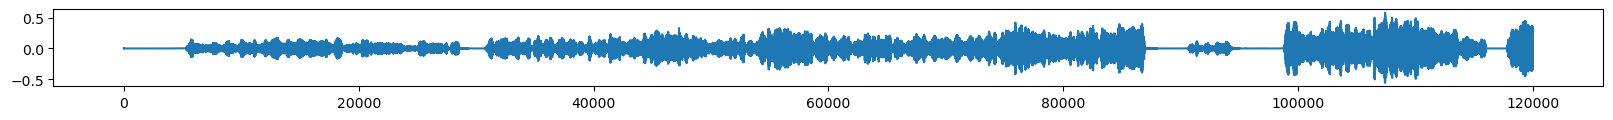

In [ ]:
# Train!
#*************************************
enc_model.to(device)
list_of_losses = []

print('{:%Y-%m-%d %H:%M:%S} Starting training...'.format(datetime.now()))
start_time = time.monotonic()
#-------------------------------------------------------------------------------
for epoch in range(start_epoch, start_epoch+params['num_epochs']):
    train(rnn,enc_model,epoch)
#-------------------------------------------------------------------------------
writer.close()
elapsed_time = time.monotonic() - start_time
print('Training time taken:',time_taken(elapsed_time))

#Just make sure the final model gets saved
checkpoint_data = {
    'epoch': epoch+1,
    'model_state_dict': rnn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}
# Save numbered checkpoint
numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
torch.save(checkpoint_data, numbered_path)
print(f"Saved checkpoint at epoch {epoch+1}")
# Copy to "last" (much faster than saving twice)
last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
shutil.copy2(numbered_path, last_path)


In [12]:
# Plot the loss over time
#*************************************
plt.figure()
plt.plot(list_of_losses)
plt.show()  # This will actually display the plot

NameError: name 'list_of_losses' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:
list_of_losses